In [1]:
import numpy as np
import astropy.units as u
import astropy.wcs.utils as utils
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
from scipy.ndimage import shift
import warnings
from astropy.wcs import FITSFixedWarning
warnings.simplefilter('ignore', FITSFixedWarning)

# **Start Values**

In [2]:
path_image_1 = "/home/wesley/Desktop/JWST_REU/2025_stage_2_data/"
path_image_2 = "/home/wesley/Desktop/JWST_REU/2026_stage_2_data/"

# **Distortion**

In [3]:
def distortion_correction(x_coord, y_coord, header):
    u =  np.array(x_coord) - header['CRPIX1']
    v =  np.array(y_coord) - header['CRPIX2']

    yf02 = (header['B_0_2'] * (u ** 0) * (v ** 2))
    yf03 = (header['B_0_3'] * (u ** 0) * (v ** 3))
    yf04 = (header['B_0_4'] * (u ** 0) * (v ** 4))
    yf05 = (header['B_0_5'] * (u ** 0) * (v ** 5))
    yf11 = (header['B_1_1'] * (u ** 1) * (v ** 1))
    yf12 = (header['B_1_2'] * (u ** 1) * (v ** 2))
    yf13 = (header['B_1_3'] * (u ** 1) * (v ** 3))
    yf14 = (header['B_1_4'] * (u ** 1) * (v ** 4))
    yf20 = (header['B_2_0'] * (u ** 2) * (v ** 0))
    yf21 = (header['B_2_1'] * (u ** 2) * (v ** 1))
    yf22 = (header['B_2_2'] * (u ** 2) * (v ** 2))
    yf23 = (header['B_2_3'] * (u ** 2) * (v ** 3))
    yf30 = (header['B_3_0'] * (u ** 3) * (v ** 0))
    yf31 = (header['B_3_1'] * (u ** 3) * (v ** 1))
    yf32 = (header['B_3_2'] * (u ** 3) * (v ** 2))
    yf40 = (header['B_4_0'] * (u ** 4) * (v ** 0))
    yf41 = (header['B_4_1'] * (u ** 4) * (v ** 1))
    yf50 = (header['B_5_0'] * (u ** 5) * (v ** 0))

    xf02 = (header['A_0_2'] * (u ** 0) * (v ** 2))
    xf03 = (header['A_0_3'] * (u ** 0) * (v ** 3))
    xf04 = (header['A_0_4'] * (u ** 0) * (v ** 4))
    xf05 = (header['A_0_5'] * (u ** 0) * (v ** 5))
    xf11 = (header['A_1_1'] * (u ** 1) * (v ** 1))
    xf12 = (header['A_1_2'] * (u ** 1) * (v ** 2))
    xf13 = (header['A_1_3'] * (u ** 1) * (v ** 3))
    xf14 = (header['A_1_4'] * (u ** 1) * (v ** 4))  
    xf20 = (header['A_2_0'] * (u ** 2) * (v ** 0))
    xf21 = (header['A_2_1'] * (u ** 2) * (v ** 1))
    xf22 = (header['A_2_2'] * (u ** 2) * (v ** 2))
    xf23 = (header['A_2_3'] * (u ** 2) * (v ** 3))
    xf30 = (header['A_3_0'] * (u ** 3) * (v ** 0))
    xf31 = (header['A_3_1'] * (u ** 3) * (v ** 1))
    xf32 = (header['A_3_2'] * (u ** 3) * (v ** 2))
    xf40 = (header['A_4_0'] * (u ** 4) * (v ** 0))
    xf41 = (header['A_4_1'] * (u ** 4) * (v ** 1))
    xf50 = (header['A_5_0'] * (u ** 5) * (v ** 0))

    function_f = xf02 + xf03 + xf04 + xf05 + xf11 + xf12 + xf13 + xf14 + xf20 + xf21 + xf22 + xf23 + xf30 + xf31 + xf32 + xf40 + xf41 + xf50
    function_g = yf02 + yf03 + yf04 + yf05 + yf11 + yf12 + yf13 + yf14 + yf20 + yf21 + yf22 + yf23 + yf30 + yf31 + yf32 + yf40 + yf41 + yf50

    corrected_x = function_f + x_coord
    corrected_y = function_g + y_coord
    return(corrected_x, corrected_y)


# **"Chi Method"**

In [4]:
i = 0

In [5]:
def chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, image_1, image_2, header_1, header_2):
    
    im_1 = image_1
    im_2 = image_2
        
    #allows for the h varable to be acessed from within the definition
    global h, i
    #allows all plots to be made without warning
    plt.rcParams['figure.max_open_warning'] = 200
    #temporary arrays used for the process 
    pvalues = []
    chi_velocity = []
    chi_squ = []
    #sets the tital colors i use
    origin_color = 'green'
    lowest_color = 'red'
    two_color = 'blue'    
    # Define slice boundaries
    #i subtract 3 from the left and add four to the right
    #this ensures that when i shift the real data is conserved 
    #then after the shifting the added size is subtracted off
    #right side is larger due to the middle being defined as the 0,0 point with the size_chi being added to both sides
    ymin1 = cy_chi[i] - size_chi[i] - 3
    ymax1 = cy_chi[i] + size_chi[i] + 4
    xmin1 = cx_chi[i] - size_chi[i] - 3
    xmax1 = cx_chi[i] + size_chi[i] + 4
    #array_1 pulls image_1 from the defined size and center position
    #the median of that image in an area "median_factor" time bigger is then subtracted from the array
    array_1 = im_1[ymin1:ymax1, xmin1:xmax1] - np.median(
        im_1[
            cy_chi[i] - (median_factor * size_chi[i]) - 3 : cy_chi[i] + (median_factor * size_chi[i]) + 4,
            cx_chi[i] - (median_factor * size_chi[i]) - 3 : cx_chi[i] + (median_factor * size_chi[i]) + 4
        ]
    )
    #a zoomed in version of array_1 used for image displaying purposes
    zoom_sub1 = array_1[3:4 + (2 * size_chi[i]), 3:4 + (2 * size_chi[i])]

    #This does the same process for the second image
    # Define slice boundaries
    ymin2 = cy_chi[i+1] - size_chi[i+1] - 3
    ymax2 = cy_chi[i+1] + size_chi[i+1] + 4
    xmin2 = cx_chi[i+1] - size_chi[i+1] - 3
    xmax2 = cx_chi[i+1] + size_chi[i+1] + 4
    #array_2 pulls image_2
    array_2 = im_2[ymin2:ymax2, xmin2:xmax2] - np.median(
        im_2[
            cy_chi[i+1] - (median_factor * size_chi[i+1]) - 3 : cy_chi[i+1] + (median_factor * size_chi[i+1]) + 4,
            cx_chi[i+1] - (median_factor * size_chi[i+1]) - 3 : cx_chi[i+1] + (median_factor * size_chi[i+1]) + 4
        ]
    )
    #a zoomed in version of array_2
    zoom_sub2 = array_2[3:4 + (2 * size_chi[i]), 3:4 + (2 * size_chi[i])]

    
    #systematically runs through all values defined by the height and width and asigns them a diffrent shift amount that is incrmented by the "shift amount"
    #the hight and width says how many time the shift amount will be the max shift
    #it then appends all of the shift amounts to pvalues which is the shifts that are made
    for p in range(-width, width + 1, +1):
        for j in range(height, -height - 1, -1):
            pvalues.append([j*shift_amount, p*shift_amount])
    #this creates a deviation for the slice of the image
    ndev2 = (deviation / np.sum(array_2[3:4+(2*size_chi[i]), 3:4+(2*size_chi[i])]))**2  + .01/np.sum(array_2[3:4+(2*size_chi[i]), 3:4+(2*size_chi[i])])
    #creates a normalized array for the second image
    sub2 = (array_2[3:4+(2*size_chi[i]), 3:4+(2*size_chi[i])])/np.sum(array_2[3:4+(2*size_chi[i]), 3:4+(2*size_chi[i])])
    #runs through all shift amounts and shift the first image by every amount and then subtracts that from the second image
    for k, pv in enumerate(pvalues):
        #this shifts array_1 by the amount pv
        shift_array = (shift(array_1, pv, mode='nearest'))
        #this then cuts out the extra data
        zoom_shift = shift_array[3:4+(2*size_chi[i]), 3:4+(2*size_chi[i])]
        #normalizes the zoomed in array
        zoom_array_nrom = zoom_shift/np.sum(zoom_shift)
        #subtracts the normalized second image from the shifted normalized first image
        subtracted_array = sub2 - zoom_array_nrom
        #creates a "chi squared" value for every shift amount that is used to quantitatively analize each shift 
        squared = np.sum(np.square(subtracted_array)/ndev2) /   (((size_chi[i]*2+1)**2) - 2)
        chi_squ.append(squared)
    #defines the amount where in the array the chi squared value is the lowest
    min_value = np.argwhere(chi_squ == np.min(chi_squ))
    #defines the shift amount that gives the lowest chi value
    index = min_value[0, 0]    

    new_cx_1, new_cy_1 = distortion_correction(cx_chi[0], cy_chi[0], header_1)
    new_cx_2, new_cy_2 = distortion_correction(cx_chi[1], cy_chi[1], header_2)

    distortion_diffrence_x = (new_cx_1 - cx_chi[0]) - (new_cx_2 - cx_chi[1]) 
    distortion_diffrence_y = (new_cy_1 - cy_chi[0]) - (new_cy_2 - cy_chi[1])
    distortion_correction_x = distortion_diffrence_x 
    distortion_correction_y = distortion_diffrence_y 


    x_axis_correction = cx_chi[1] - cx_chi[0] + x_offset - distortion_correction_x
    y_axis_correction = cy_chi[1] - cy_chi[0] + y_offset - distortion_correction_y


    

    #converts the pixles shift of the lowest chi squared into kilometers per second
    delta_x = ((((x_axis_correction + pvalues[index][1]))))
    delta_y = ((((y_axis_correction + pvalues[index][0]))))


    #define the overall velocity using pythagorean theorem
    velocity = (np.sqrt((delta_x) * (delta_x)+((delta_y)* (delta_y))))
    #prints the important information for determining fit strength
    print ('minimum chi squared value = ', np.min(chi_squ), ',', 'X shift = ', x_axis_correction + pvalues[index][1], ',', 'Y shift = ', y_axis_correction + pvalues[index][0])
    #redefines the chi squared data into a 2d array with the correct dimentions  
    chi_squ_2d = np.array(chi_squ).reshape((2 * height + 1, 2 * width + 1))
    #makes blank grids that the velocity data is used for the axies of the chi sqared space
    x_grid = []
    y_grid = []
    for k, pv in enumerate(pvalues):
        x_grid.append(pv[1] + x_axis_correction)
        y_grid.append(pv[0] + y_axis_correction)
    #converts arrays into a numpy array because python
    x_grid = np.array(x_grid)
    y_grid = np.array(y_grid)
    #defines the boundries of a square confidence region that overestimates the actual uncertainty
    #if the "chi squared" value is less than two time the minimum value it is the area of error
    vx_left = np.min(x_grid[np.argwhere((chi_squ/(np.min(chi_squ)) <= 2))])
    vx_right = np.max(x_grid[np.argwhere((chi_squ/(np.min(chi_squ)) <= 2))])


    vy_bottom = np.min(y_grid[np.argwhere((chi_squ/(np.min(chi_squ)) <= 2))])
    vy_top = np.max(y_grid[np.argwhere((chi_squ/(np.min(chi_squ)) <= 2))])
    #creates the square using the dimensions above
    error_bar.append(np.sqrt((((delta_x)/velocity)**2) * ((vx_right-vx_left)/2)**2 + (((delta_y)/velocity)**2) * ((vy_top-vy_bottom)/2)**2))
    print ('Error ±', np.sqrt((((delta_x)/velocity)**2) * ((vx_right-vx_left)/2)**2 + (((delta_y)/velocity)**2) * ((vy_top-vy_bottom)/2)**2))
    print ('x error ±', ((vx_right-vx_left)/2), 'y error ±', ((vy_top-vy_bottom)/2))
    print ('angle =',((180*np.arctan2(-1*(pvalues[index][1] + x_axis_correction ),(pvalues[index][0] + y_axis_correction))/np.pi)))
    print ('angle error ±',(180/np.pi)*np.sqrt(((((-1*(delta_y))/((delta_y)**2 + (delta_x)**2))**2)*((vx_right - vx_left) / 2)**2) +((((delta_x)/(delta_y**2 + delta_x**2))**2)*(((vy_top - vy_bottom) / 2))**2)))
    #reshapes the grid into the correct shape
    x_grid_2d = np.array(x_grid).reshape((2 * height + 1, 2 * width + 1))
    y_grid_2d = np.array(y_grid).reshape((2 * height + 1, 2 * width + 1))
    #image 1
    #places an arrow on the image from the brightest pixel in the first image
    #to the amount of shift that was measured 
    fig = plt.figure(figsize=(18, 5))
    ax1 = fig.add_subplot(1, 3, 1)  # WCS projection projection=wcs_1
    ax2 = fig.add_subplot(1, 3, 2) #, projection=wcs_2
    ax3 = fig.add_subplot(1, 3, 3) #, projection=wcs_2
    for ax in [ax1, ax2, ax3]:
        ax.tick_params(axis='both', labelsize=8)
        ax.xaxis.label.set_fontsize(8)
        ax.yaxis.label.set_fontsize(8)
    plt.subplot(131)
    # ax1.coords['ra'].set_axislabel('Right Ascension')
    # ax1.coords['dec'].set_axislabel('Declination')
    im = ax1.imshow(zoom_sub1, vmin=np.min(zoom_sub1), vmax=np.max(zoom_sub1), origin="lower")
    cbar1 = plt.colorbar(im, ax=ax1)
    cbar1.ax.tick_params(labelsize=7)
    title_1 = "2025 Star "
    ax1.set_title(title_1)  
    ax1.arrow(
        np.argmax(np.max(zoom_sub1, axis=0)),  # x start
        np.argmax(np.max(zoom_sub1, axis=1)),  # y start
        pvalues[index][1] + x_axis_correction,  # dx
        pvalues[index][0] + y_axis_correction,  # dy
        head_width=.1,
        head_length=.1,
        overhang=1,
        color='red',
        width=0.01
    )


    #image 2
    plt.subplot(132)

    im = ax2.imshow(zoom_sub2, vmin=np.min(zoom_sub2), vmax=np.max(zoom_sub2), origin="lower")
    cbar2 = plt.colorbar(im, ax=ax2)
    cbar2.ax.tick_params(labelsize=7)  
    ax2.set_title("2026 Star")

    bx1 = np.argmax(np.max(zoom_sub1, axis=0))
    by1 = np.argmax(np.max(zoom_sub1, axis=1))

    # Position in im_1 full frame
    full_x1 = bx1 + 3 + xmin1
    full_y1 = by1 + 3 + ymin1

    # The center of image 1's cutout in im_1 is (cx_chi[i], cy_chi[i])
    # The center of image 2's cutout in im_2 is (cx_chi[i+1], cy_chi[i+1])
    # Offset of bright pixel from center in im_1:
    dx_from_center = full_x1 - cx_chi[i]
    dy_from_center = full_y1 - cy_chi[i]

    # Same offset applied in zoom_sub2 frame (center of zoom_sub2 is at size_chi[i])
    ax2_x = size_chi[i] + dx_from_center
    ax2_y = size_chi[i] + dy_from_center

    ax2.arrow(
        ax2_x,
        ax2_y,
        pvalues[index][1] +  x_axis_correction,
        pvalues[index][0] + y_axis_correction,
        head_width=.1,
        head_length=.1,
        overhang=1,
        color='red',
        width=0.01
    )

    #shifts by the best amount for displaying
    best_fit_array = (shift(array_1, (pvalues[index][0],pvalues[index][1]), mode='nearest')[3:4+(2*size_chi[i]), 3:4+(2*size_chi[i])])
    #normalizes the best fit
    best_fit_array_norm = best_fit_array/np.sum(best_fit_array)
    #subtracts the best fit normalized second image from the best fit shifted normalized first image
    best_subtracted = (sub2 - best_fit_array_norm)
    #best image plot
    plt.subplot(133)
    im3 = ax3.imshow(best_subtracted, origin='lower', vmin=np.min(best_subtracted), vmax=np.max(best_subtracted), cmap='viridis')
    cbar3 = plt.colorbar(im3, ax=ax3)
    cbar3.ax.tick_params(labelsize=7)
    title_2_1 = "2025 Star - 2026 Star "
    ax3.set_title(title_2_1)  


    plt.show()  
    #plots a contour of the chi squared values on the velocity grid
    fig, ax = plt.subplots(1, 1, figsize=(16, 9))
    levels = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12 ,13 ,14, 15, 16, 17,18, 19, 20]
    #plots the countour
    plt.contour(x_grid_2d, y_grid_2d, chi_squ_2d/np.min(chi_squ_2d), levels, origin='lower')
    plt.contour(x_grid_2d, y_grid_2d, chi_squ_2d/np.min(chi_squ_2d), [2], colors = 'red', origin='lower')
    plt.scatter(delta_x, delta_y,  marker='.', s=40, color='red',  label=f"Movement: {velocity:.2f} pixels, Error: ± {(np.sqrt((((delta_x)/velocity)**2) * ((vx_right-vx_left)/2)**2 + (((delta_y)/velocity)**2) * ((vy_top-vy_bottom)/2)**2)):.2f} pixels")
    plt.colorbar()        
    plt.rc('font', size=10)
    ax.set_xlim([-np.max(np.abs(x_grid)), np.max(np.abs(x_grid))])
    ax.set_ylim([-np.max(np.abs(y_grid)), np.max(np.abs(y_grid))])       
    plt.legend(loc='upper left')

    plt.show()
    #converts the position of the knots on the first image grid into sky coords

    velocity_storage_x.append(delta_x) 
    velocity_storage_y.append(delta_y)

    if (vx_right-vx_left) == 0:
        x_error.append(shift_amount/2)
    else:
        x_error.append((vx_right-vx_left)/2)
        
    if (vy_top-vy_bottom) == 0:
        y_error.append(shift_amount/2)
    else:
        y_error.append((vy_top-vy_bottom)/2)

# **Dither 1 25 to Dither 1 26**

In [6]:
hdu_1_A = fits.open((path_image_1 + 'nan_rm_jwst_2025_f444w_f470n_d1_frame_A.fits'))[1]
hdu_2_A = fits.open((path_image_2 + 'nan_rm_jwst_2026_f444w_f470n_d1_frame_A.fits'))[1]

In [7]:
x_offset = -9.353290642888638
y_offset  = -0.8594052493641553

0.58599424 0.6080819 0.5969359


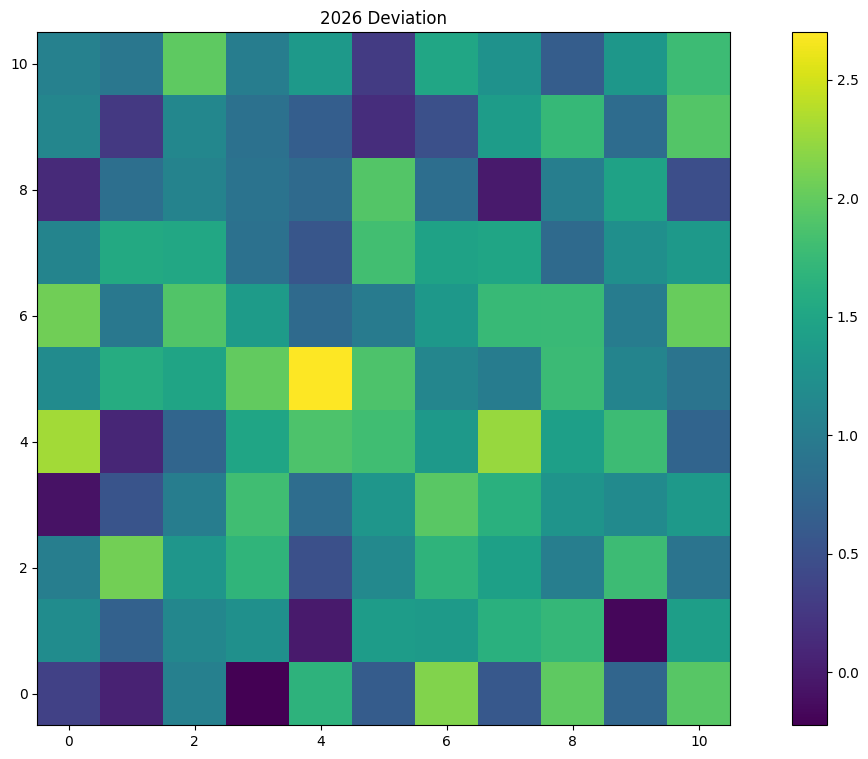

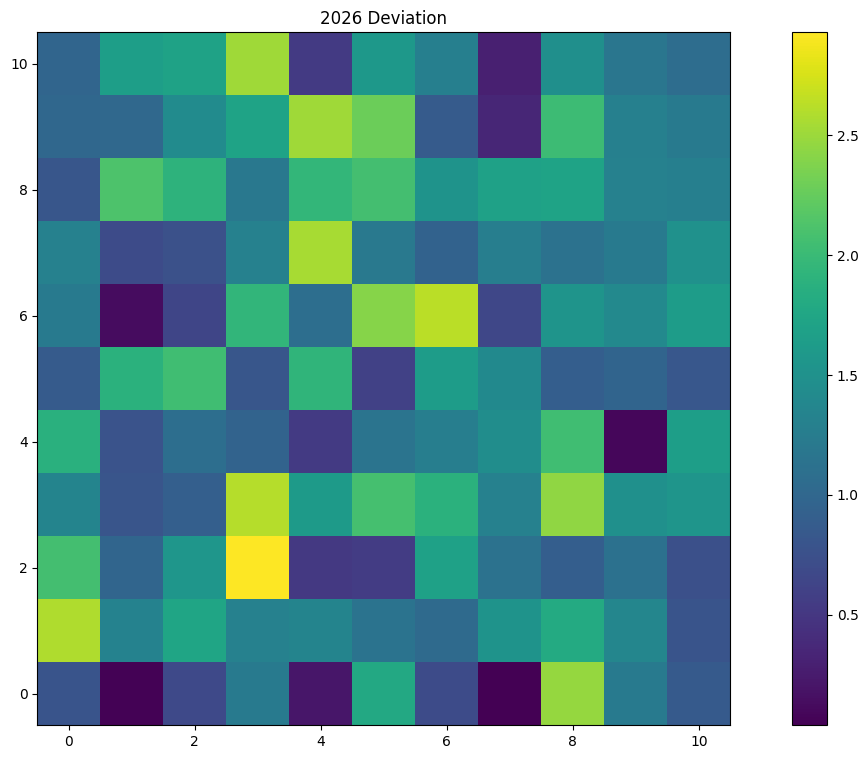

In [8]:
#define the x, y position of the knot
dev_x = [473, round(473 - x_offset)]
dev_y = [1240, round(1240 - y_offset)]
#define the size of the image
size_dev = [5, 5]
i=0
#creates the first image
std_04 = hdu_1_A.data[dev_y[i]-size_dev[i]:dev_y[i]+size_dev[i]+1, dev_x[i]-size_dev[i]:dev_x[i]+size_dev[i]+1]
#this normalizes the data to elimnate the changes in brightness and reduces error
fig, ax = plt.subplots(1, 1, figsize=(16, 9))
plt.imshow(std_04, vmin=np.min(std_04), vmax=np.max(std_04), origin="lower")
plt.colorbar()
title_1 = "2026 Deviation"
ax.set_title(title_1)
std_17 = hdu_2_A.data[dev_y[i+1]-size_dev[i+1]:dev_y[i+1]+size_dev[i+1]+1, dev_x[i+1]-size_dev[i+1]:dev_x[i+1]+size_dev[i+1]+1]
#this normalizes the data to elimnate the changes in brightness and reduces error
fig, ax = plt.subplots(1, 1, figsize=(16, 9))
plt.imshow(std_17, vmin=np.min(std_17), vmax=np.max(std_17), origin="lower")
plt.colorbar()
title_2 = "2026 Deviation"
ax.set_title(title_2)
dev_04 = np.std(std_04)
dev_17 = np.std(std_17)
deviation = np.sqrt(dev_04*dev_17)
print (dev_04, dev_17, deviation)

In [9]:
#this is where the data is stored for processing graphs at the end of calculating all of the knots
velocity_storage_x = []
velocity_storage_y = []
x_error = []
y_error = []
error_bar = []

minimum chi squared value =  3.0717773 , X shift =  -2.0222624120500456 , Y shift =  -0.6213612807726545
Error ± 0.0
x error ± 0.0 y error ± 0.0
angle = 107.08012316228336
angle error ± 0.0


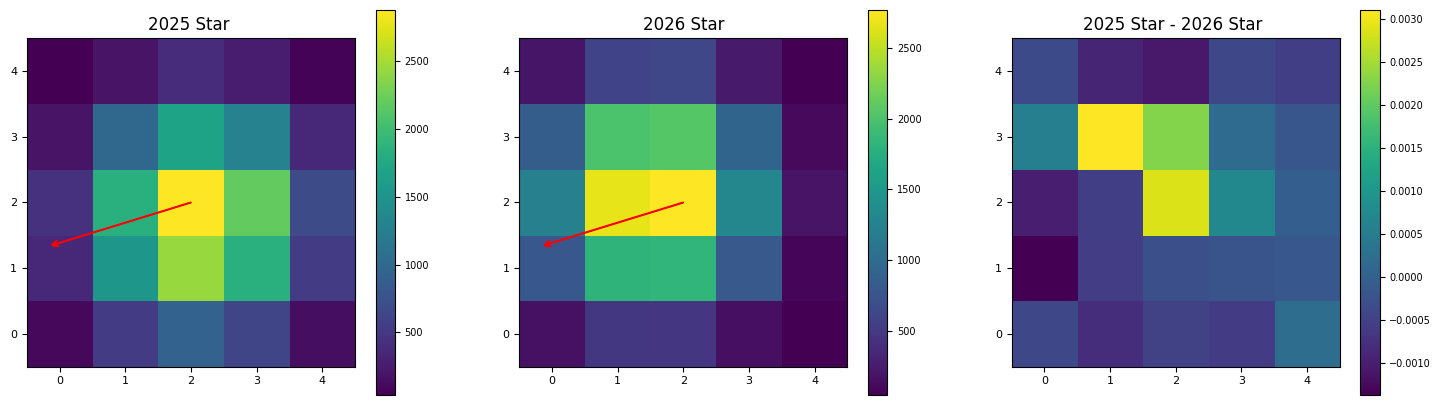

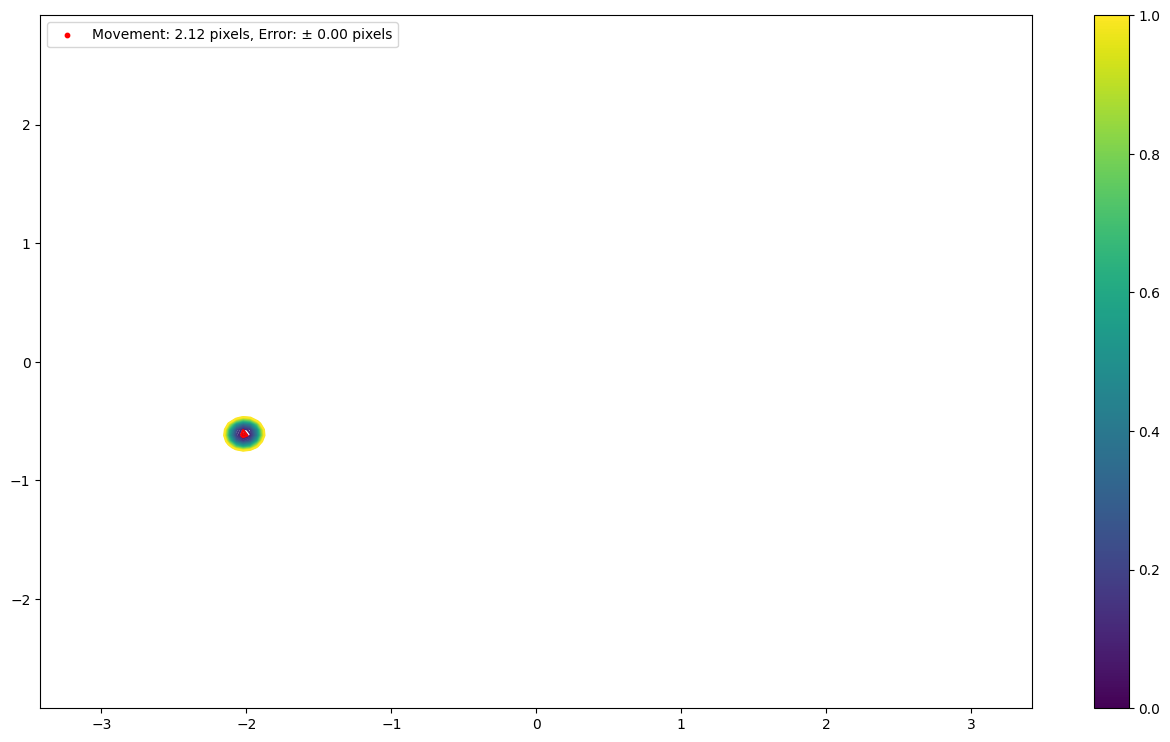

In [10]:
#1
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [177, round(177 - x_offset) -1]
cy_chi = [1910, round(1910 - y_offset)-1]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  1.646252 , X shift =  0.03096911211099207 , Y shift =  -0.053867907557898054
Error ± 0.0
x error ± 0.0 y error ± 0.0
angle = -150.10504289660147
angle error ± 0.0


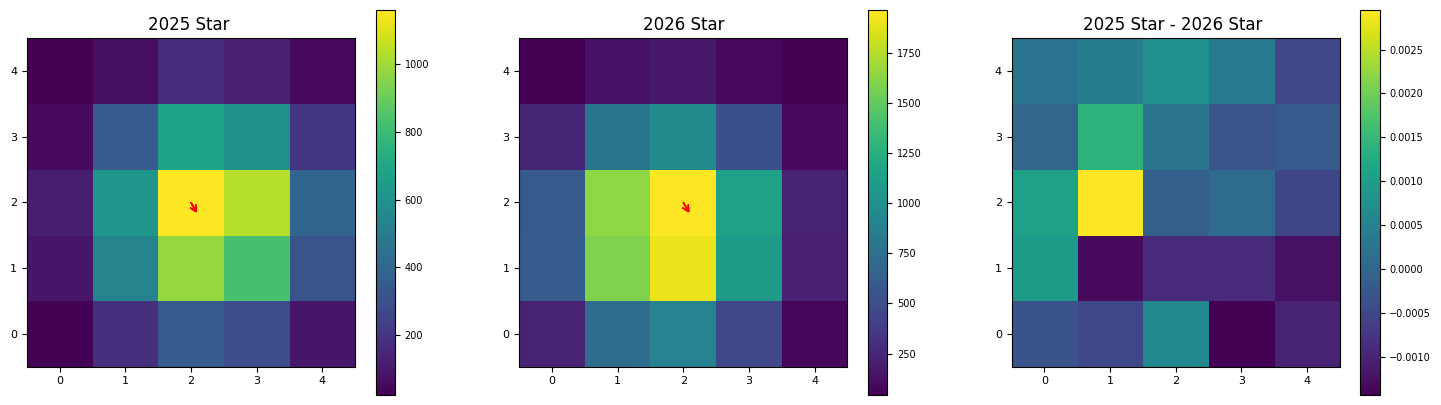

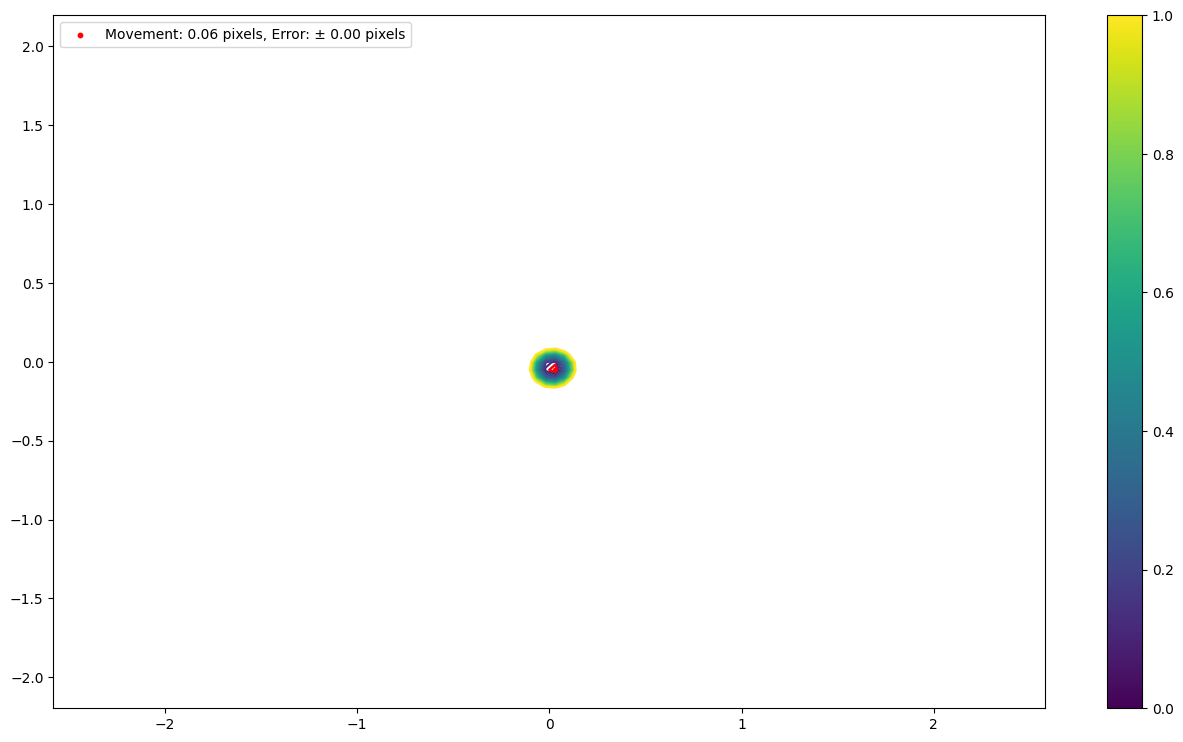

In [11]:
#2
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [1311, round(1311 - x_offset) +1]
cy_chi = [1752, round(1752 - y_offset)]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  21.473133 , X shift =  -0.6257299801562255 , Y shift =  0.10612980805151748
Error ± 0.05086633806787691
x error ± 0.050000000000000044 y error ± 0.07500000000000001
angle = 80.37369639156857
angle error ± 6.7179763978719045


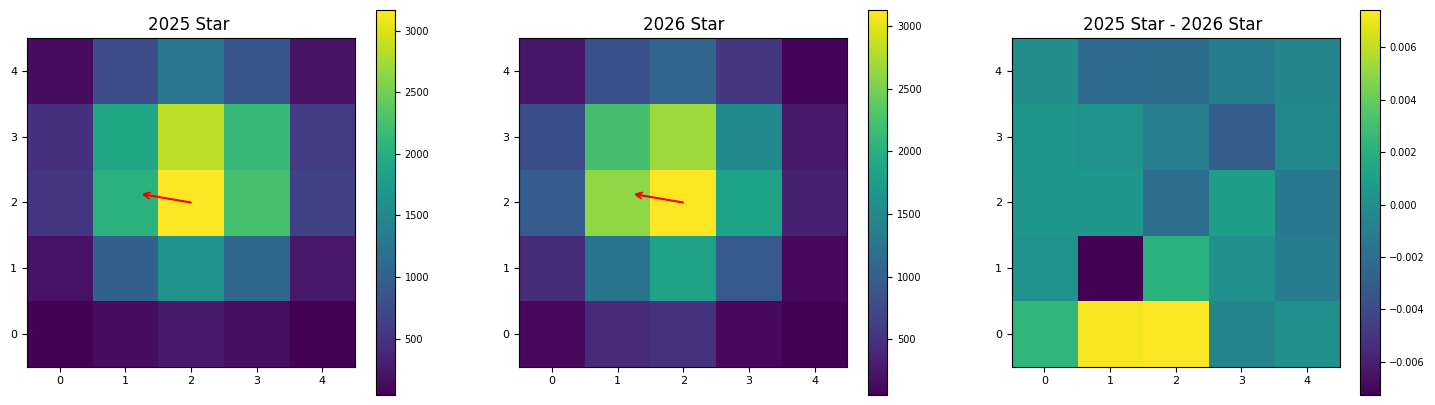

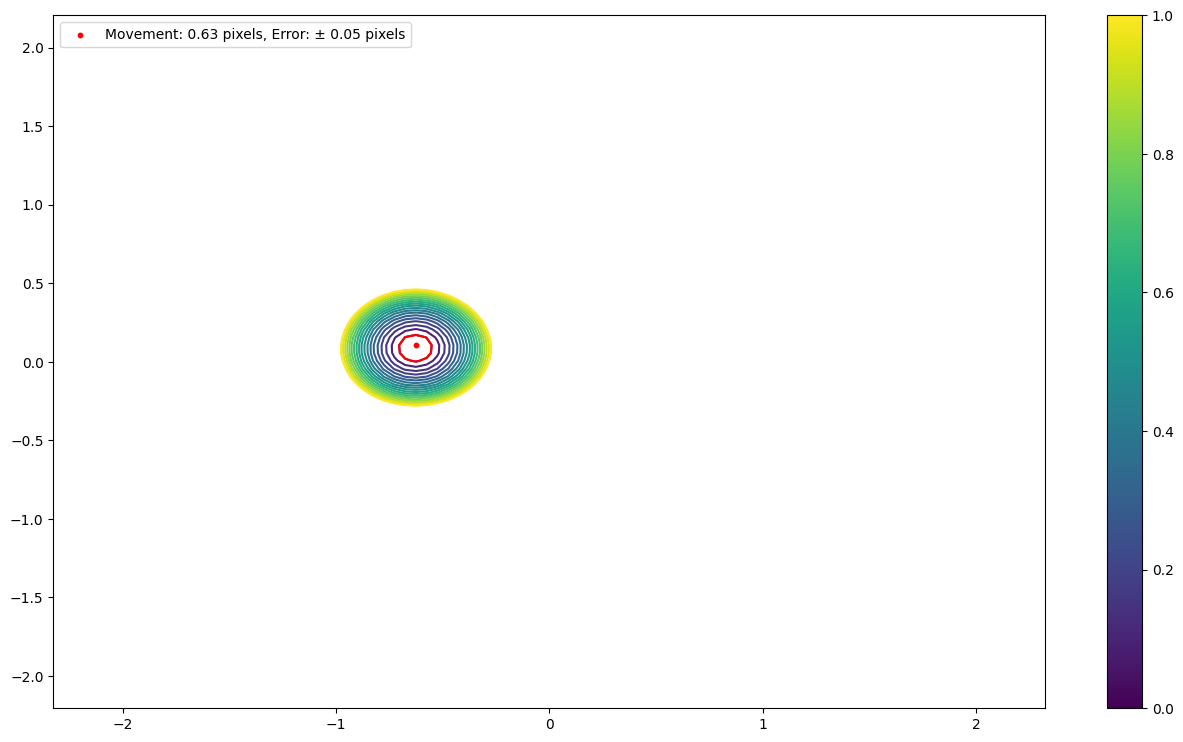

In [12]:
#3
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [1688, round(1688 - x_offset) ]
cy_chi = [1090, round(1090 - y_offset) ]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  0.26877776 , X shift =  0.053150548353264104 , Y shift =  0.03165182425339336
Error ± 0.04999999999999998
x error ± 0.04999999999999999 y error ± 0.04999999999999999
angle = -59.225666188591646
angle error ± 46.30988356725491


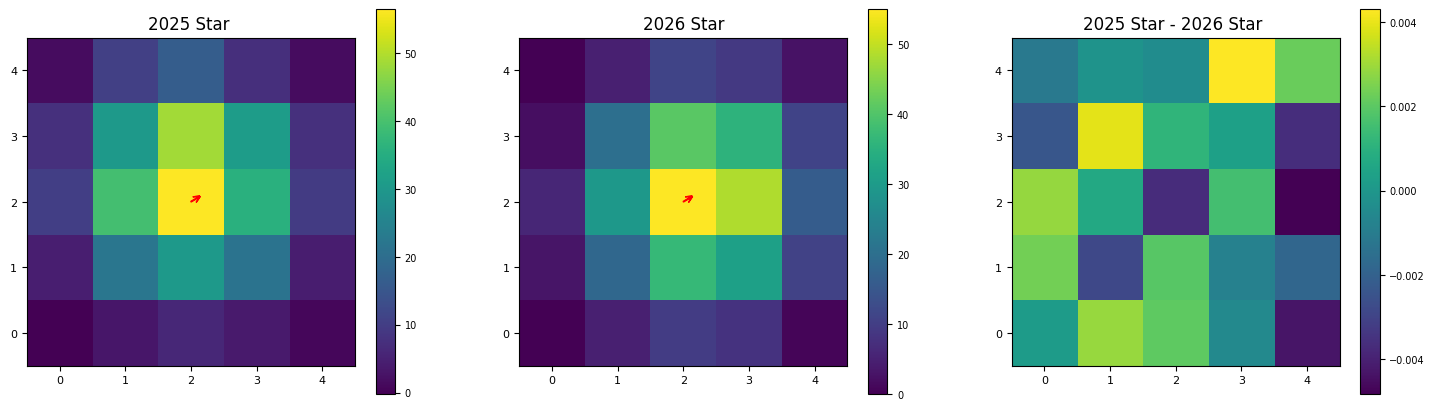

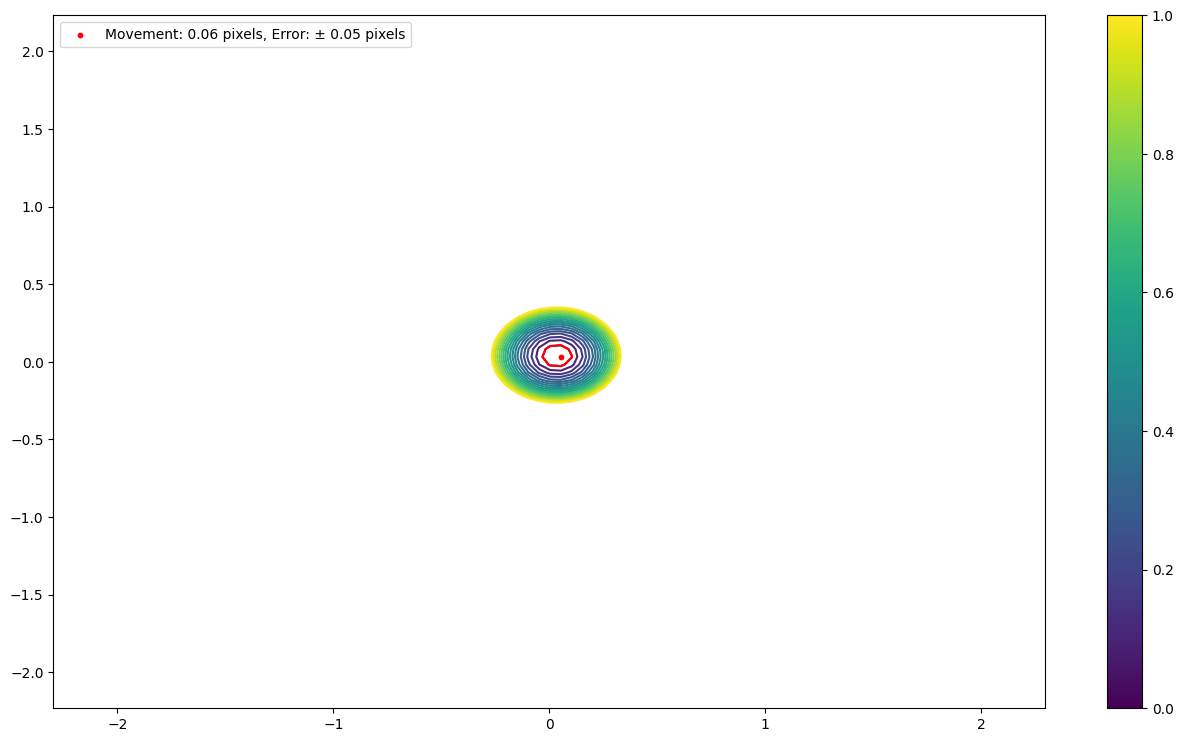

In [13]:
#4
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [1965, round(1965 - x_offset) ]
cy_chi = [1054, round(1054 - y_offset) ]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  4.803473 , X shift =  -0.055142466340626584 , Y shift =  0.009796967157902514
Error ± 0.025000000000000022
x error ± 0.025000000000000022 y error ± 0.024999999999999994
angle = 79.92558439787115
angle error ± 25.575732235846733


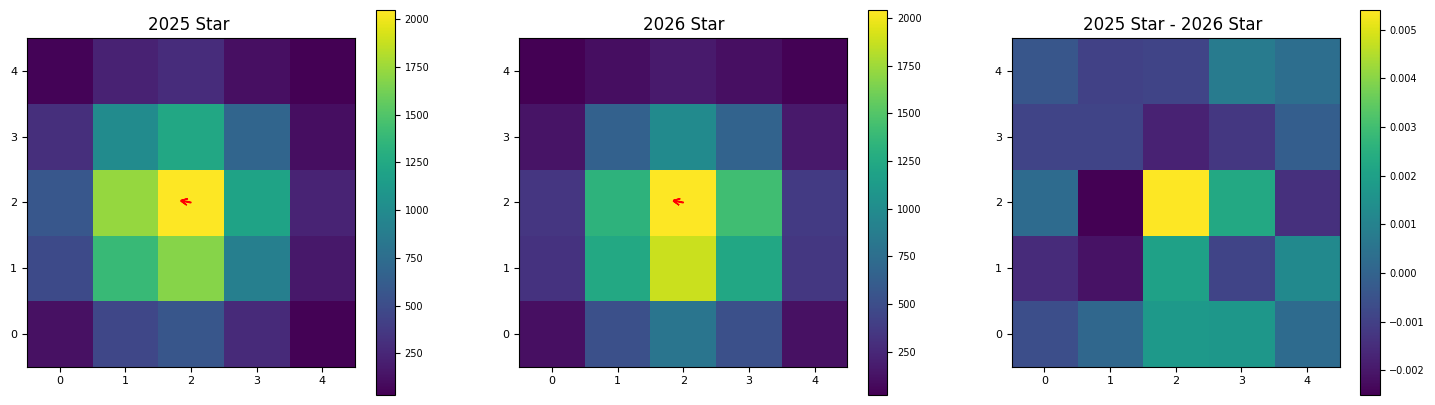

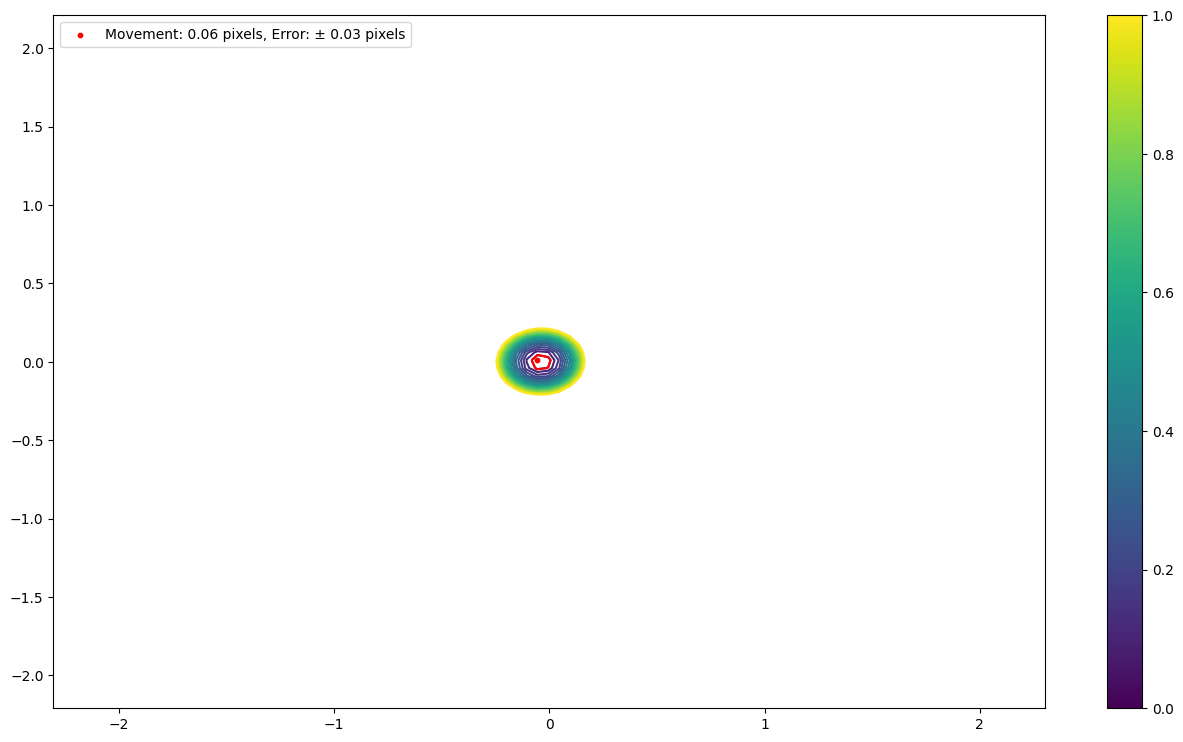

In [14]:
#5
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [1777, round(1777 - x_offset) ]
cy_chi = [966, round(966 - y_offset)]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  15.455533 , X shift =  -0.028385991384848763 , Y shift =  0.00636662040042521
Error ± 0.04909374704867809
x error ± 0.05000000000000002 y error ± 0.02500000000000001
angle = 77.35848366031375
angle error ± 52.656788647277125


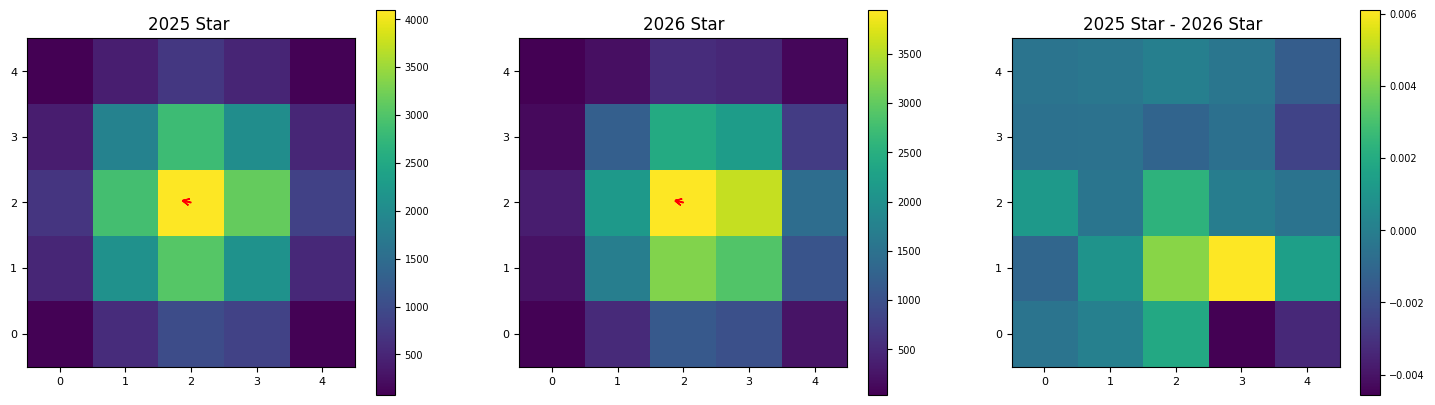

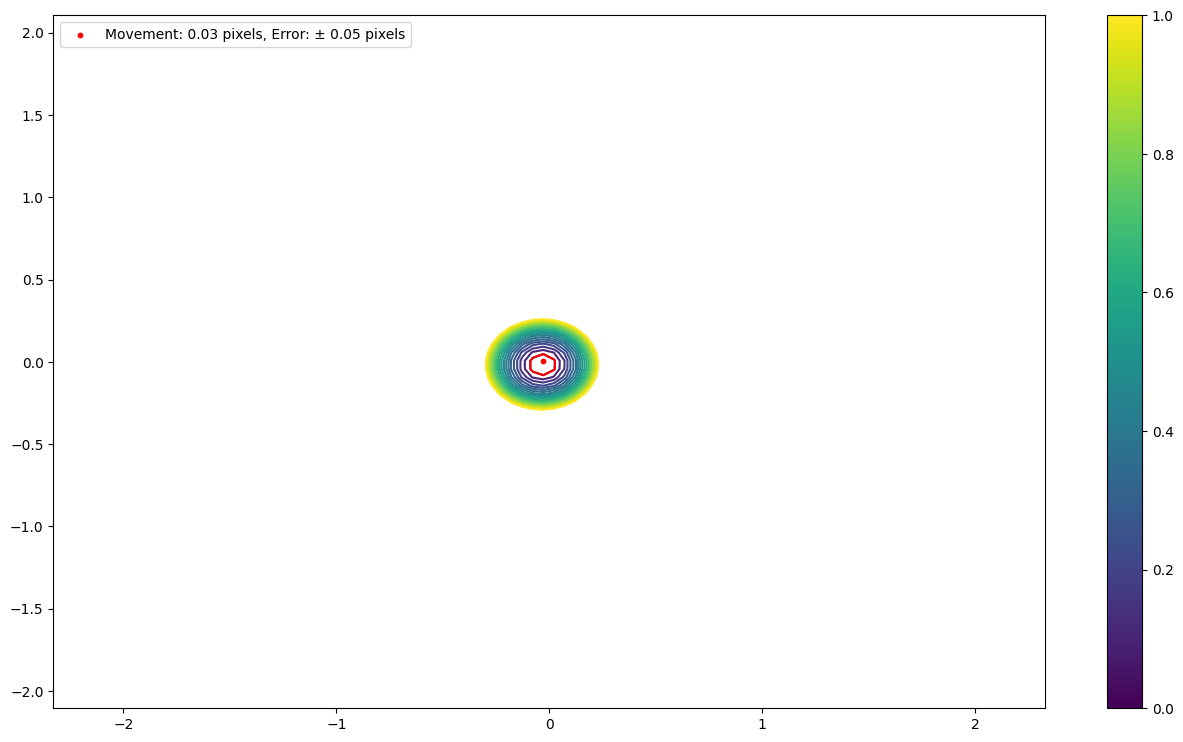

In [15]:
#6
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [673, round(673 - x_offset)]
cy_chi = [778, round(778 - y_offset)]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  3.3485575 , X shift =  -0.03273215762098114 , Y shift =  0.0005097181747063528
Error ± 0.024999999999999994
x error ± 0.024999999999999994 y error ± 0.02500000000000001
angle = 89.10783944876812
angle error ± 43.75577248739987


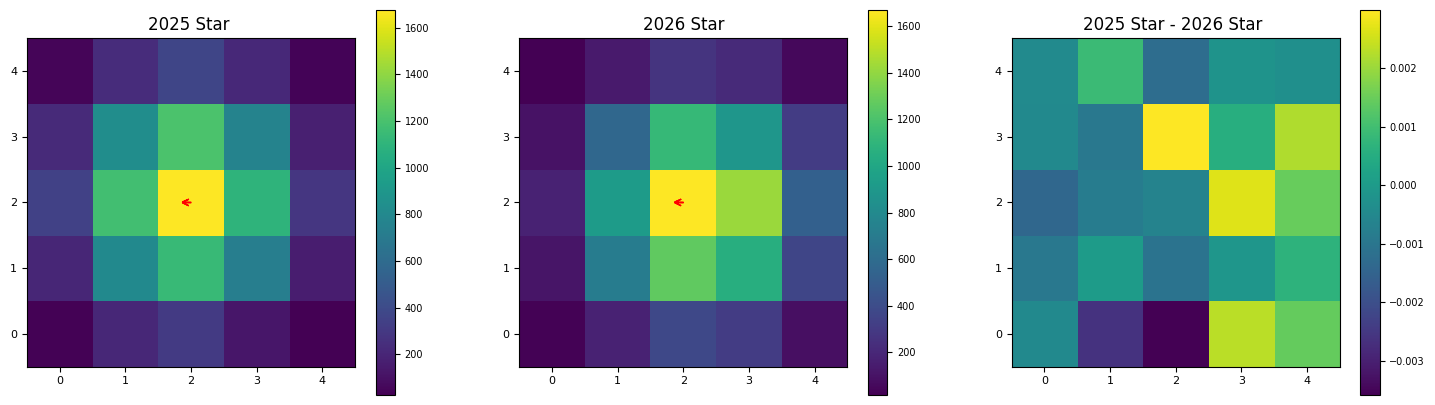

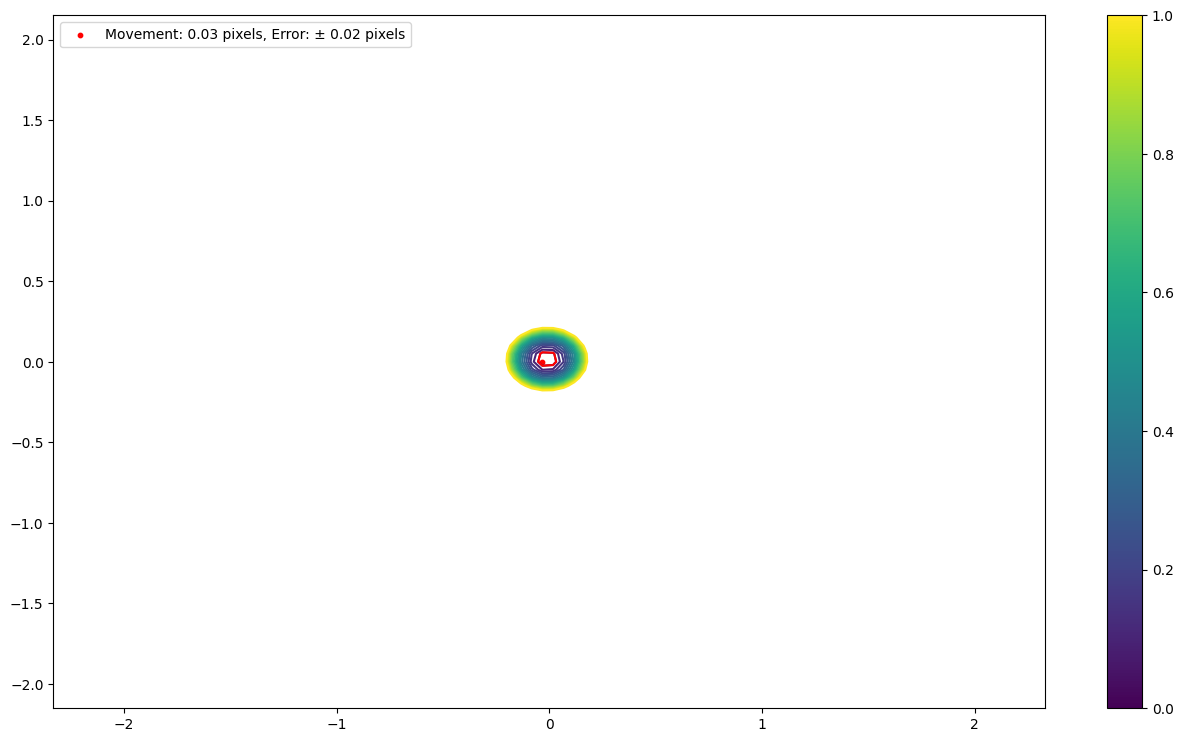

In [16]:
#7
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [1161, round(1161 - x_offset) ]
cy_chi = [874, round(874 - y_offset)]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  14.626296 , X shift =  0.04736312332069581 , Y shift =  -0.0005138869349676362
Error ± 0.02499999999999997
x error ± 0.024999999999999967 y error ± 0.025
angle = -90.62163124307803
angle error ± 30.24104162242522


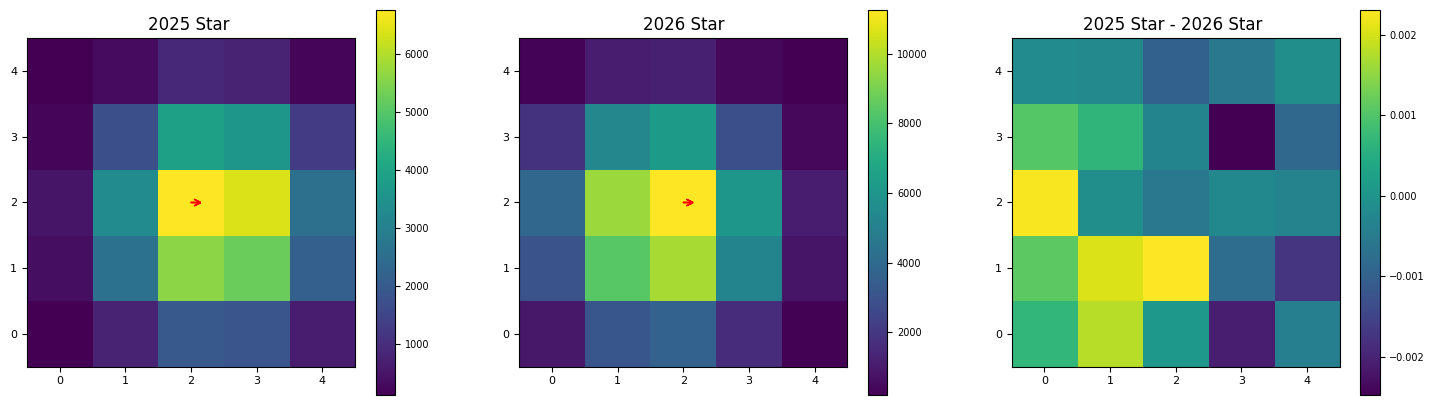

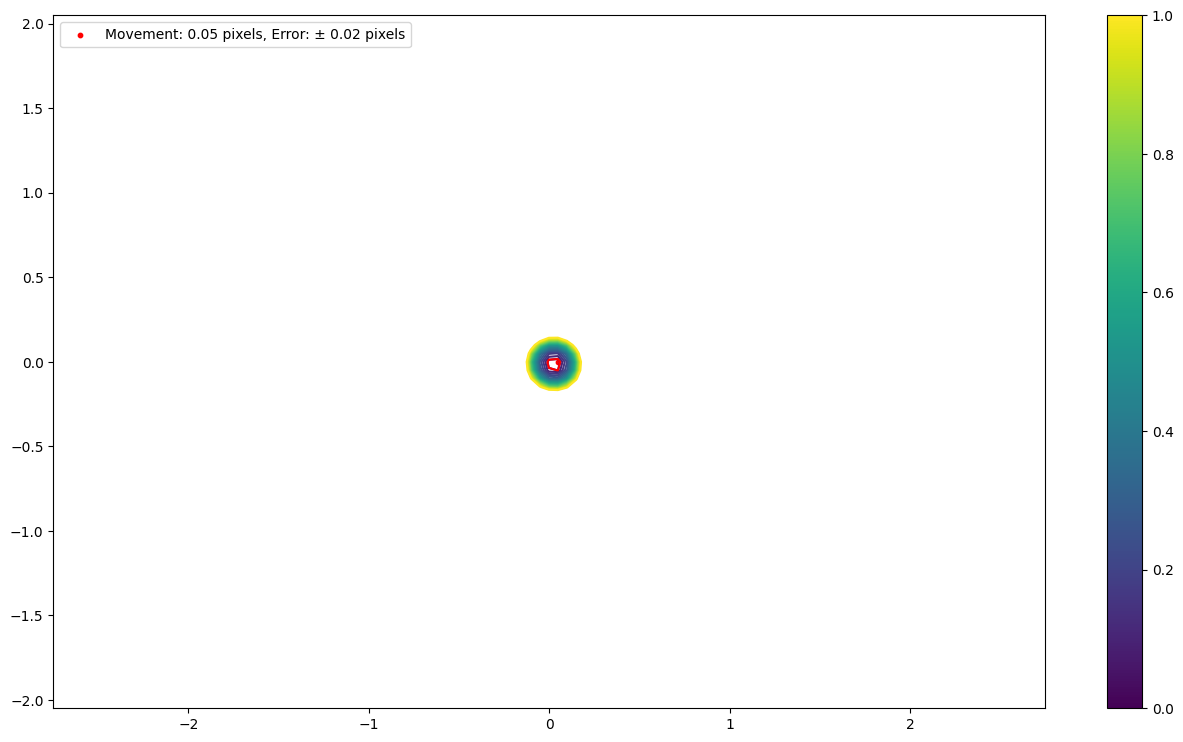

In [17]:
#8
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [41, round(41 - x_offset) +1]
cy_chi = [430, round(430 - y_offset)]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  3.925424 , X shift =  -0.004536257295228552 , Y shift =  0.0032090516923662243
Error ± 0.0
x error ± 0.0 y error ± 0.0
angle = 54.723542306037
angle error ± 0.0


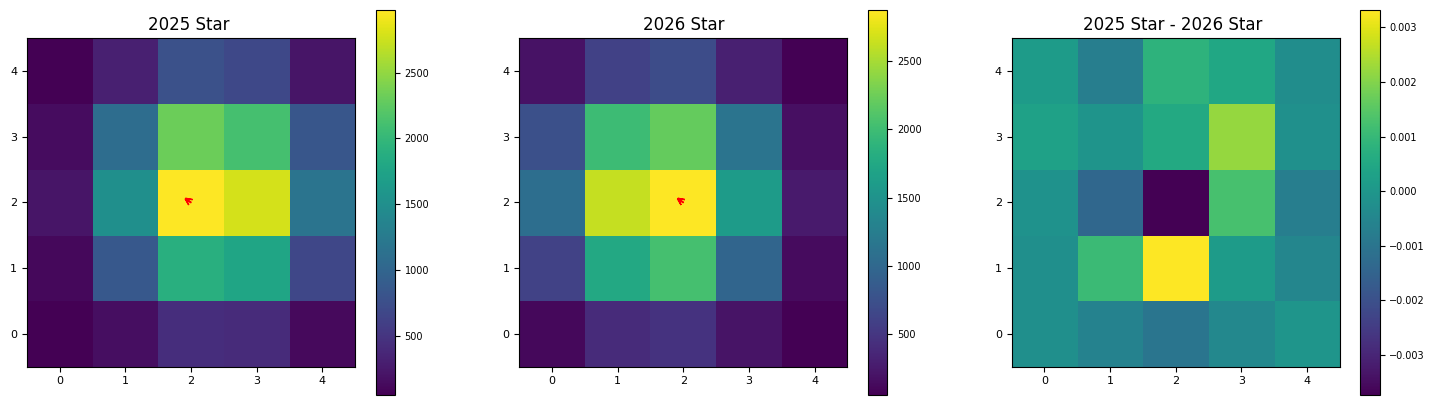

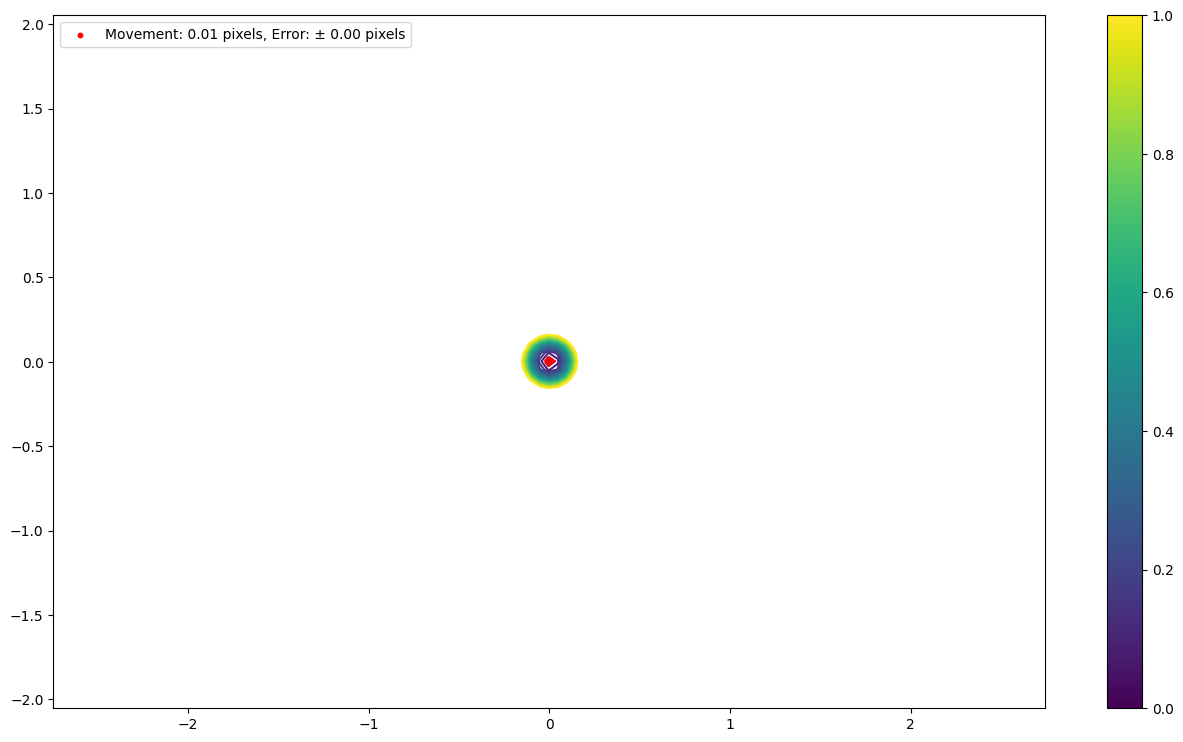

In [18]:
#9
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [88, round(88 - x_offset) +1]
cy_chi = [420, round(420 - y_offset)]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  0.789378 , X shift =  0.03473590548177008 , Y shift =  -0.029114788608384595
Error ± 0.07499999999999998
x error ± 0.07499999999999996 y error ± 0.07500000000000001
angle = -129.96891776585008
angle error ± 94.81058371030348


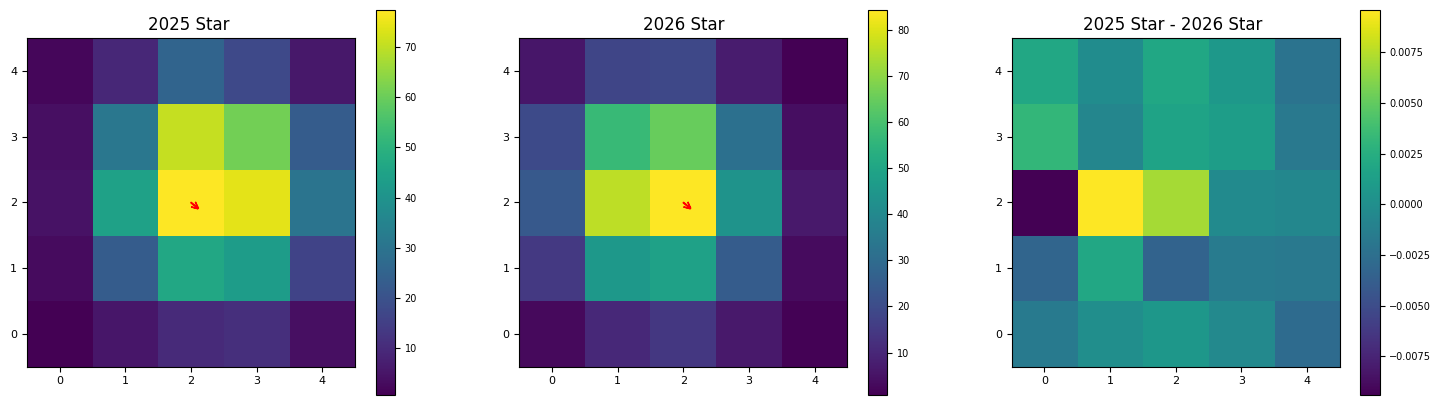

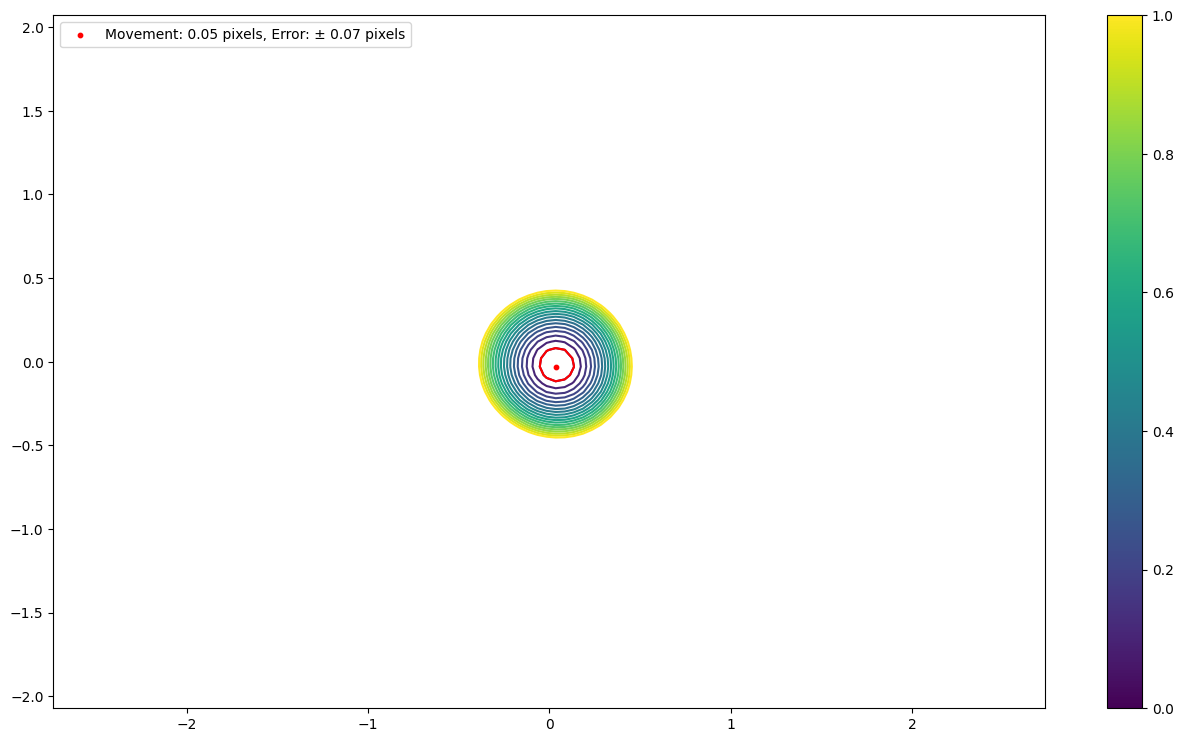

In [19]:
#10
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [314, round(314 - x_offset) +1]
cy_chi = [403, round(403 - y_offset)]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  0.49174872 , X shift =  -0.028748951731316197 , Y shift =  -0.11005751748980092
Error ± 0.04999999999999999
x error ± 0.05000000000000002 y error ± 0.04999999999999999
angle = 165.36046155966486
angle error ± 25.184863741646147


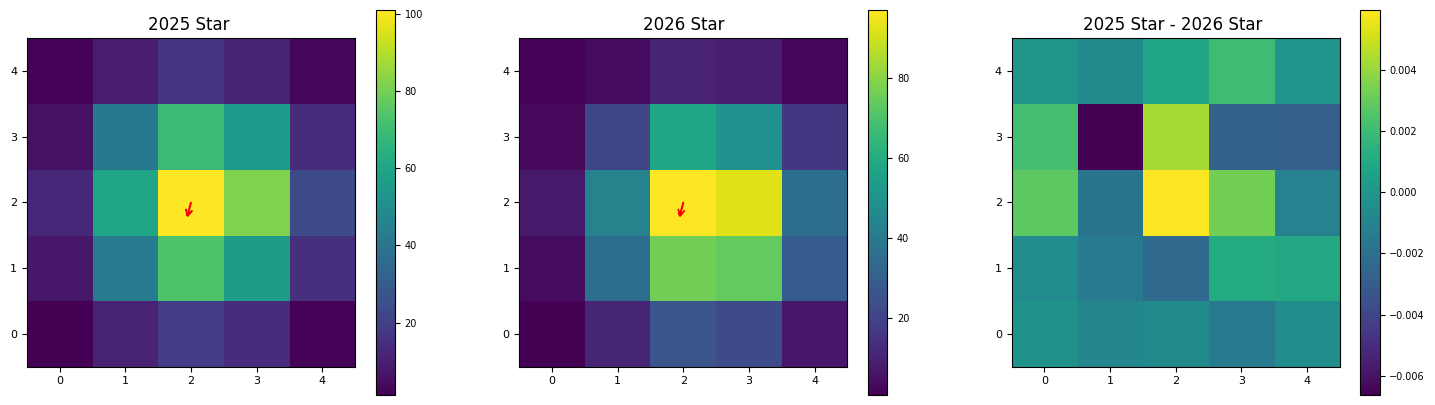

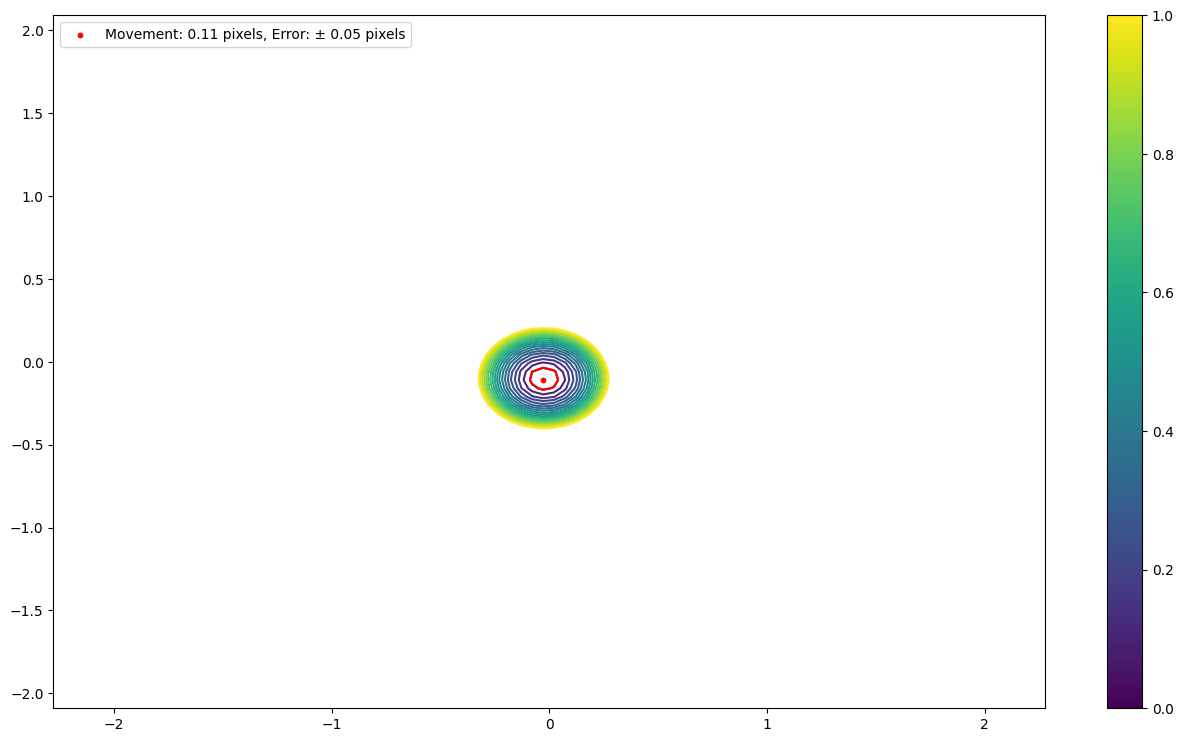

In [20]:
#11
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [471, round(471 - x_offset)]
cy_chi = [404, round(404 - y_offset)]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  2.0631642 , X shift =  0.022588742156798958 , Y shift =  -0.04127124146117156
Error ± 0.02499999999999999
x error ± 0.024999999999999994 y error ± 0.024999999999999994
angle = -151.30705276372225
angle error ± 30.445025360947263


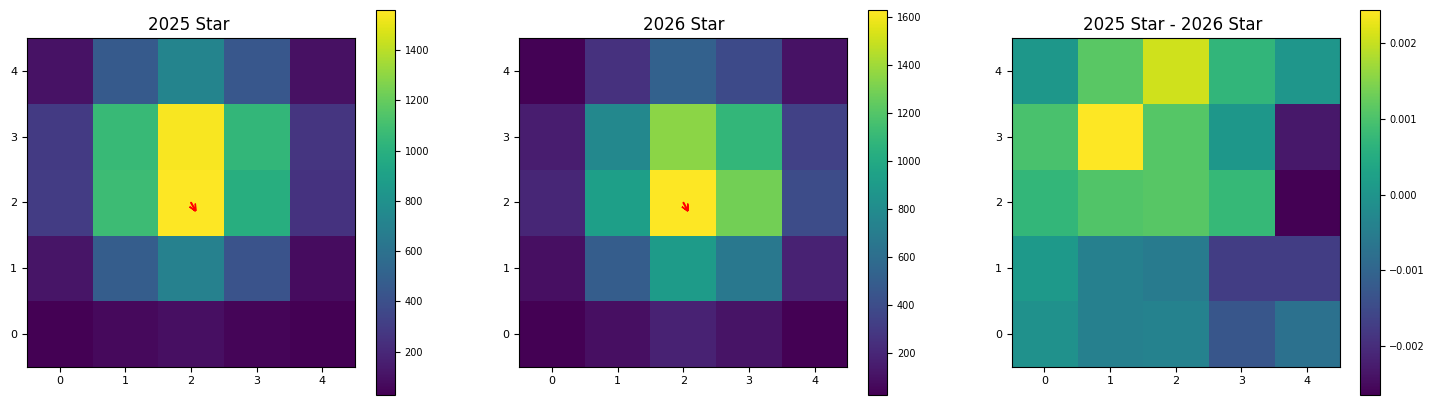

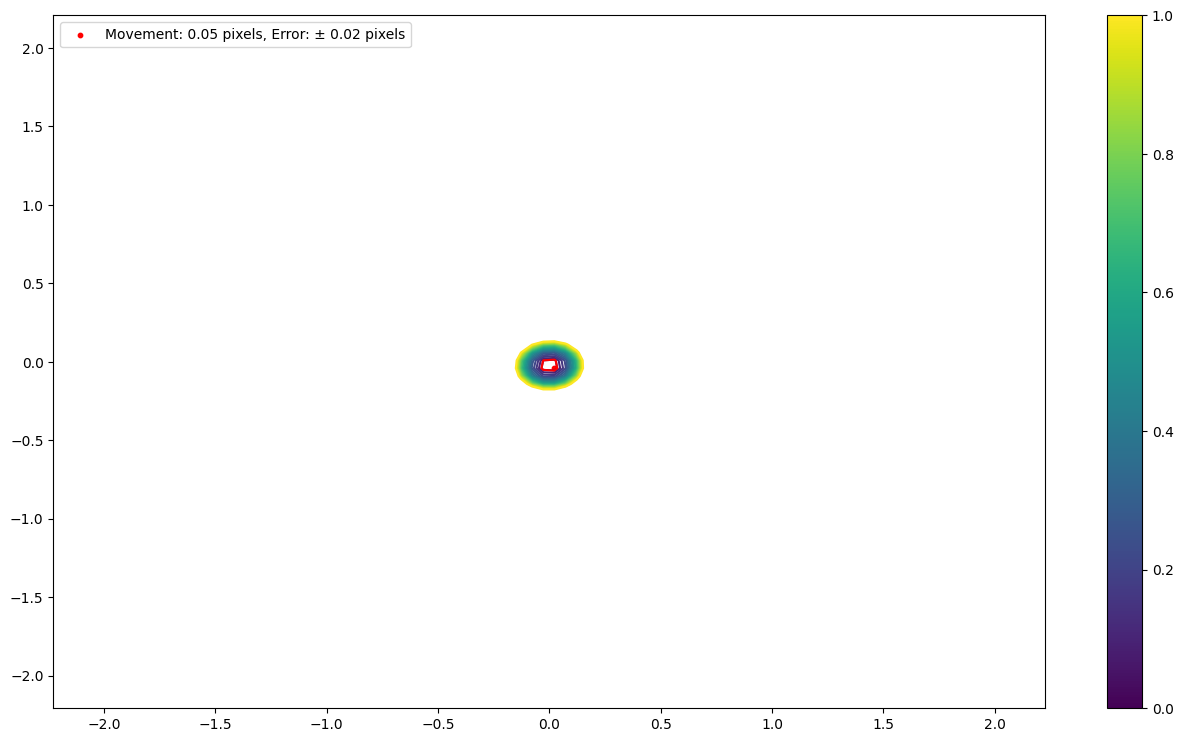

In [21]:
#12
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [2001, round(2001 - x_offset)]
cy_chi = [481, round(481 - y_offset)]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  2.330514 , X shift =  0.01429248350881096 , Y shift =  -0.010099508425912257
Error ± 0.024999999999999994
x error ± 0.024999999999999994 y error ± 0.025
angle = -125.24620277669148
angle error ± 81.84775218268994


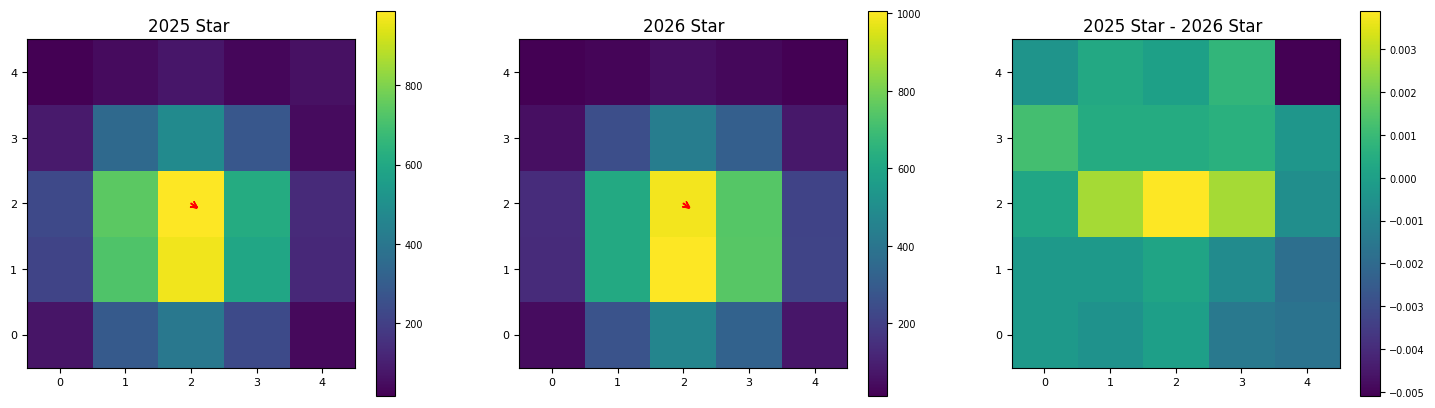

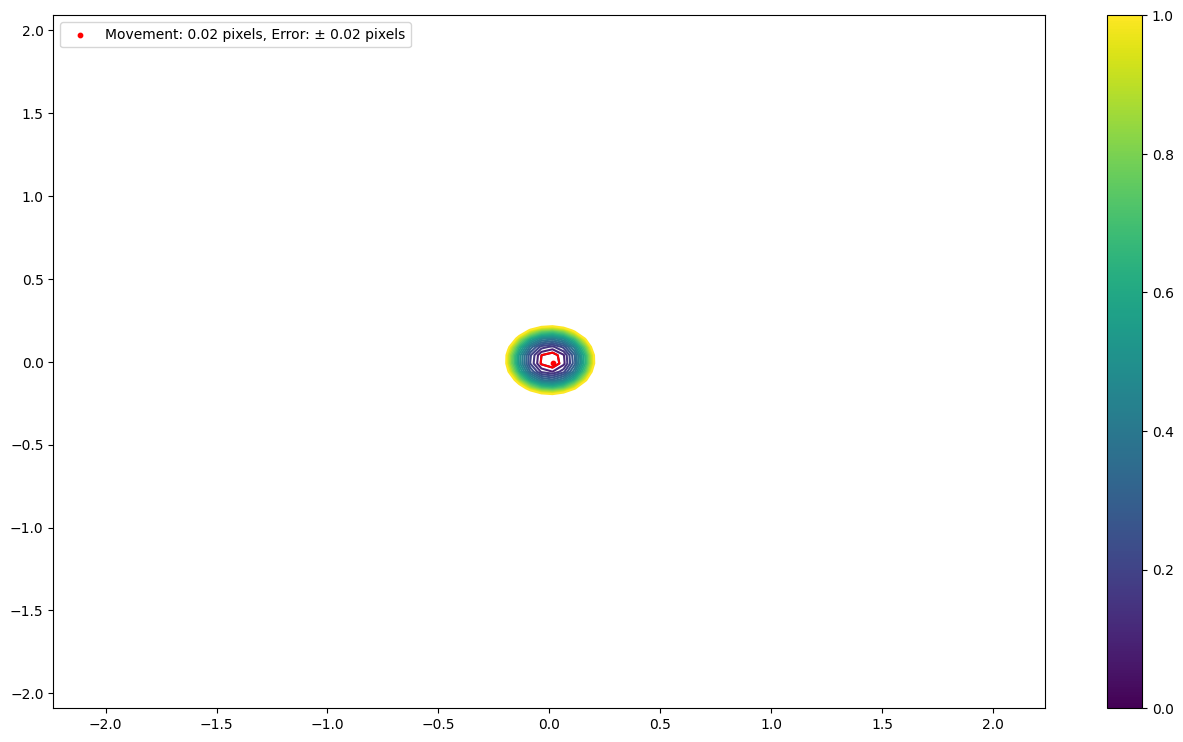

In [22]:
#13
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [433, round(433 - x_offset)]
cy_chi = [96, round(96 - y_offset)]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  9.063947 , X shift =  0.0012561007026619109 , Y shift =  0.01214121582401359
Error ± 0.05000000000000001
x error ± 0.05000000000000002 y error ± 0.05000000000000001
angle = -5.906668067560242
angle error ± 234.70296675036963


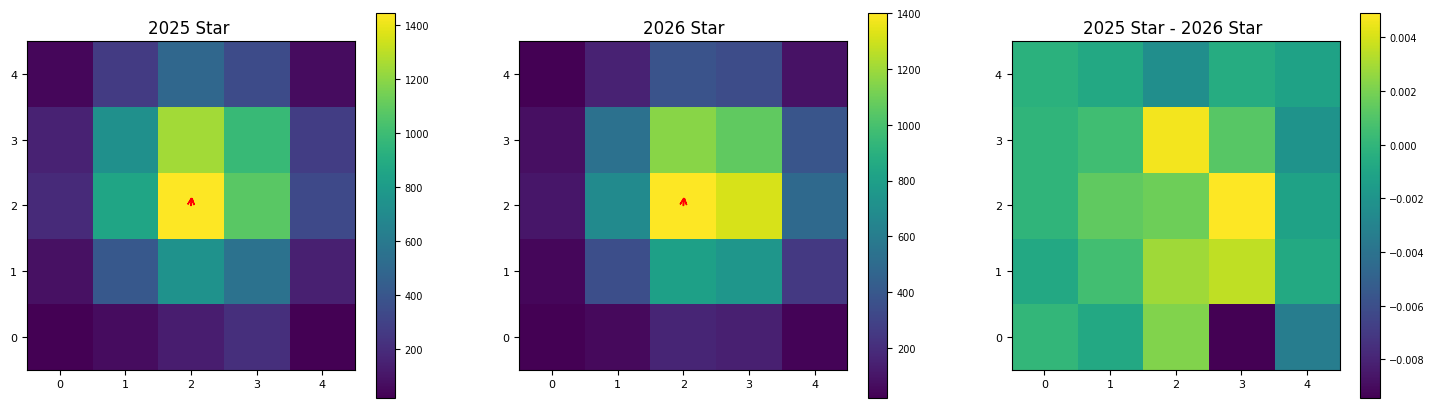

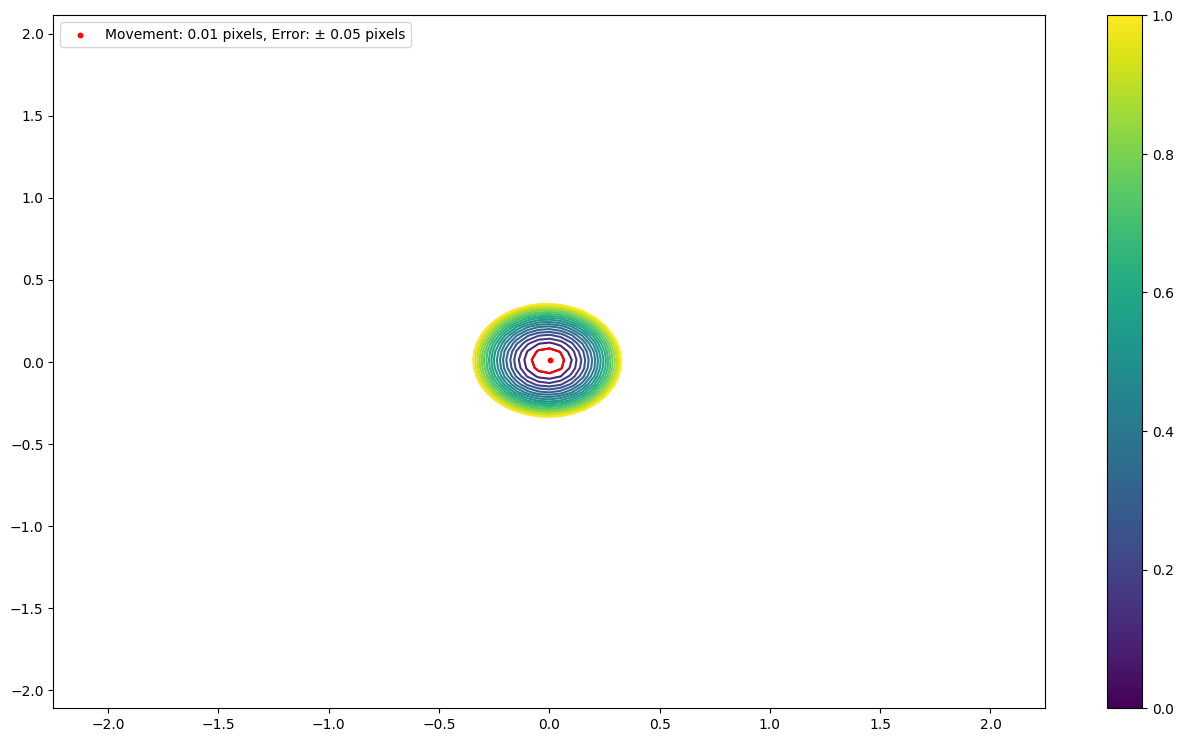

In [23]:
#14
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [784, round(784 - x_offset)]
cy_chi = [142, round(142 - y_offset)]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

In [24]:
velocity_storage_x_dither_1_1 = velocity_storage_x
velocity_storage_y_dither_1_1 = velocity_storage_y
x_error_dither_1_1 = x_error
y_error_dither_1_1 = y_error
error_bar_dither_1_1 = error_bar

# **Dither 1 25 to Dither 2 26**

In [25]:
hdu_1_A = fits.open((path_image_1 + 'nan_rm_jwst_2025_f444w_f470n_d1_frame_A.fits'))[1]
hdu_2_A = fits.open((path_image_2 + 'nan_rm_jwst_2026_f444w_f470n_d2_frame_A.fits'))[1]

In [26]:
x_offset = -12.495028577445993
y_offset  = 170.3179026395524

0.58599424 0.5256879 0.5550226


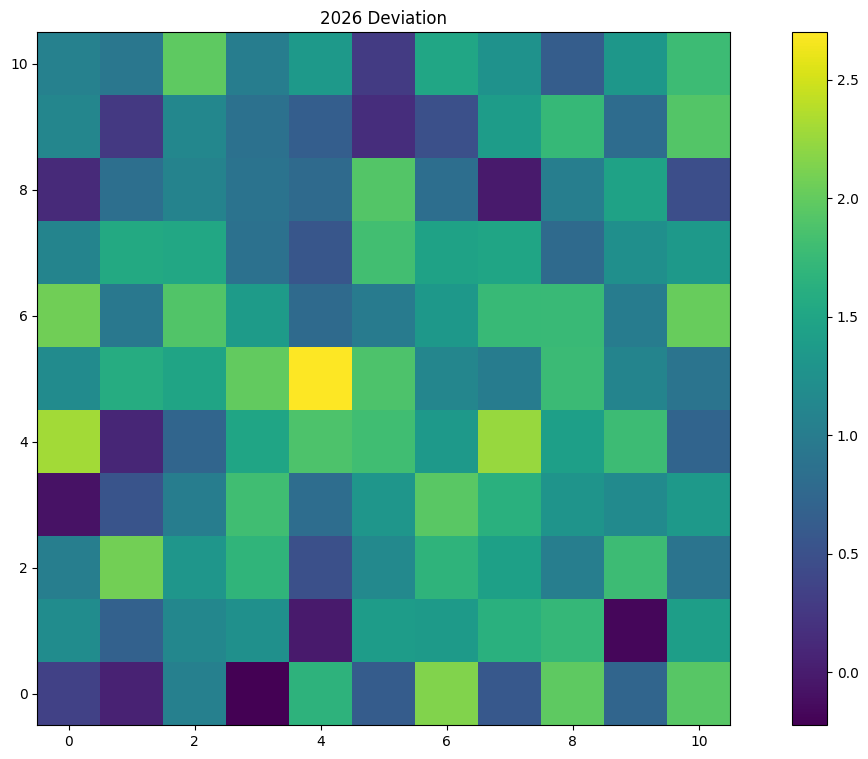

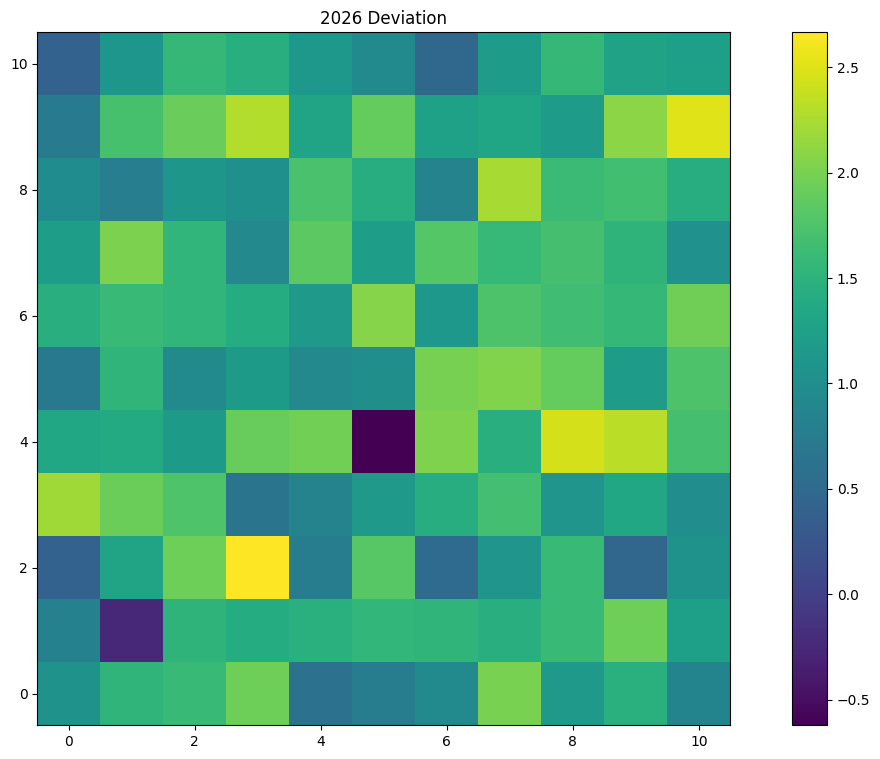

In [27]:
#define the x, y position of the knot
dev_x = [473, round(473 - x_offset)]
dev_y = [1240, round(1240 - y_offset)]
#define the size of the image
size_dev = [5, 5]
i=0
#creates the first image
std_04 = hdu_1_A.data[dev_y[i]-size_dev[i]:dev_y[i]+size_dev[i]+1, dev_x[i]-size_dev[i]:dev_x[i]+size_dev[i]+1]
#this normalizes the data to elimnate the changes in brightness and reduces error
fig, ax = plt.subplots(1, 1, figsize=(16, 9))
plt.imshow(std_04, vmin=np.min(std_04), vmax=np.max(std_04), origin="lower")
plt.colorbar()
title_1 = "2026 Deviation"
ax.set_title(title_1)
std_17 = hdu_2_A.data[dev_y[i+1]-size_dev[i+1]:dev_y[i+1]+size_dev[i+1]+1, dev_x[i+1]-size_dev[i+1]:dev_x[i+1]+size_dev[i+1]+1]
#this normalizes the data to elimnate the changes in brightness and reduces error
fig, ax = plt.subplots(1, 1, figsize=(16, 9))
plt.imshow(std_17, vmin=np.min(std_17), vmax=np.max(std_17), origin="lower")
plt.colorbar()
title_2 = "2026 Deviation"
ax.set_title(title_2)
dev_04 = np.std(std_04)
dev_17 = np.std(std_17)
deviation = np.sqrt(dev_04*dev_17)
print (dev_04, dev_17, deviation)

In [28]:
#this is where the data is stored for processing graphs at the end of calculating all of the knots
velocity_storage_x = []
velocity_storage_y = []
x_error = []
y_error = []
error_bar = []

minimum chi squared value =  147.98337 , X shift =  -1.9050311412344854 , Y shift =  -0.5355294239365036
Error ± 0.2250000000000001
x error ± 0.2250000000000001 y error ± 0.22499999999999998
angle = 105.70137472352715
angle error ± 6.514594531891309


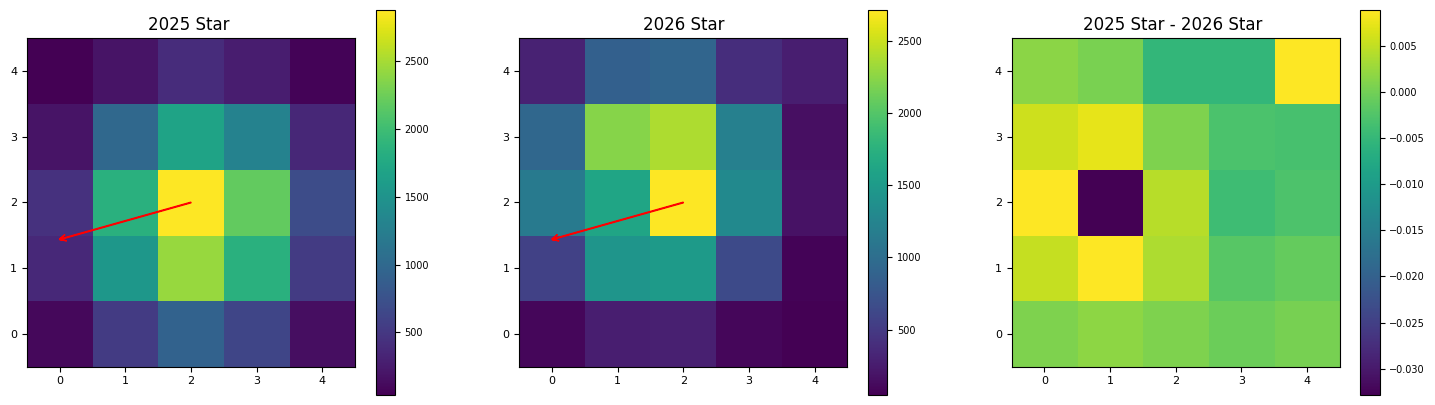

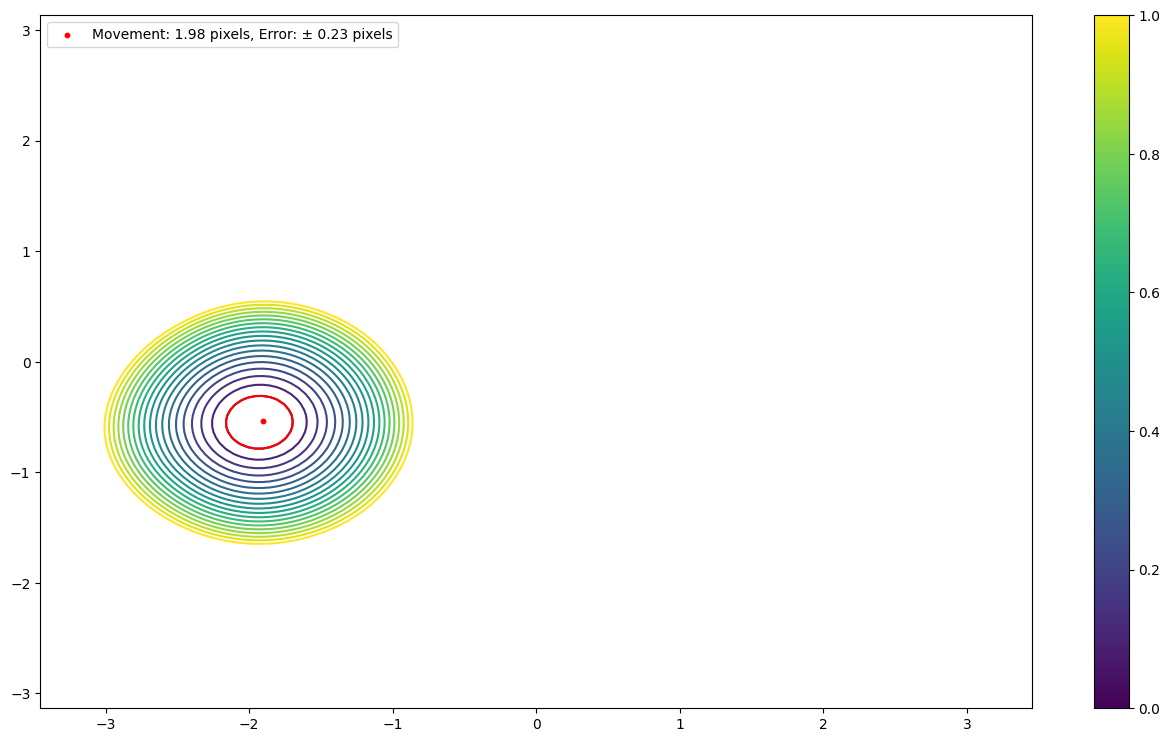

In [29]:
#1
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [177, round(177 - x_offset)]
cy_chi = [1910, round(1910 - y_offset)-3]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  1.6242961 , X shift =  0.002446540101317396 , Y shift =  -0.014256730339928914
Error ± 0.0
x error ± 0.0 y error ± 0.0
angle = -170.26254748284163
angle error ± 0.0


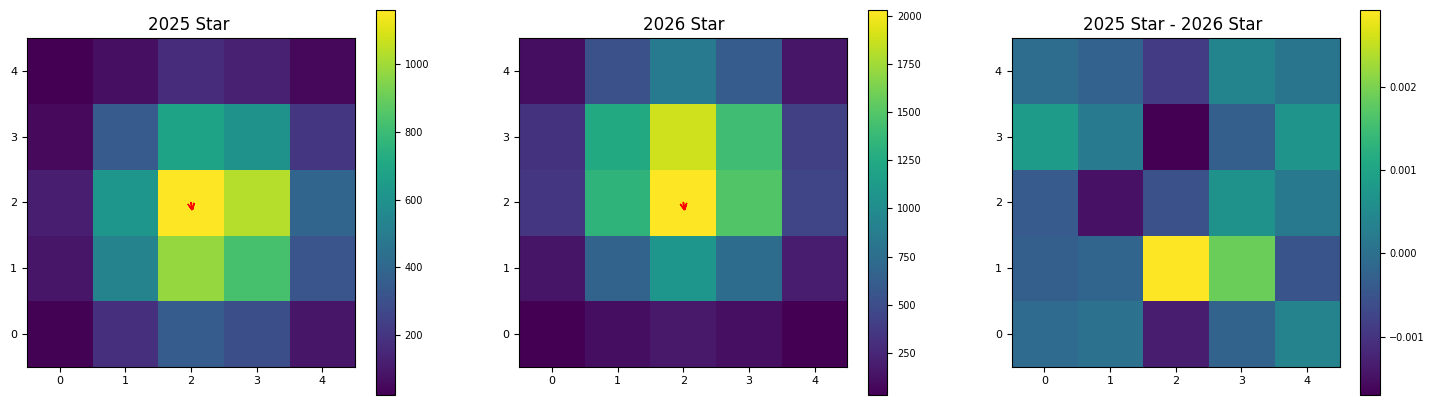

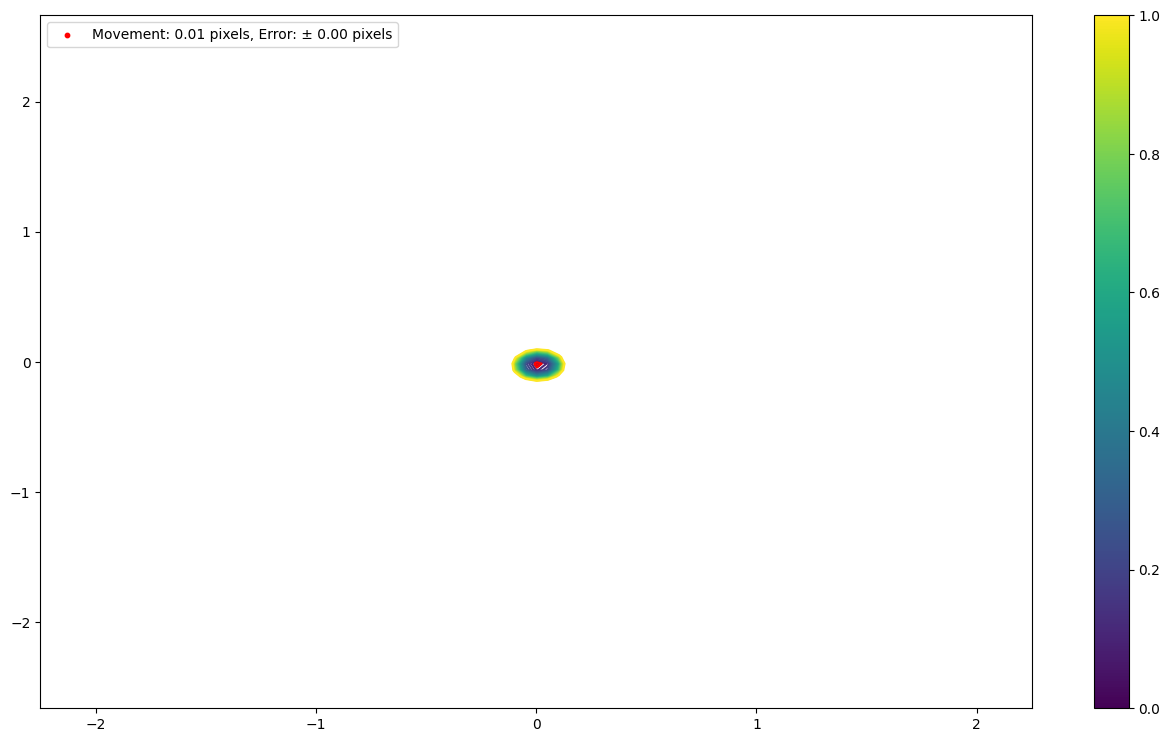

In [30]:
#2
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [1311, round(1311 - x_offset) ]
cy_chi = [1752, round(1752 - y_offset)-2]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  5.346841 , X shift =  -0.6207944399480141 , Y shift =  0.12154284790024683
Error ± 0.0
x error ± 0.0 y error ± 0.0
angle = 78.92241372855699
angle error ± 0.0


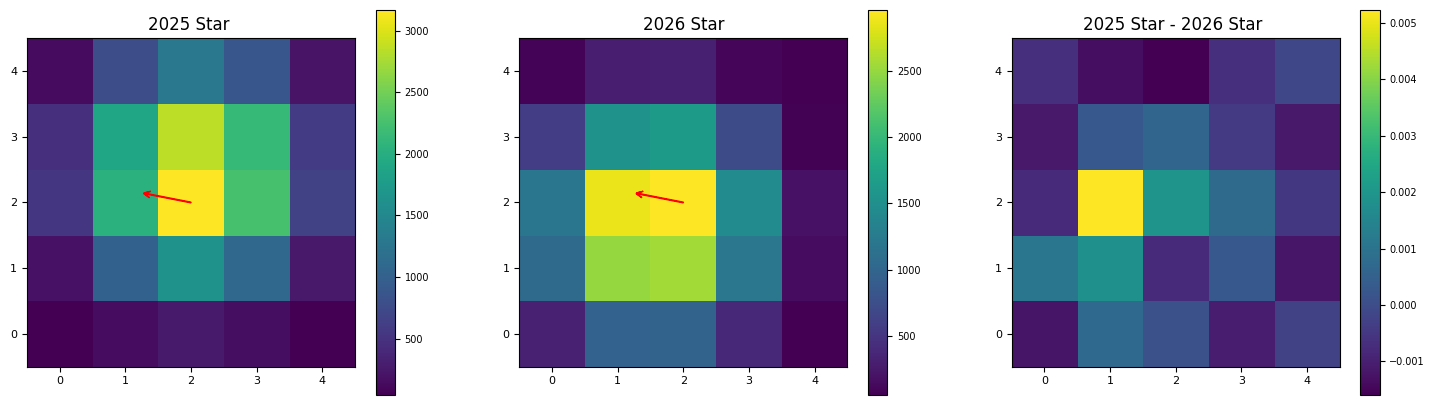

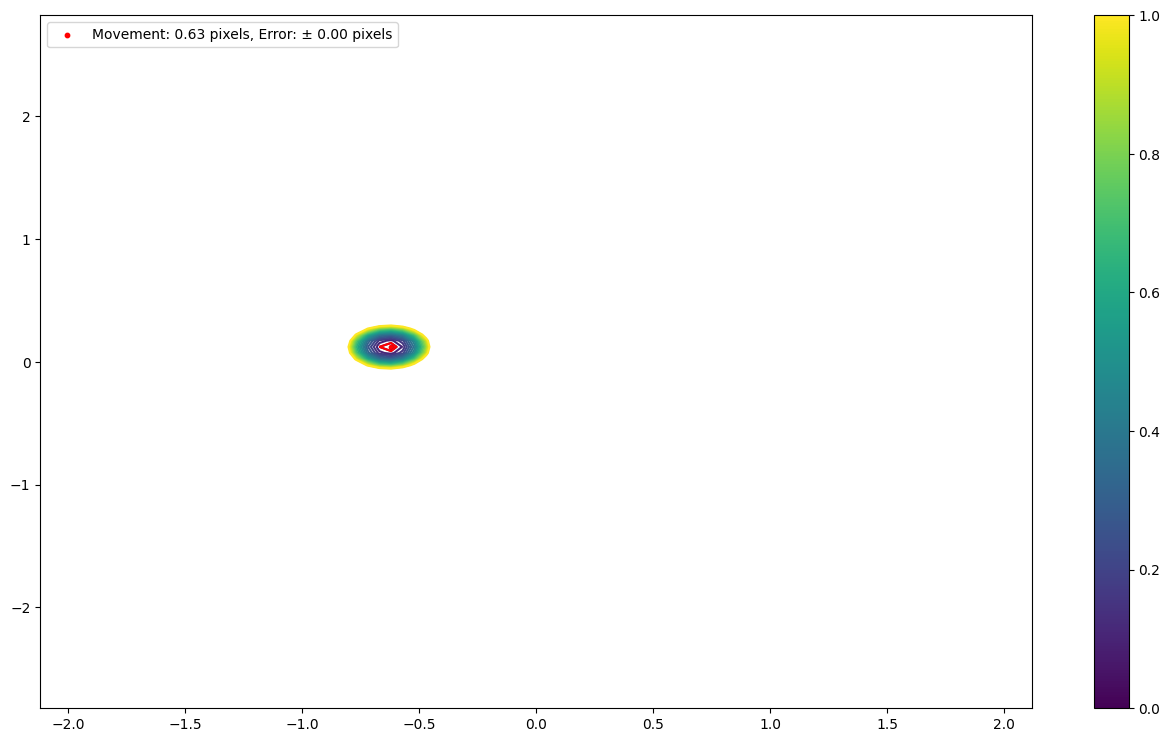

In [31]:
#3
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [1688, round(1688 - x_offset) -1]
cy_chi = [1090, round(1090 - y_offset) +1]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  0.22064586 , X shift =  0.024425692459561776 , Y shift =  0.024361551936482317
Error ± 0.039559639225597604
x error ± 0.04999999999999999 y error ± 0.024999999999999994
angle = -45.07532663909167
angle error ± 65.5991374900292


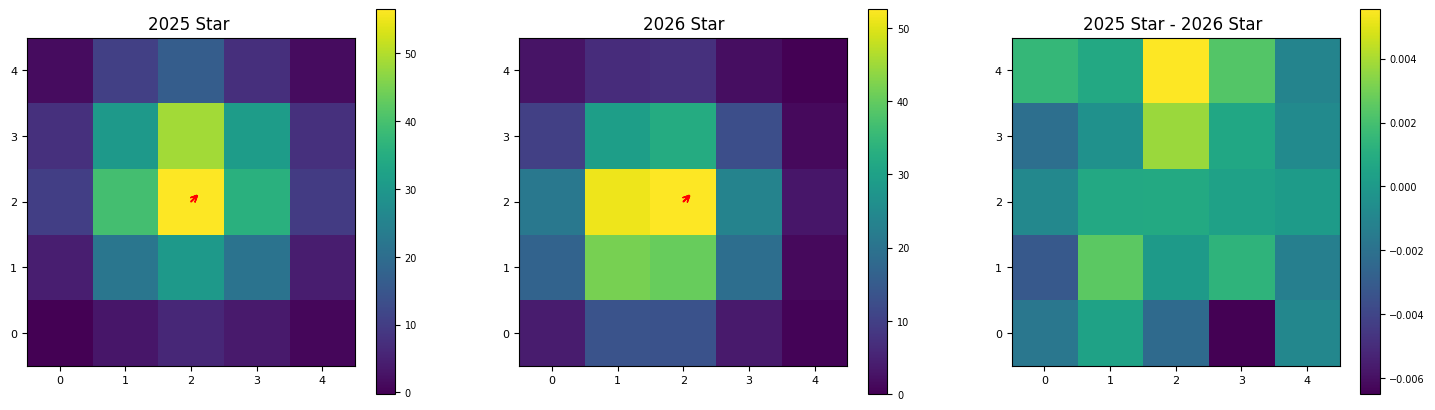

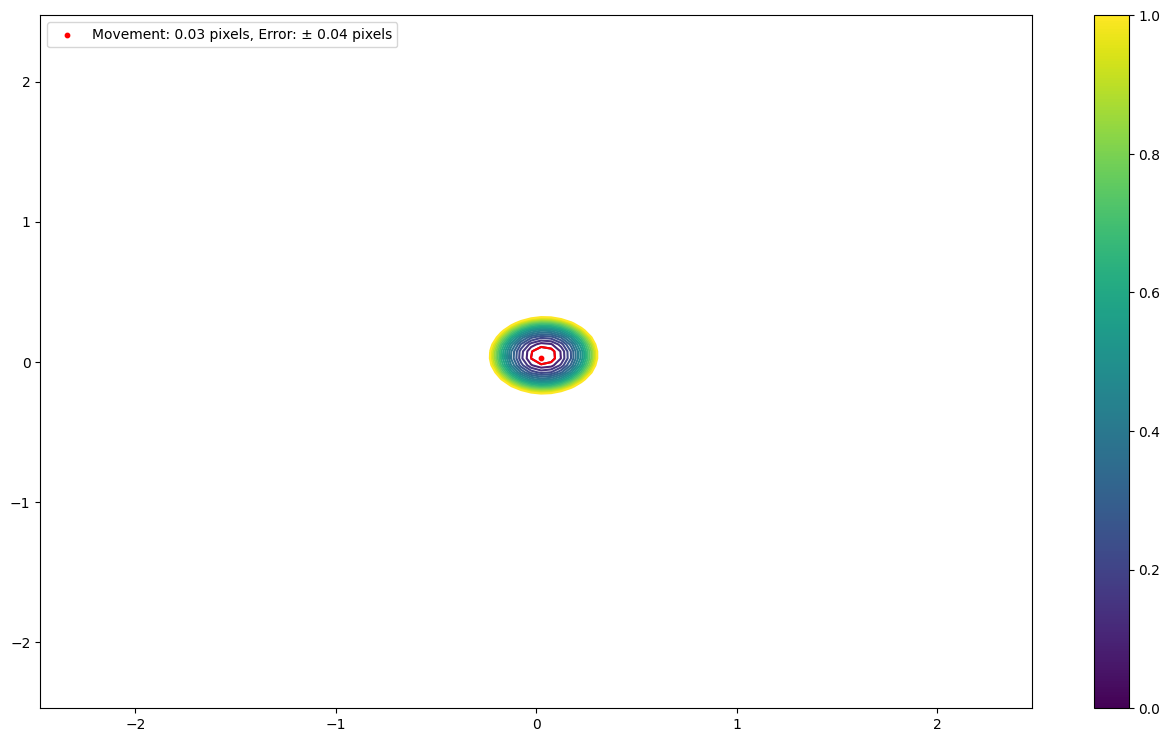

In [32]:
#4
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [1965, round(1965 - x_offset) -1]
cy_chi = [1054, round(1054 - y_offset) +1]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  2.2606895 , X shift =  -0.016513319226652362 , Y shift =  -0.023517257367456024
Error ± 0.02045983366576966
x error ± 0.0 y error ± 0.025000000000000022
angle = 144.92428349275434
angle error ± 28.6449358226933


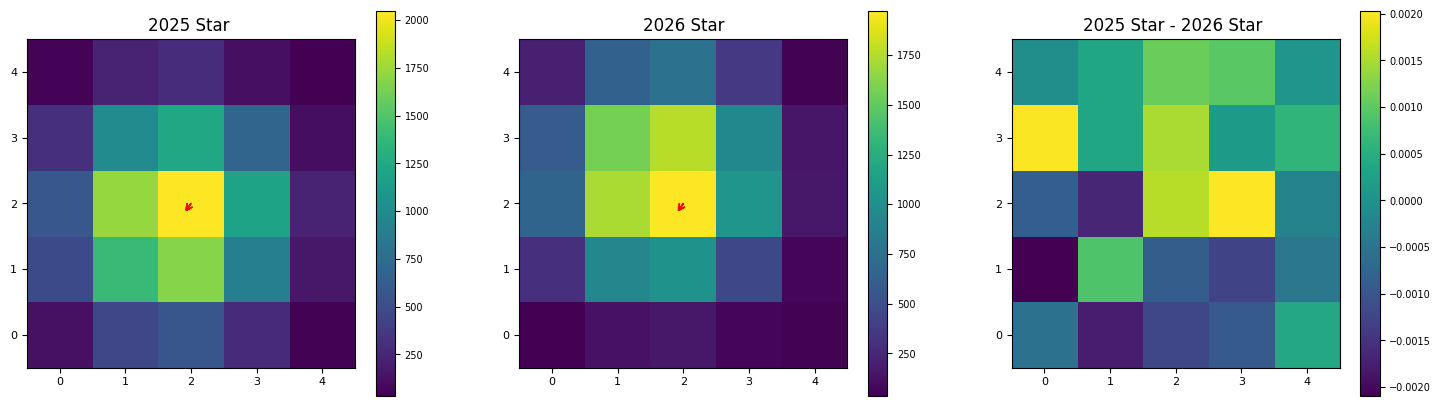

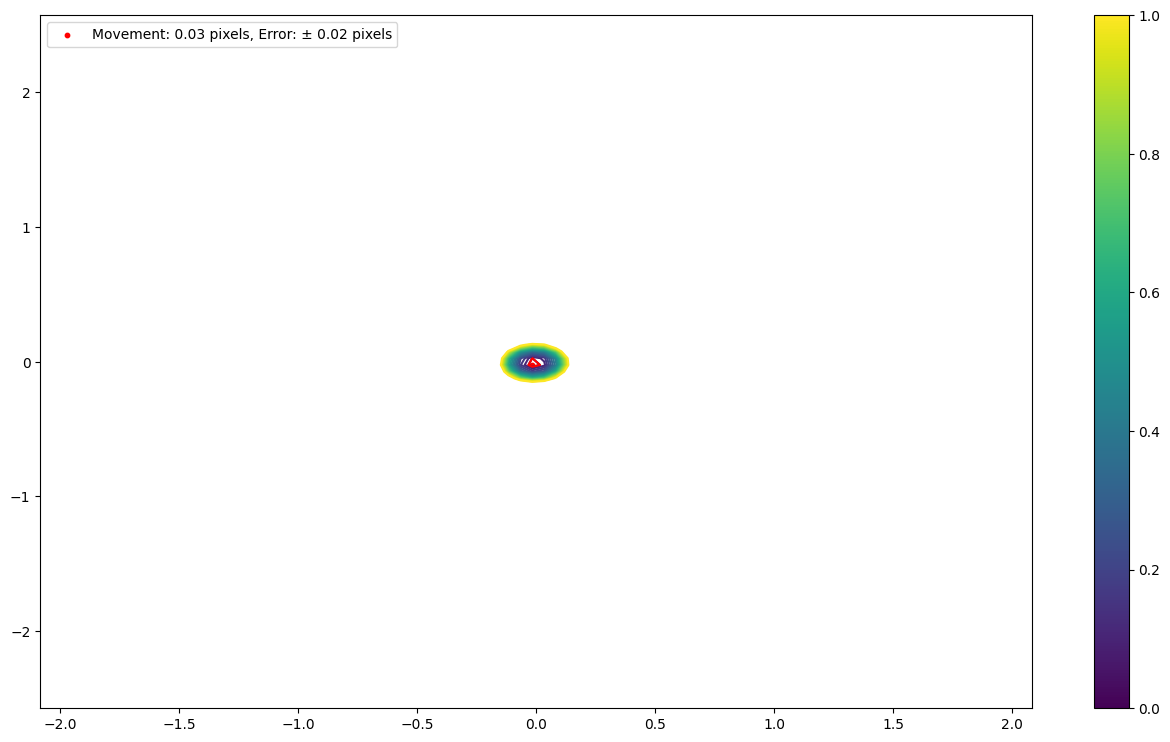

In [33]:
#5
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [1777, round(1777 - x_offset) -1]
cy_chi = [966, round(966 - y_offset)]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  27.320272 , X shift =  -0.020818113229603308 , Y shift =  -0.010094562540365337
Error ± 0.05563168578892478
x error ± 0.04999999999999999 y error ± 0.07499999999999998
angle = 115.86843333692343
angle error ± 175.6367580476921


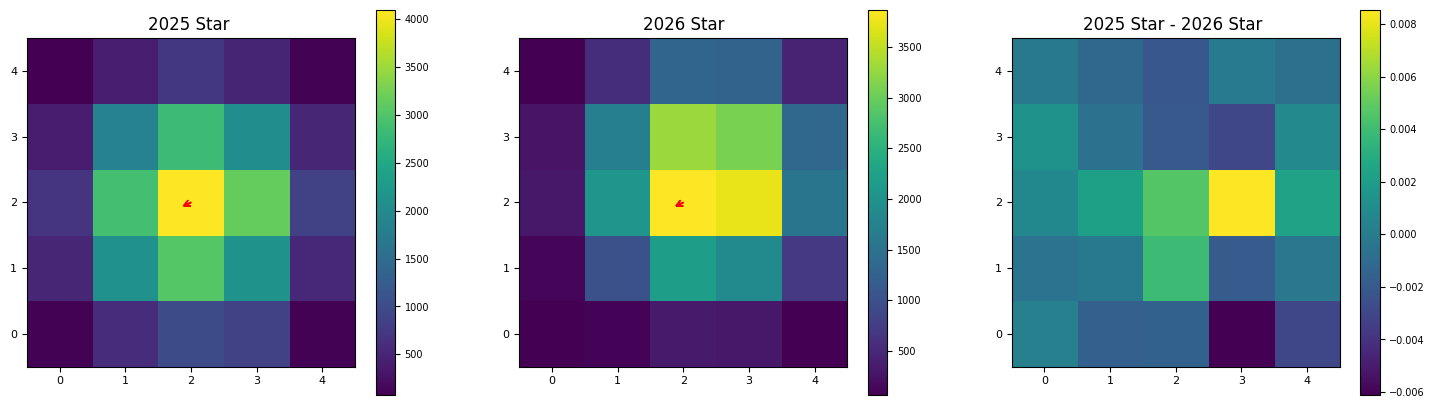

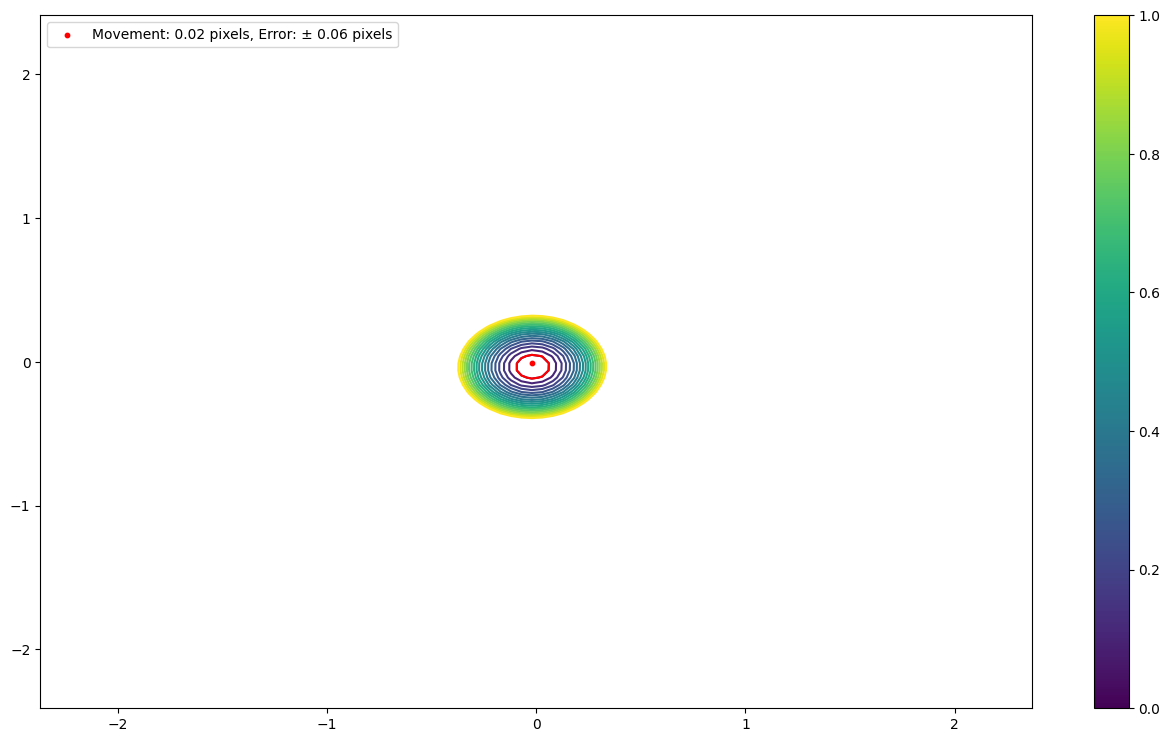

In [34]:
#6
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [673, round(673 - x_offset)+1]
cy_chi = [778, round(778 - y_offset)]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  15.5480175 , X shift =  0.025245331531567716 , Y shift =  -0.004736816389362242
Error ± 0.07500000000000001
x error ± 0.07500000000000001 y error ± 0.07499999999999998
angle = -100.62692696119169
angle error ± 167.29752835686438


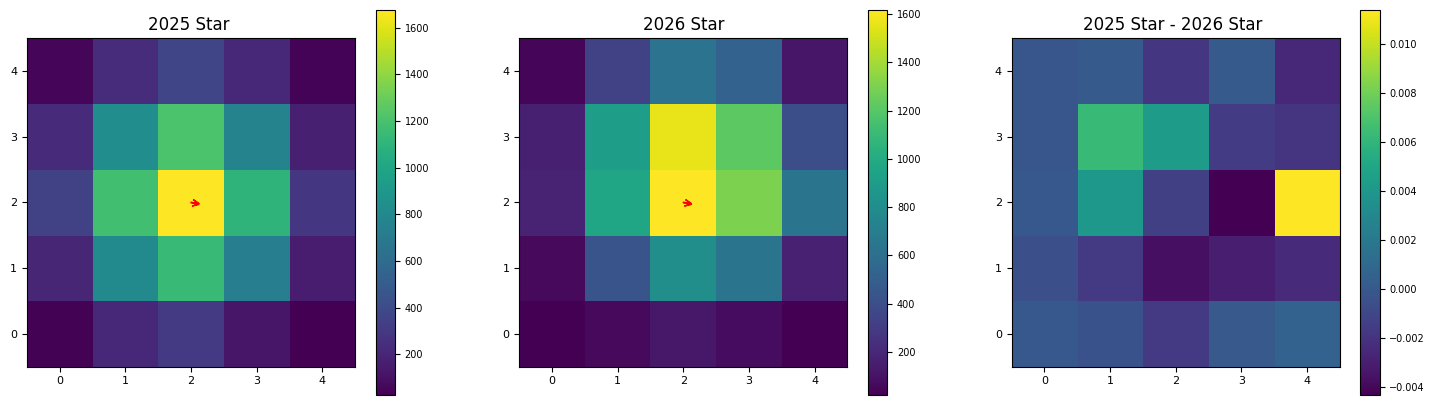

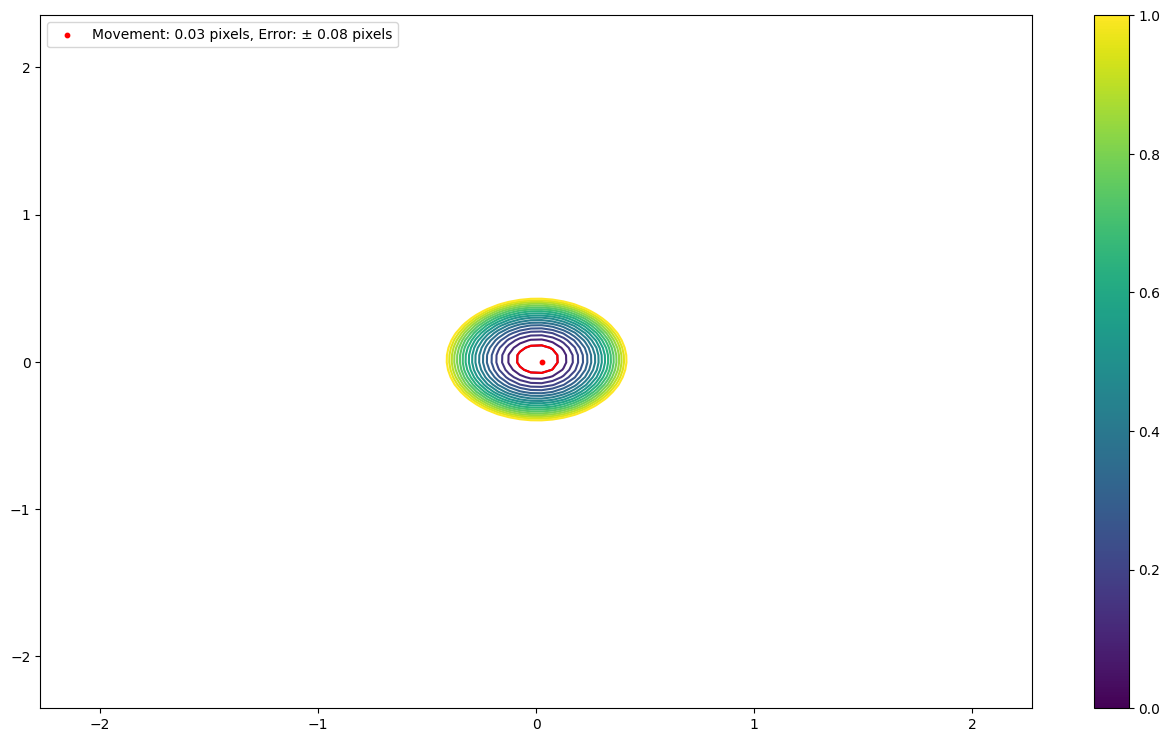

In [35]:
#7
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [1161, round(1161 - x_offset) ]
cy_chi = [874, round(874 - y_offset)]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  80.630875 , X shift =  0.017226787161877158 , Y shift =  -0.011103743114250608
Error ± 0.07500000000000001
x error ± 0.07500000000000001 y error ± 0.07500000000000001
angle = -122.80431521328501
angle error ± 209.6672783686663


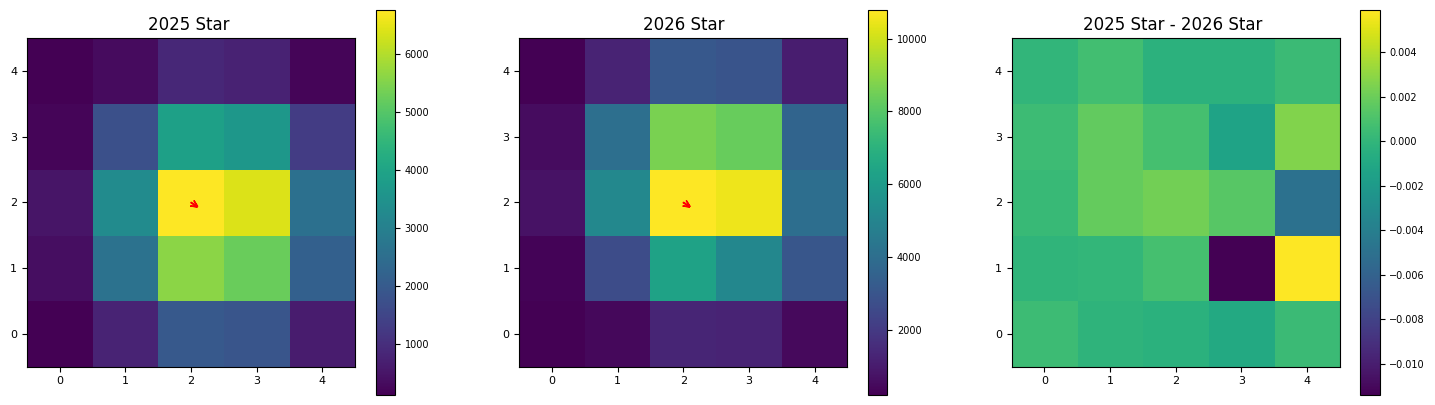

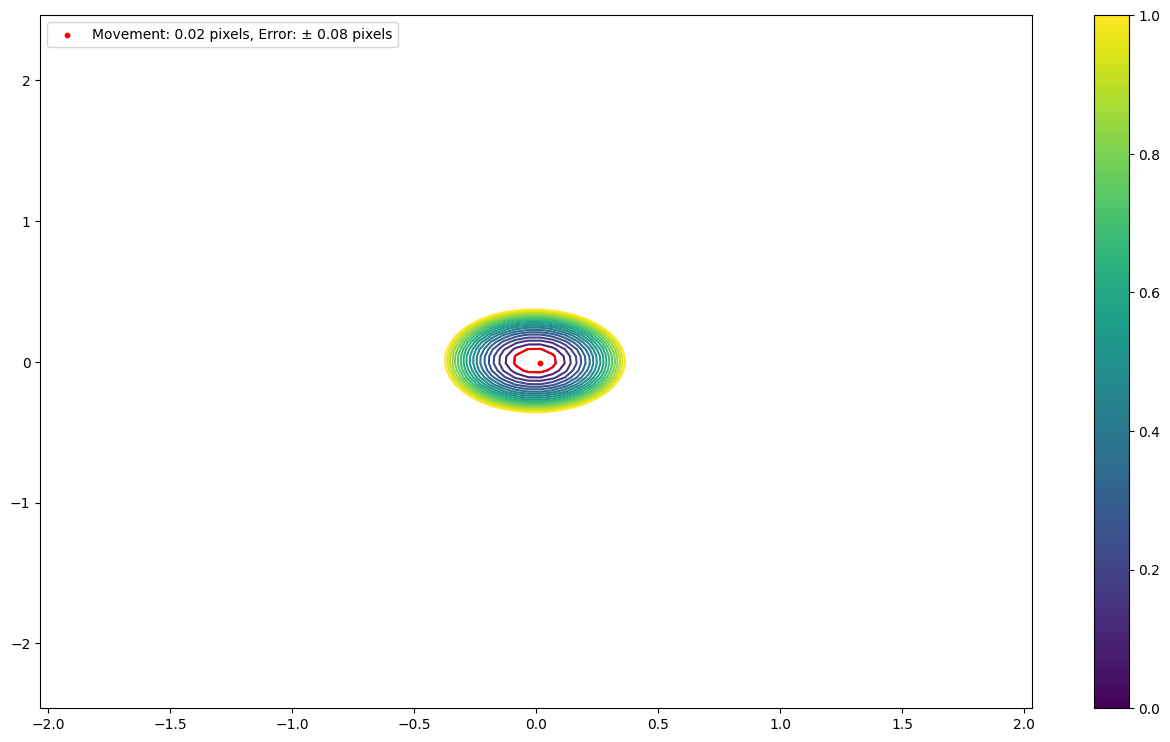

In [36]:
#8
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [41, round(41 - x_offset) +3]
cy_chi = [430, round(430 - y_offset)+1]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  4.492017 , X shift =  -0.014824863583447728 , Y shift =  0.01876995085004296
Error ± 0.025000000000000012
x error ± 0.025 y error ± 0.025000000000000022
angle = 38.30234917364801
angle error ± 59.886834875056266


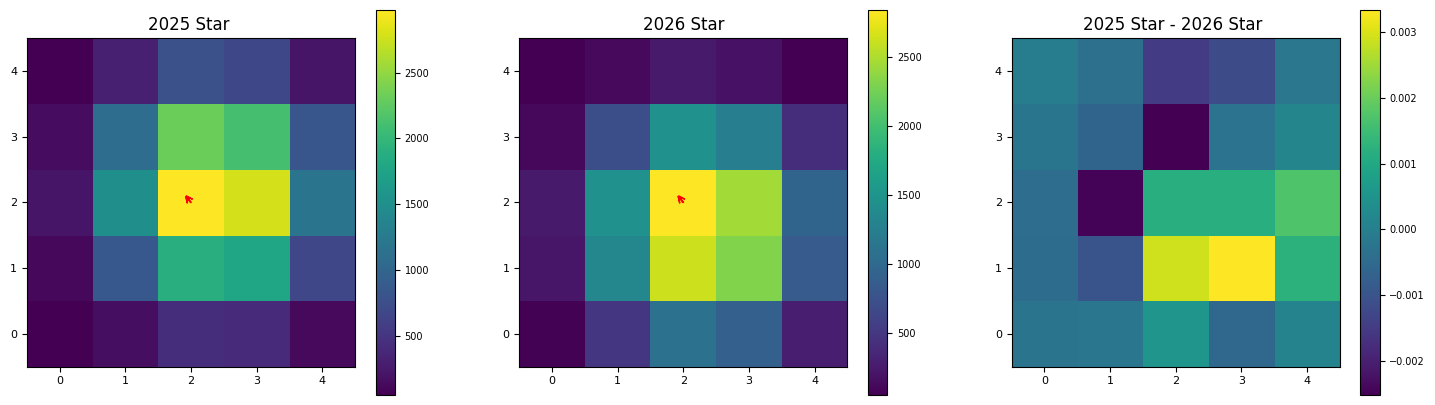

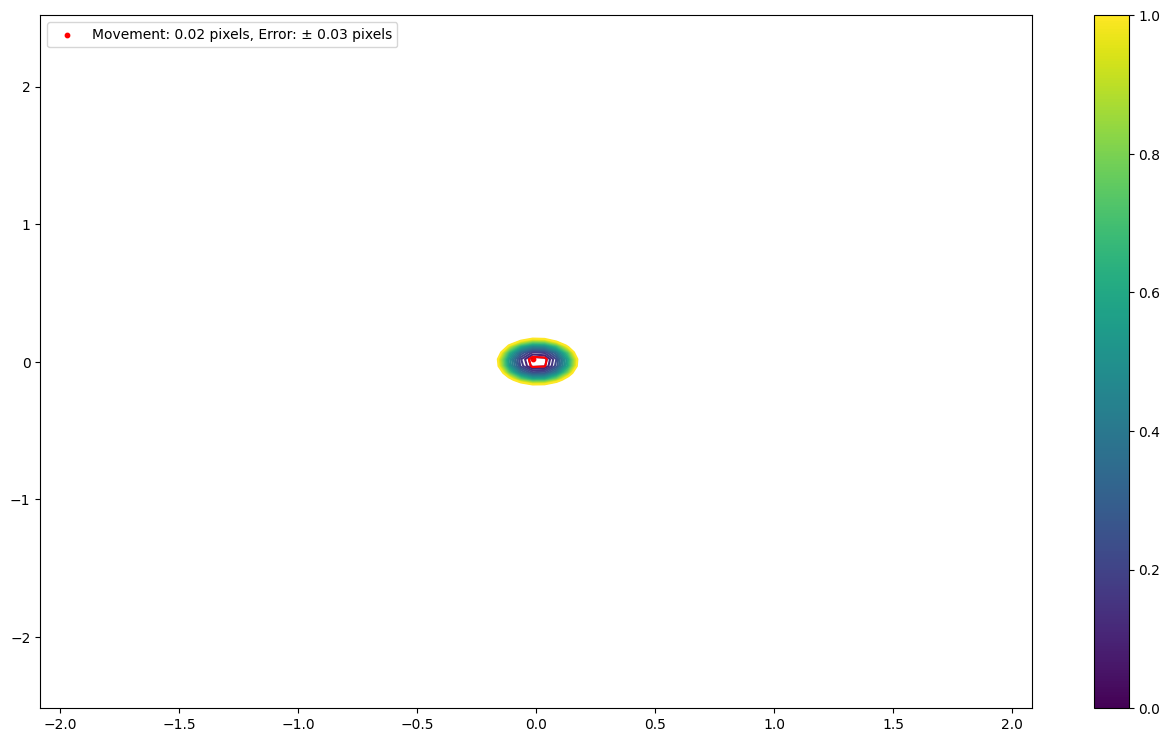

In [37]:
#9
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [88, round(88 - x_offset) +3]
cy_chi = [420, round(420 - y_offset)+2]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  0.46592543 , X shift =  0.053962478593672314 , Y shift =  -0.04205089496997516
Error ± 0.06066863932047087
x error ± 0.050000000000000044 y error ± 0.07500000000000001
angle = -127.92792254267665
angle error ± 55.83308886789819


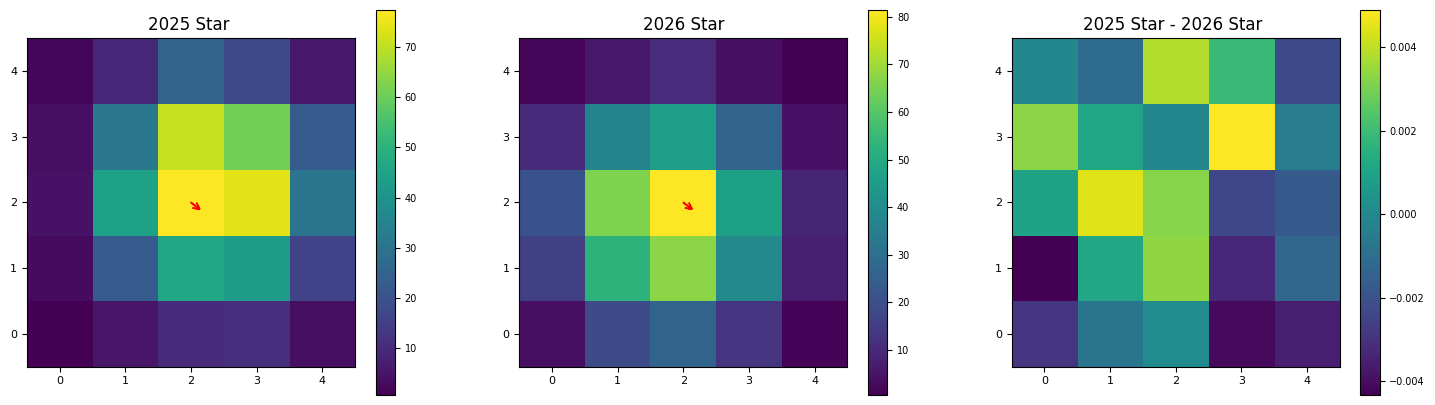

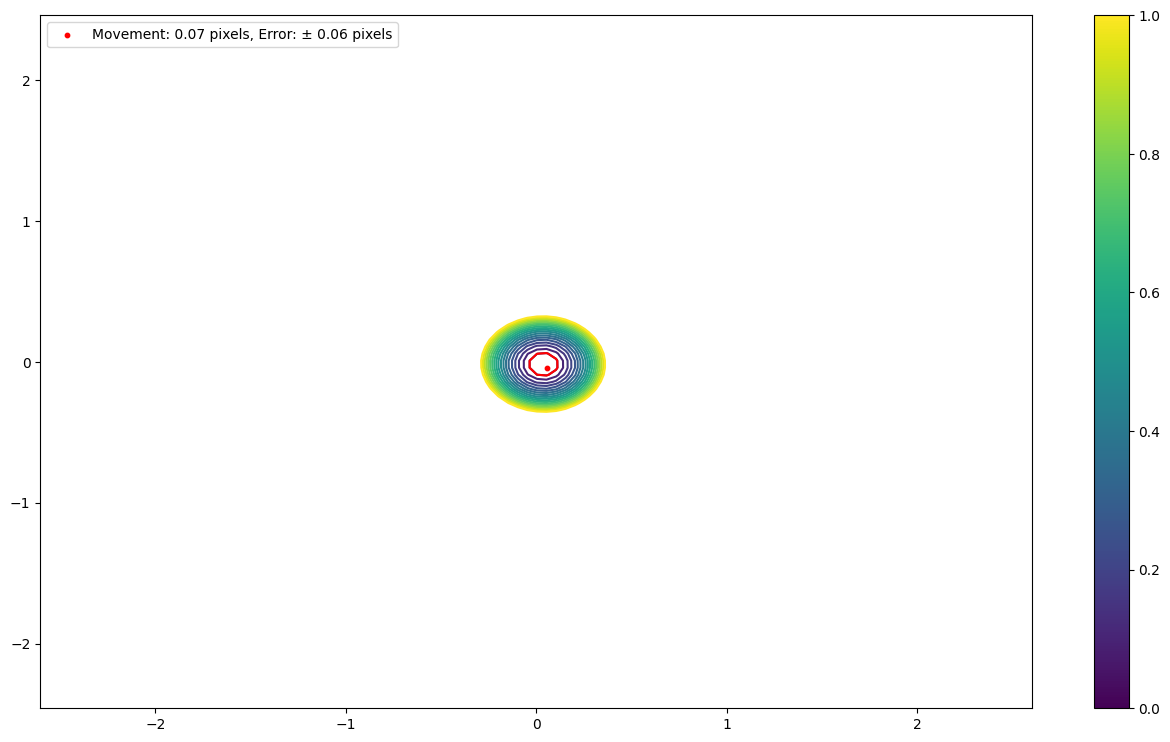

In [38]:
#10
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [314, round(314 - x_offset) +3]
cy_chi = [403, round(403 - y_offset)+2]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  1.302783 , X shift =  0.005046309889581838 , Y shift =  -0.11263596125597813
Error ± 0.07500000000000001
x error ± 0.07500000000000001 y error ± 0.07500000000000001
angle = -177.43475318098183
angle error ± 38.112847917879584


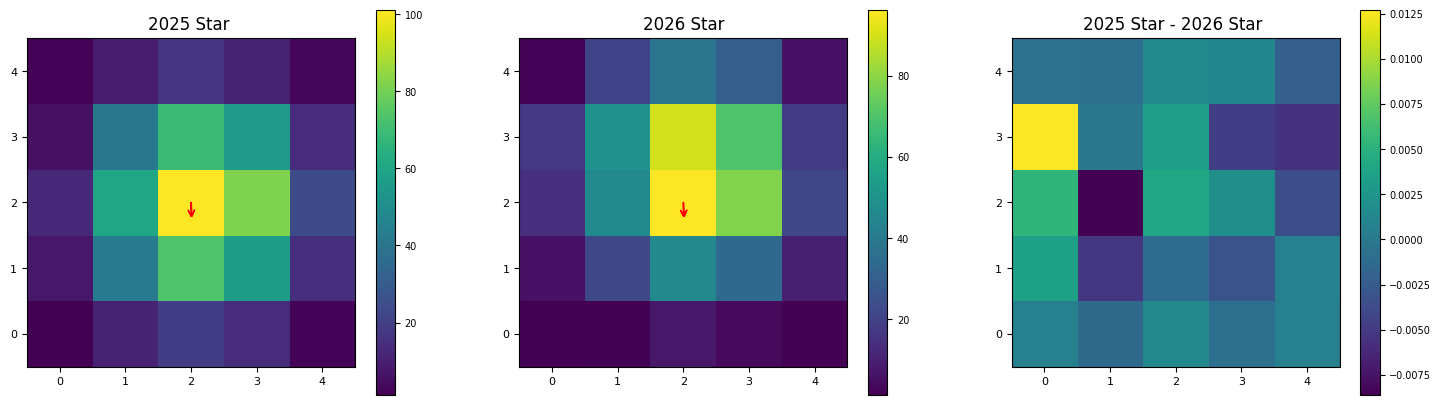

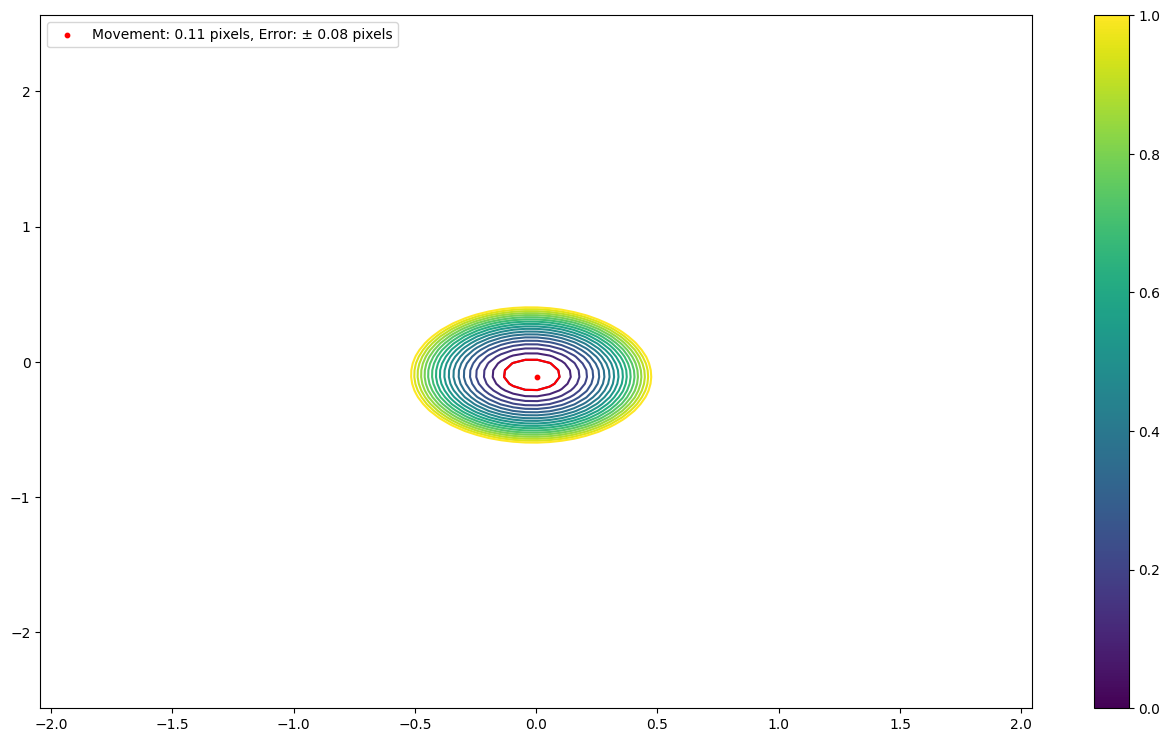

In [39]:
#11
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [471, round(471 - x_offset)+2]
cy_chi = [404, round(404 - y_offset)+1]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  0.9335403 , X shift =  -0.011184977583008016 , Y shift =  -0.00481456781639622
Error ± 0.0
x error ± 0.0 y error ± 0.0
angle = 113.28943598518053
angle error ± 0.0


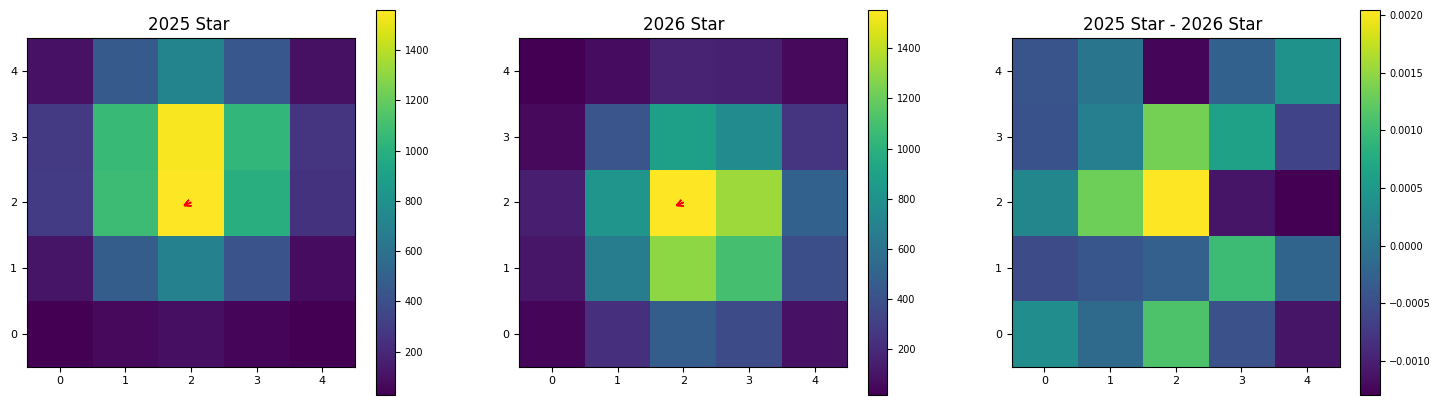

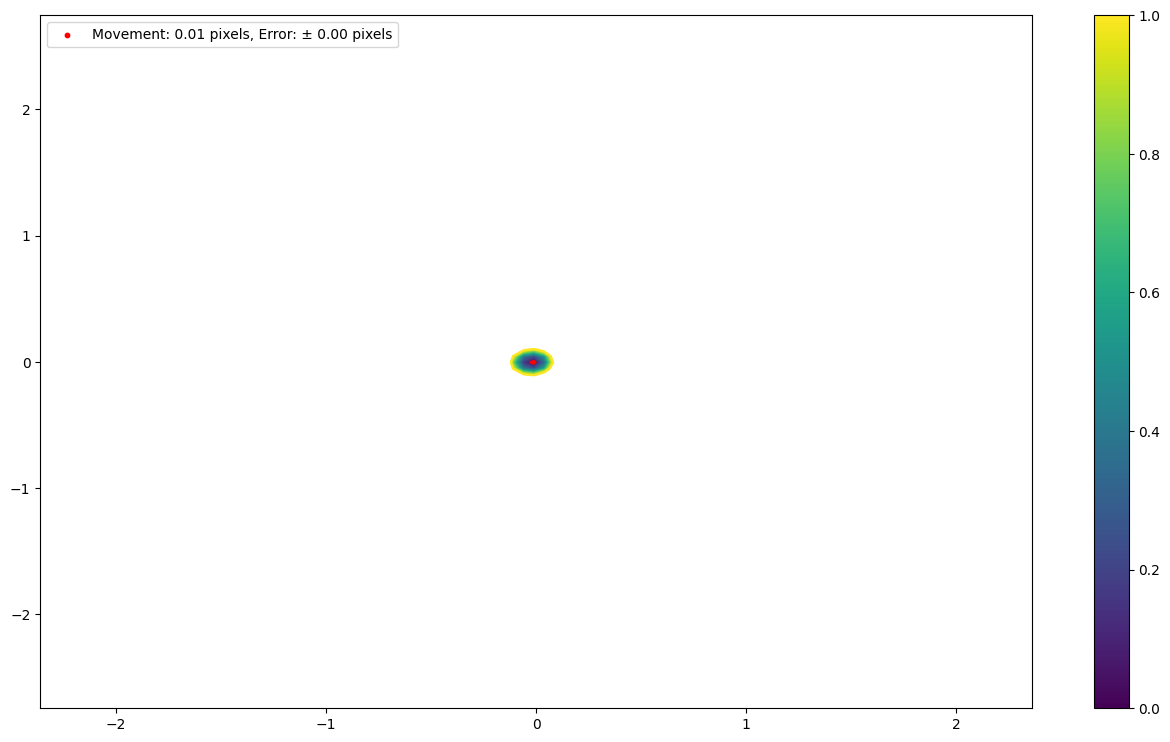

In [40]:
#12
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [2001, round(2001 - x_offset)-2]
cy_chi = [481, round(481 - y_offset)+3]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

In [41]:
# #13
# plt.rcParams['figure.max_open_warning'] = 200
# #define the x, y position of the knot
# cx_chi = [433, round(433 - x_offset)]
# cy_chi = [96, round(96 - y_offset)]
# #define the size of the image
# size_chi = [2, 2]
# #how much bigger the median subtraction is from the image size
# median_factor = 2
# #sets how much each chi is offset by. should be kept small to increase how accurate it is 
# shift_amount = .05
# #sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
# width = 40
# height = 40
# direction = 1
# chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

In [42]:
# #14
# plt.rcParams['figure.max_open_warning'] = 200
# #define the x, y position of the knot
# cx_chi = [784, round(784 - x_offset)]
# cy_chi = [142, round(142 - y_offset)]
# #define the size of the image
# size_chi = [2, 2]
# #how much bigger the median subtraction is from the image size
# median_factor = 2
# #sets how much each chi is offset by. should be kept small to increase how accurate it is 
# shift_amount = .05
# #sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
# width = 40
# height = 40
# direction = 1
# chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

In [43]:
velocity_storage_x_dither_1_2 = velocity_storage_x
velocity_storage_y_dither_1_2 = velocity_storage_y
x_error_dither_1_2 = x_error
y_error_dither_1_2 = y_error
error_bar_dither_1_2 = error_bar

# **Dither 1 25 to Dither 3 26**

In [44]:
hdu_1_A = fits.open((path_image_1 + 'nan_rm_jwst_2025_f444w_f470n_d1_frame_A.fits'))[1]
hdu_2_A = fits.open((path_image_2 + 'nan_rm_jwst_2026_f444w_f470n_d3_frame_A.fits'))[1]

In [45]:
x_offset = -397.9668713116581
y_offset  = 82.5674002280252

0.58599424 0.54569715 0.56548685


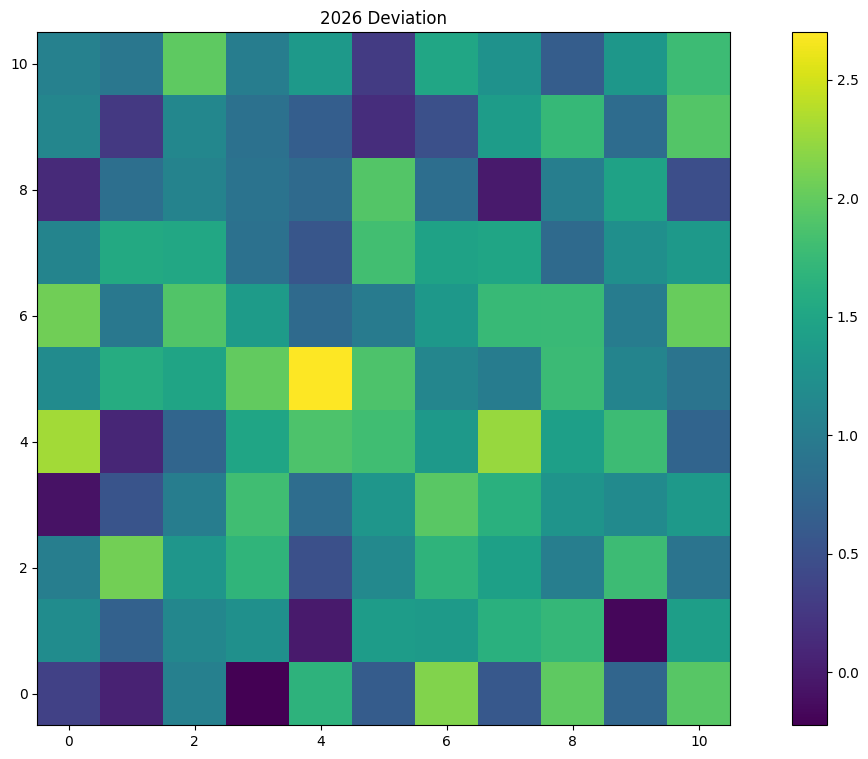

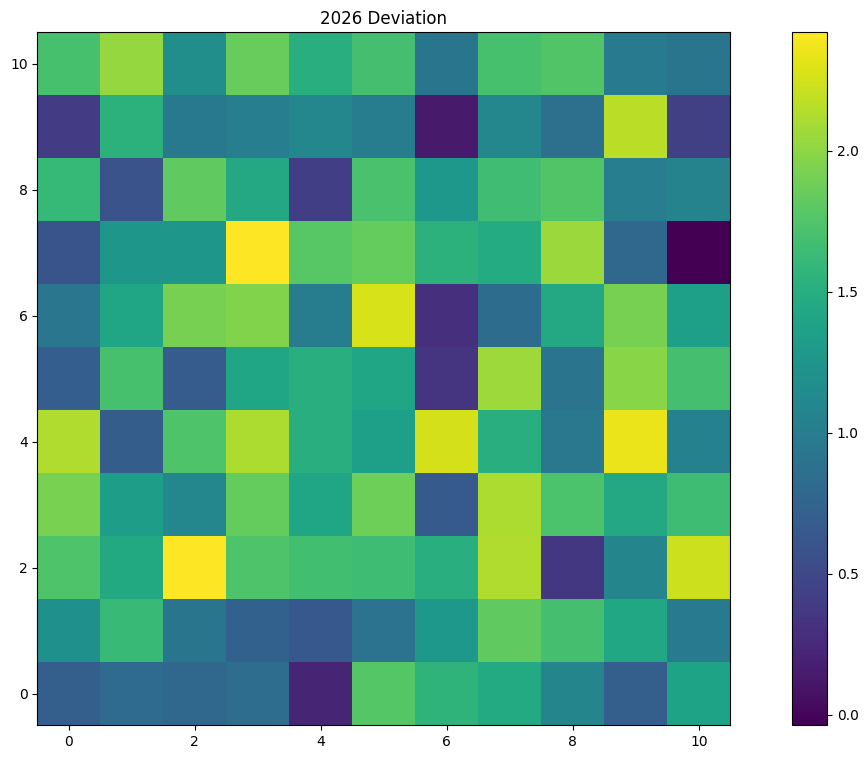

In [46]:
#define the x, y position of the knot
dev_x = [473, round(473 - x_offset)]
dev_y = [1240, round(1240 - y_offset)]
#define the size of the image
size_dev = [5, 5]
i=0
#creates the first image
std_04 = hdu_1_A.data[dev_y[i]-size_dev[i]:dev_y[i]+size_dev[i]+1, dev_x[i]-size_dev[i]:dev_x[i]+size_dev[i]+1]
#this normalizes the data to elimnate the changes in brightness and reduces error
fig, ax = plt.subplots(1, 1, figsize=(16, 9))
plt.imshow(std_04, vmin=np.min(std_04), vmax=np.max(std_04), origin="lower")
plt.colorbar()
title_1 = "2026 Deviation"
ax.set_title(title_1)
std_17 = hdu_2_A.data[dev_y[i+1]-size_dev[i+1]:dev_y[i+1]+size_dev[i+1]+1, dev_x[i+1]-size_dev[i+1]:dev_x[i+1]+size_dev[i+1]+1]
#this normalizes the data to elimnate the changes in brightness and reduces error
fig, ax = plt.subplots(1, 1, figsize=(16, 9))
plt.imshow(std_17, vmin=np.min(std_17), vmax=np.max(std_17), origin="lower")
plt.colorbar()
title_2 = "2026 Deviation"
ax.set_title(title_2)
dev_04 = np.std(std_04)
dev_17 = np.std(std_17)
deviation = np.sqrt(dev_04*dev_17)
print (dev_04, dev_17, deviation)

In [47]:
#this is where the data is stored for processing graphs at the end of calculating all of the knots
velocity_storage_x = []
velocity_storage_y = []
x_error = []
y_error = []
error_bar = []

minimum chi squared value =  3.3868415 , X shift =  -1.9767090567141963 , Y shift =  -0.606167659581962
Error ± 0.023901433557226546
x error ± 0.025000000000000022 y error ± 0.0
angle = 107.04841849052393
angle error ± 0.20311302825745828


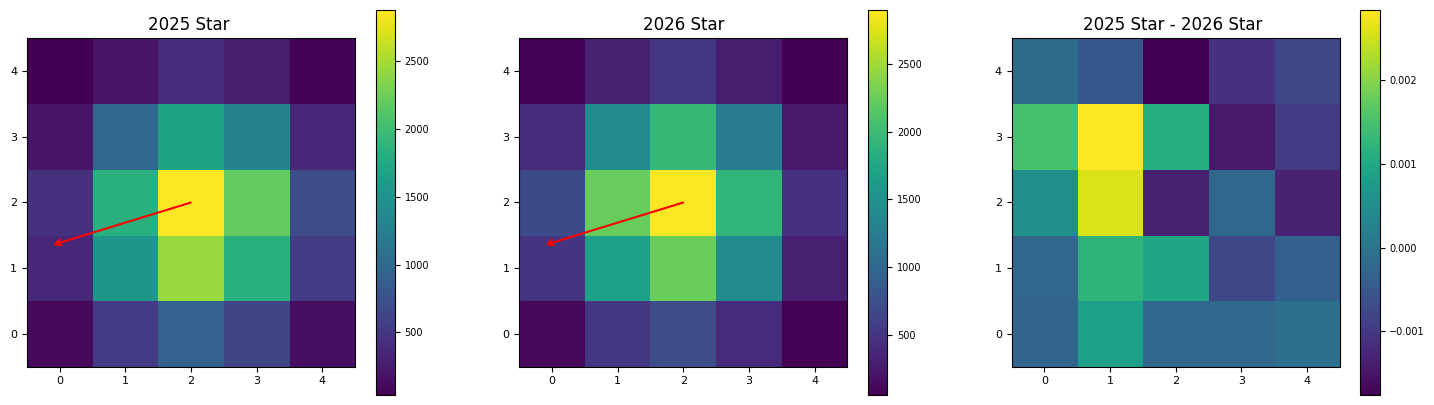

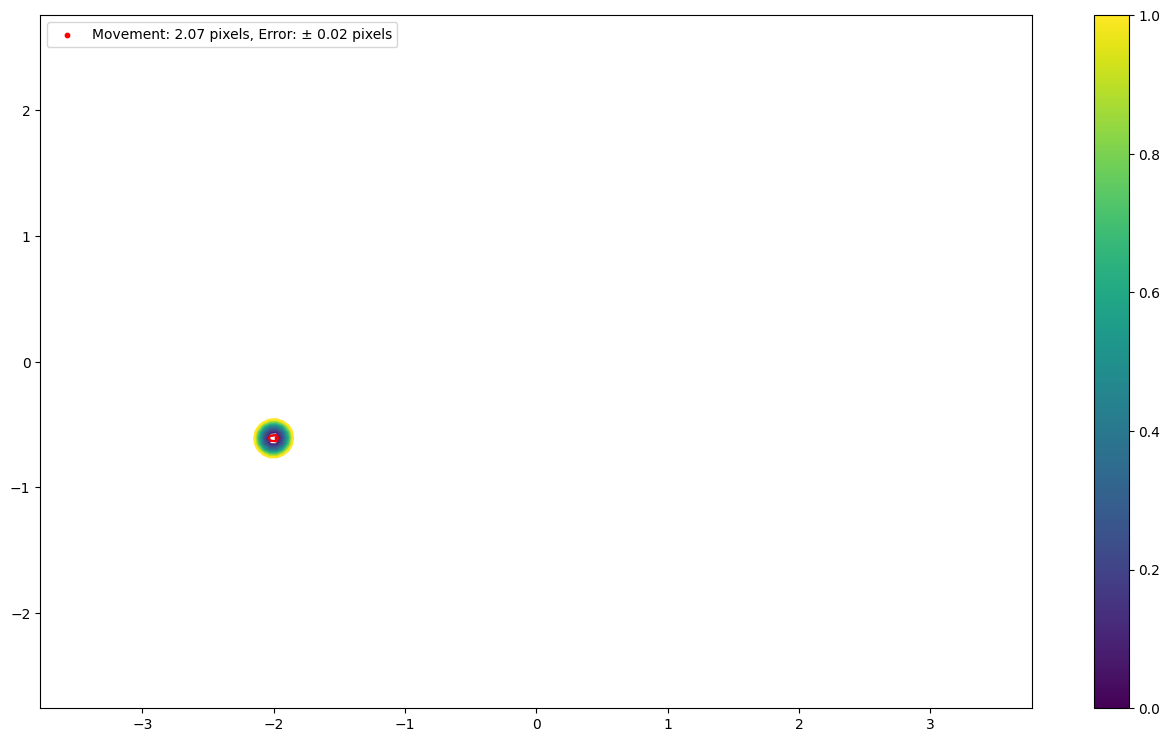

In [48]:
#1
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [177, round(177 - x_offset) +2]
cy_chi = [1910, round(1910 - y_offset)+1]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  2.6442666 , X shift =  0.0091947989857772 , Y shift =  -0.03681116161067732
Error ± 0.006058434707661915
x error ± 0.025 y error ± 0.0
angle = -165.9754639234574
angle error ± 36.62676239467947


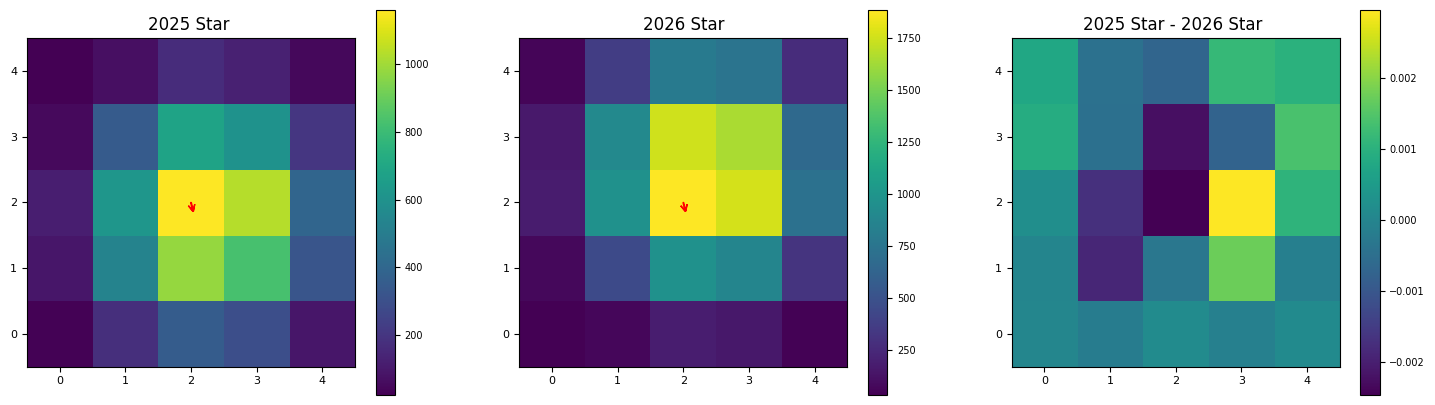

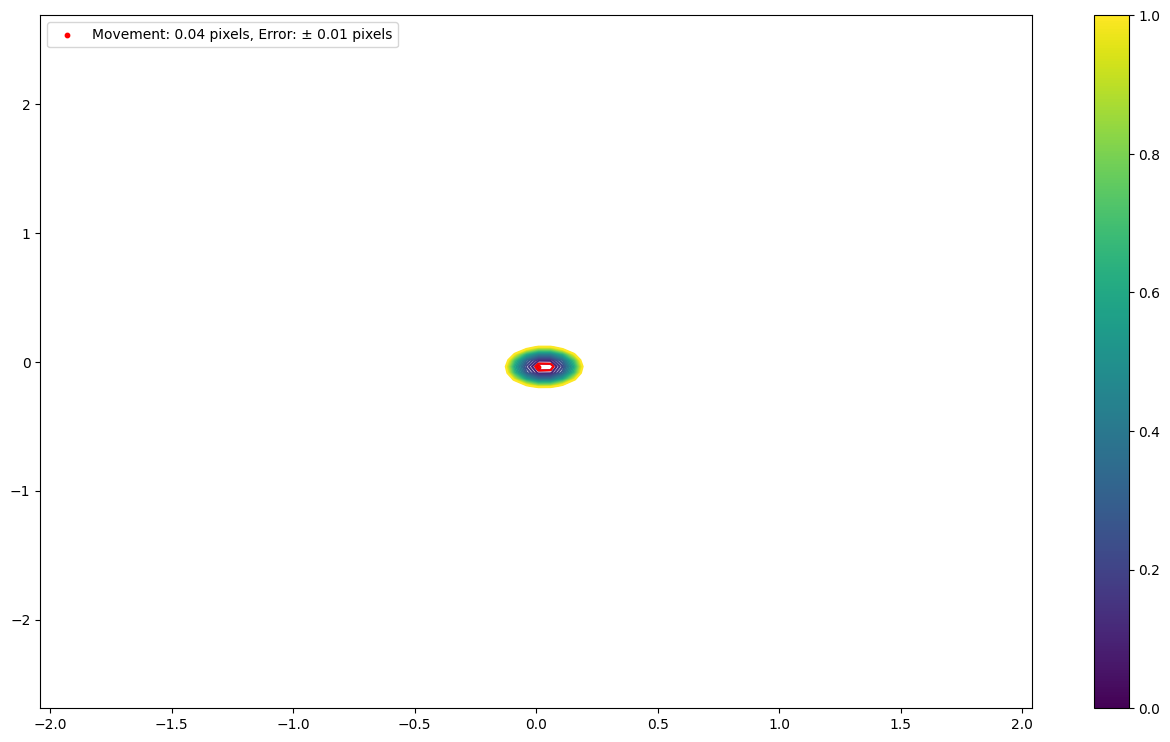

In [49]:
#2
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [1311, round(1311 - x_offset)+1]
cy_chi = [1752, round(1752 - y_offset)-4]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

In [50]:
# #3
# plt.rcParams['figure.max_open_warning'] = 200
# #define the x, y position of the knot
# cx_chi = [1688, round(1688 - x_offset) ]
# cy_chi = [1090, round(1090 - y_offset) ]
# #define the size of the image
# size_chi = [2, 2]
# #how much bigger the median subtraction is from the image size
# median_factor = 2
# #sets how much each chi is offset by. should be kept small to increase how accurate it is 
# shift_amount = .05
# #sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
# width = 40
# height = 40
# direction = 1
# chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

In [51]:
# #4
# plt.rcParams['figure.max_open_warning'] = 200
# #define the x, y position of the knot
# cx_chi = [1965, round(1965 - x_offset) ]
# cy_chi = [1054, round(1054 - y_offset) ]
# #define the size of the image
# size_chi = [2, 2]
# #how much bigger the median subtraction is from the image size
# median_factor = 2
# #sets how much each chi is offset by. should be kept small to increase how accurate it is 
# shift_amount = .05
# #sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
# width = 40
# height = 40
# direction = 1
# chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

In [52]:
# #5
# plt.rcParams['figure.max_open_warning'] = 200
# #define the x, y position of the knot
# cx_chi = [1777, round(1777 - x_offset) ]
# cy_chi = [966, round(966 - y_offset)]
# #define the size of the image
# size_chi = [2, 2]
# #how much bigger the median subtraction is from the image size
# median_factor = 2
# #sets how much each chi is offset by. should be kept small to increase how accurate it is 
# shift_amount = .05
# #sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
# width = 40
# height = 40
# direction = 1
# chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  22.111177 , X shift =  -0.02952542826567424 , Y shift =  -0.0578739736383852
Error ± 0.049999999999999996
x error ± 0.05 y error ± 0.04999999999999999
angle = 152.9707966861082
angle error ± 44.09378299804859


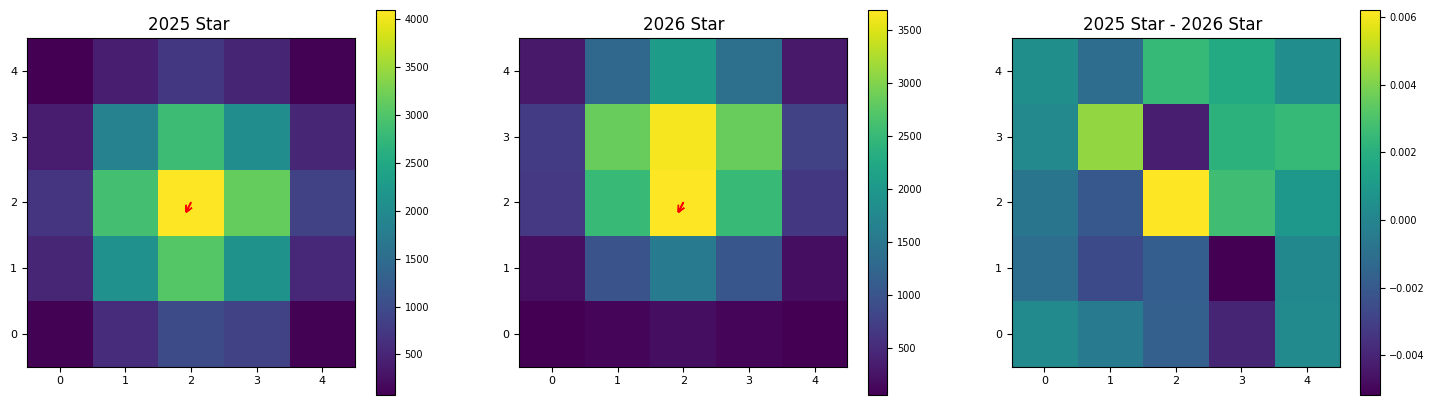

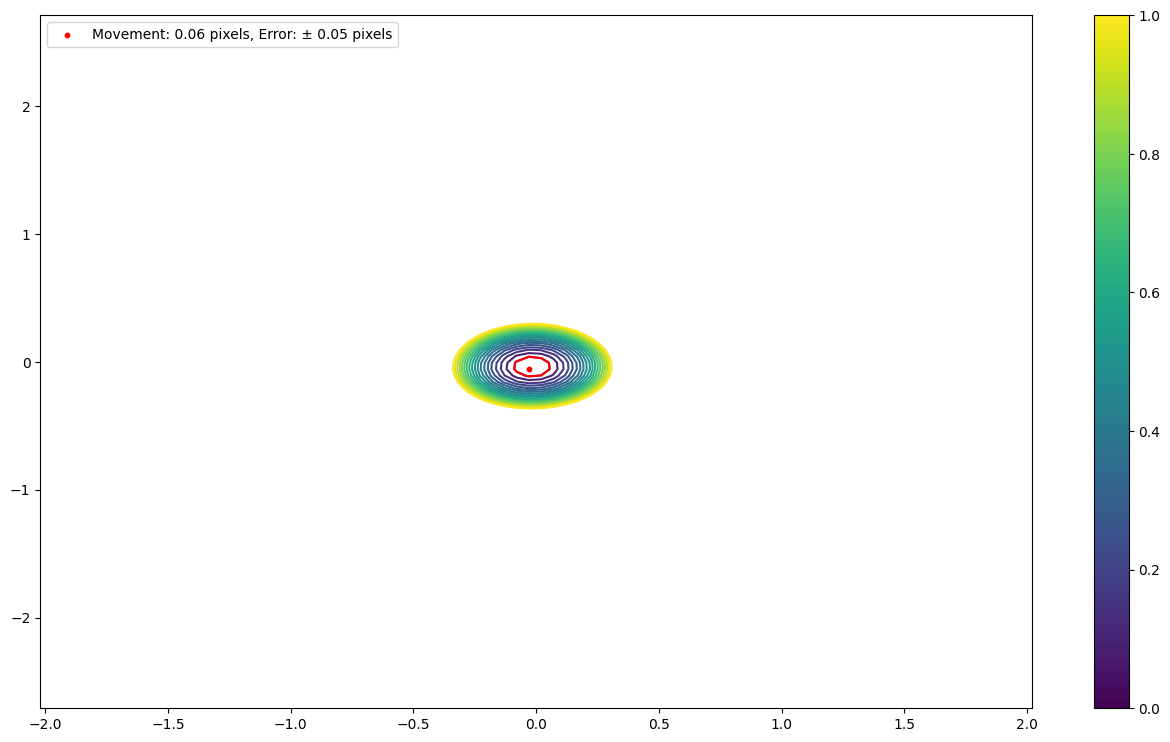

In [53]:
#6
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [673, round(673 - x_offset)-1]
cy_chi = [778, round(778 - y_offset)+1]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  6.180691 , X shift =  -0.01036264225388095 , Y shift =  0.03787546910195372
Error ± 0.027487812240893625
x error ± 0.05 y error ± 0.024999999999999994
angle = 15.301529021221018
angle error ± 71.02488971979106


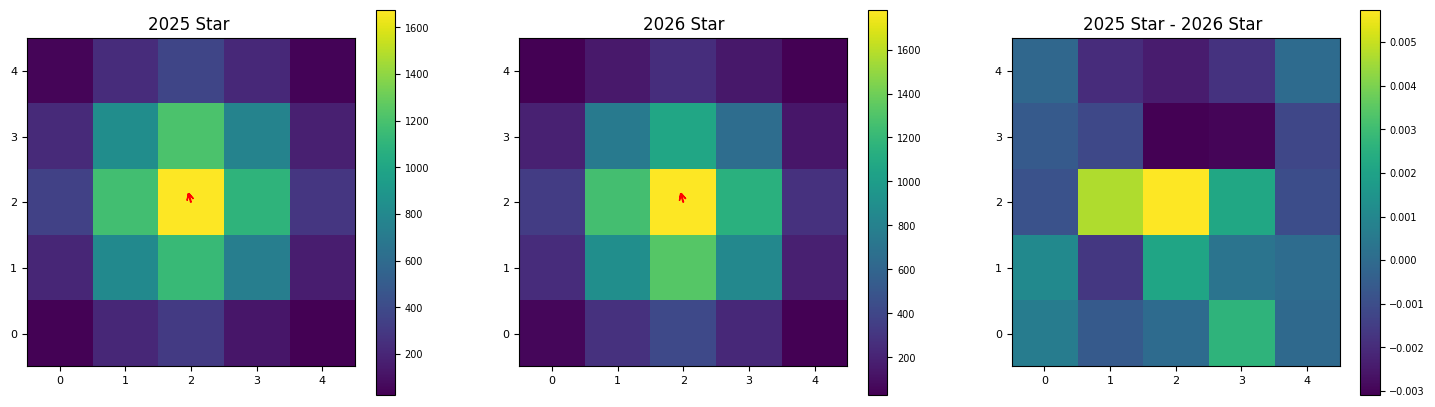

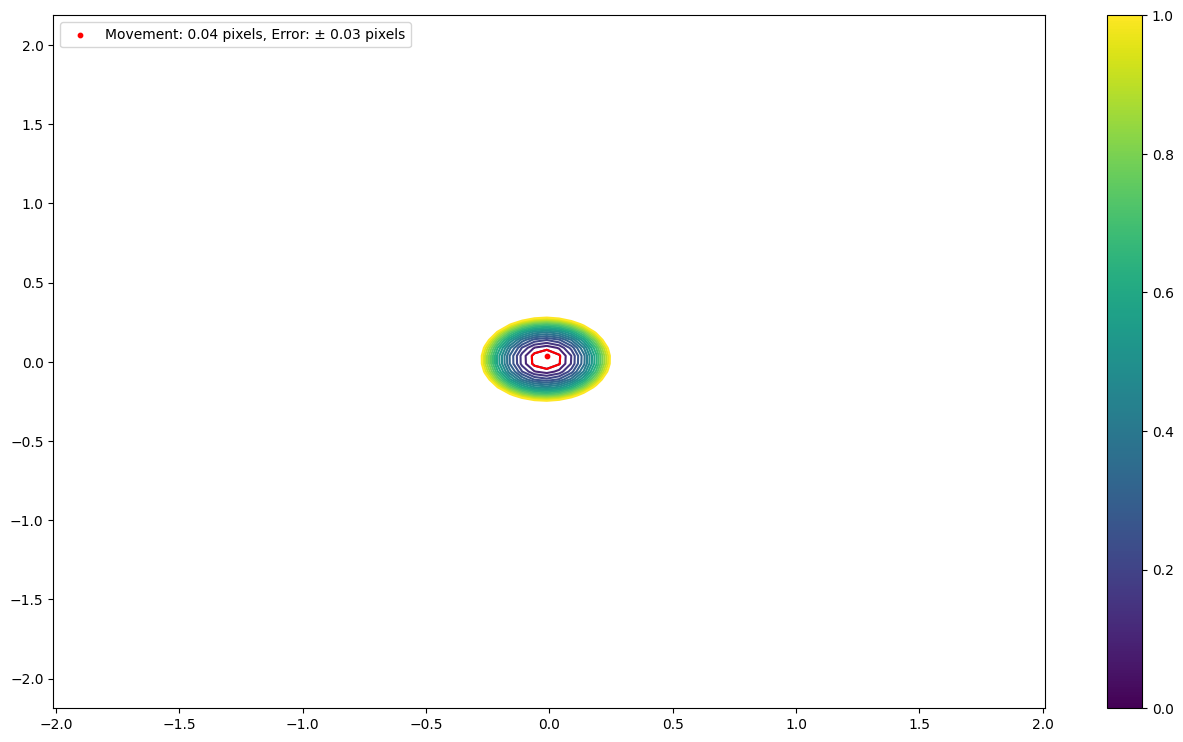

In [54]:
#7
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [1161, round(1161 - x_offset) -2]
cy_chi = [874, round(874 - y_offset)]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  33.10777 , X shift =  0.008192086922335307 , Y shift =  -0.029200529603900793
Error ± 0.024999999999999994
x error ± 0.024999999999999994 y error ± 0.024999999999999994
angle = -164.3287573138291
angle error ± 47.23026395814387


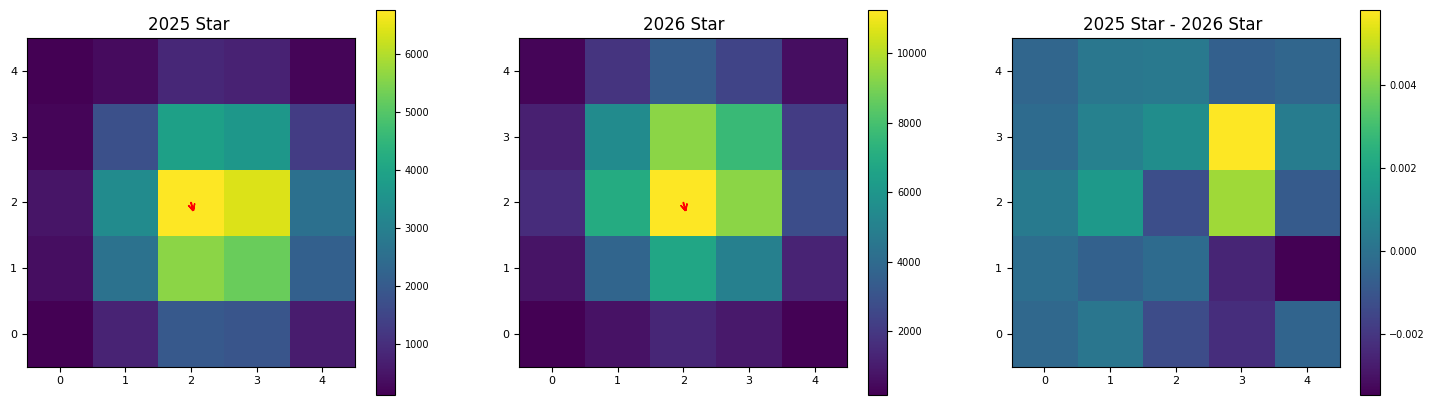

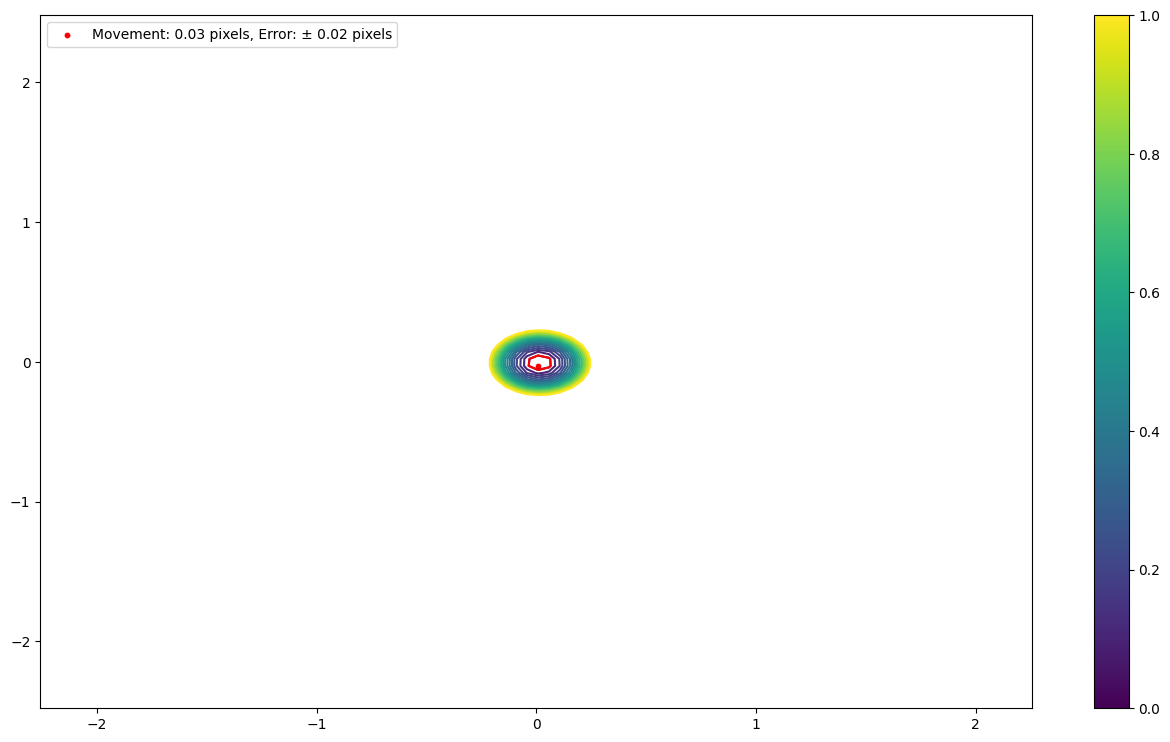

In [55]:
#8
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [41, round(41 - x_offset) -2]
cy_chi = [430, round(430 - y_offset)+4]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  7.4184976 , X shift =  -0.010590629176536526 , Y shift =  -0.010644599282892353
Error ± 0.024999999999999994
x error ± 0.024999999999999994 y error ± 0.024999999999999994
angle = 135.1456189963739
angle error ± 95.39361315593402


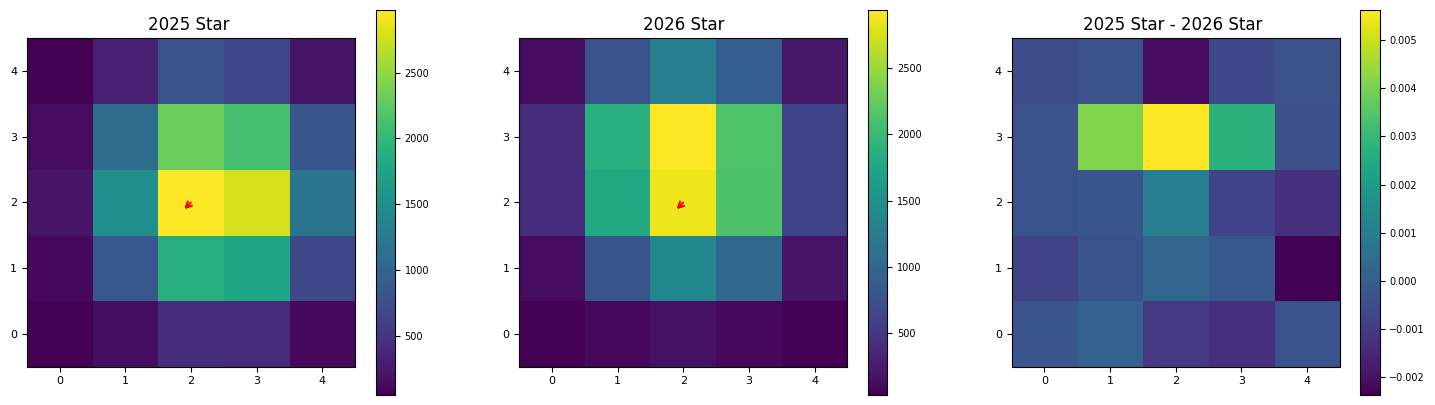

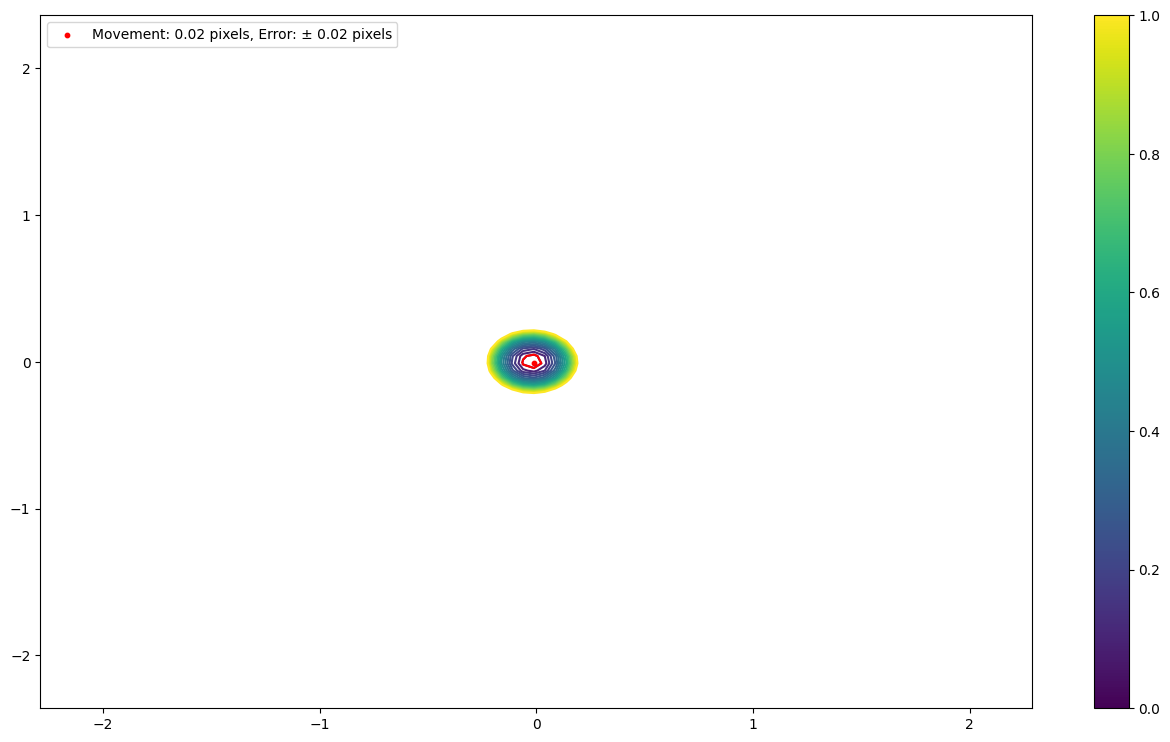

In [56]:
#9
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [88, round(88 - x_offset) -2]
cy_chi = [420, round(420 - y_offset)+4]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  0.66493285 , X shift =  0.0531925691551805 , Y shift =  -0.03457720410507936
Error ± 0.075
x error ± 0.07499999999999998 y error ± 0.07500000000000001
angle = -123.02540782160858
angle error ± 67.73282700815659


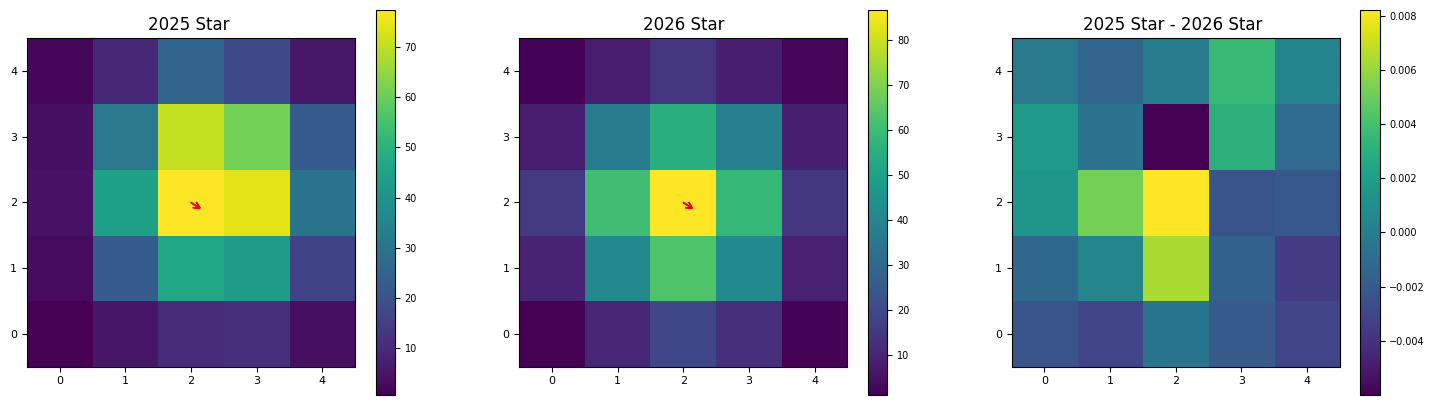

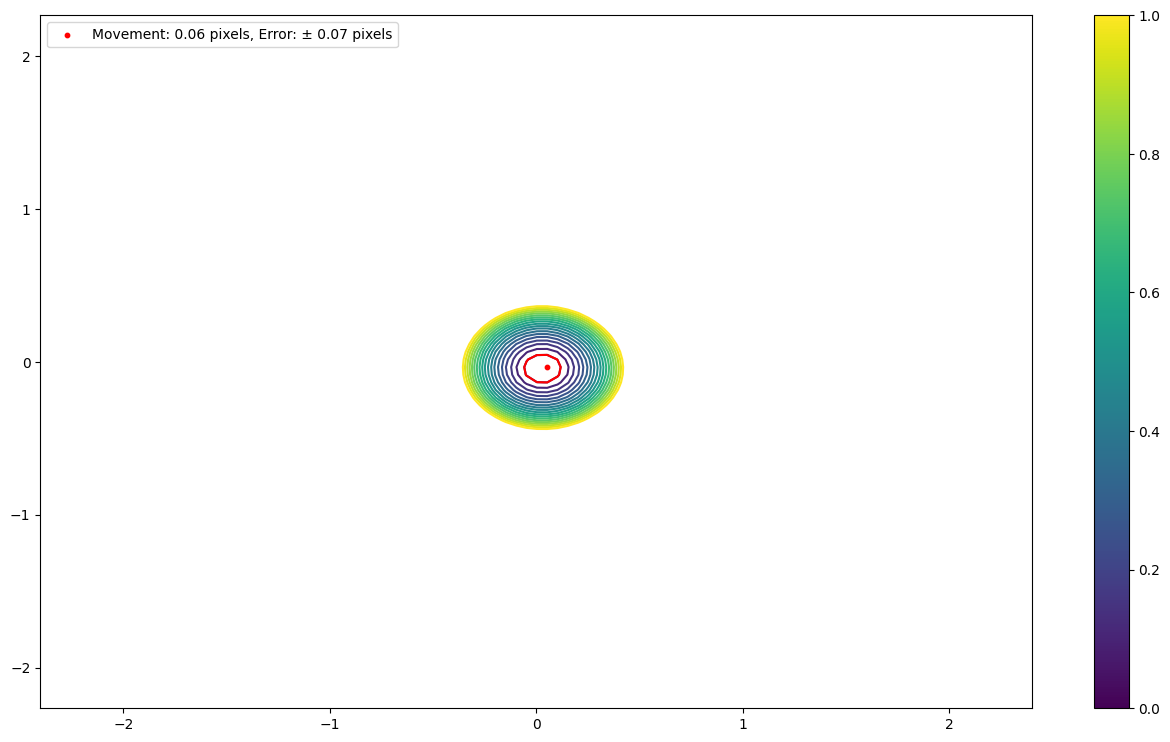

In [57]:
#10
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [314, round(314 - x_offset) -2]
cy_chi = [403, round(403 - y_offset)+4]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  0.64746225 , X shift =  -0.016334743416609898 , Y shift =  -0.08557997469837914
Error ± 0.04999999999999999
x error ± 0.050000000000000044 y error ± 0.04999999999999999
angle = 169.1938695673945
angle error ± 32.88138661172852


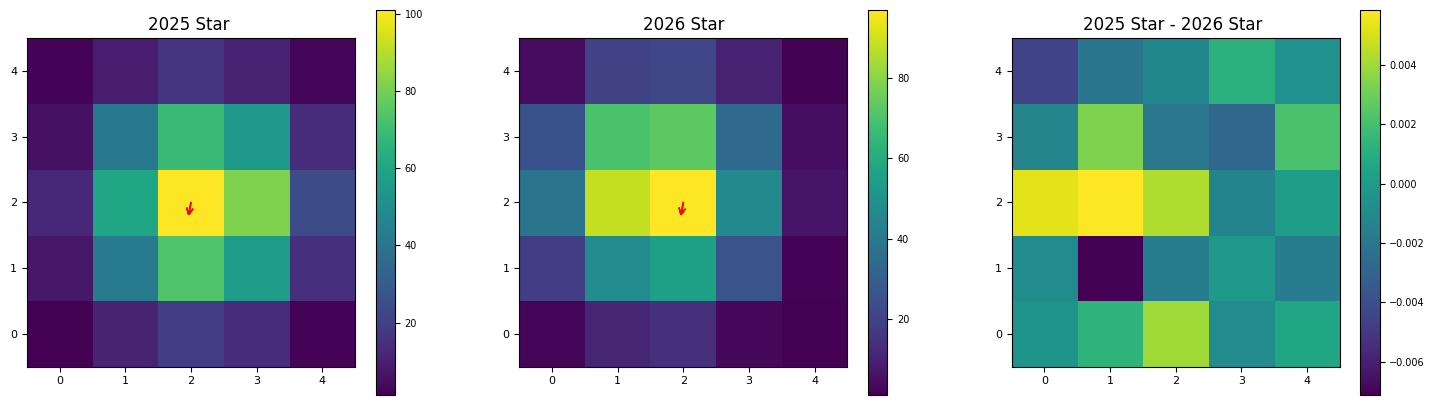

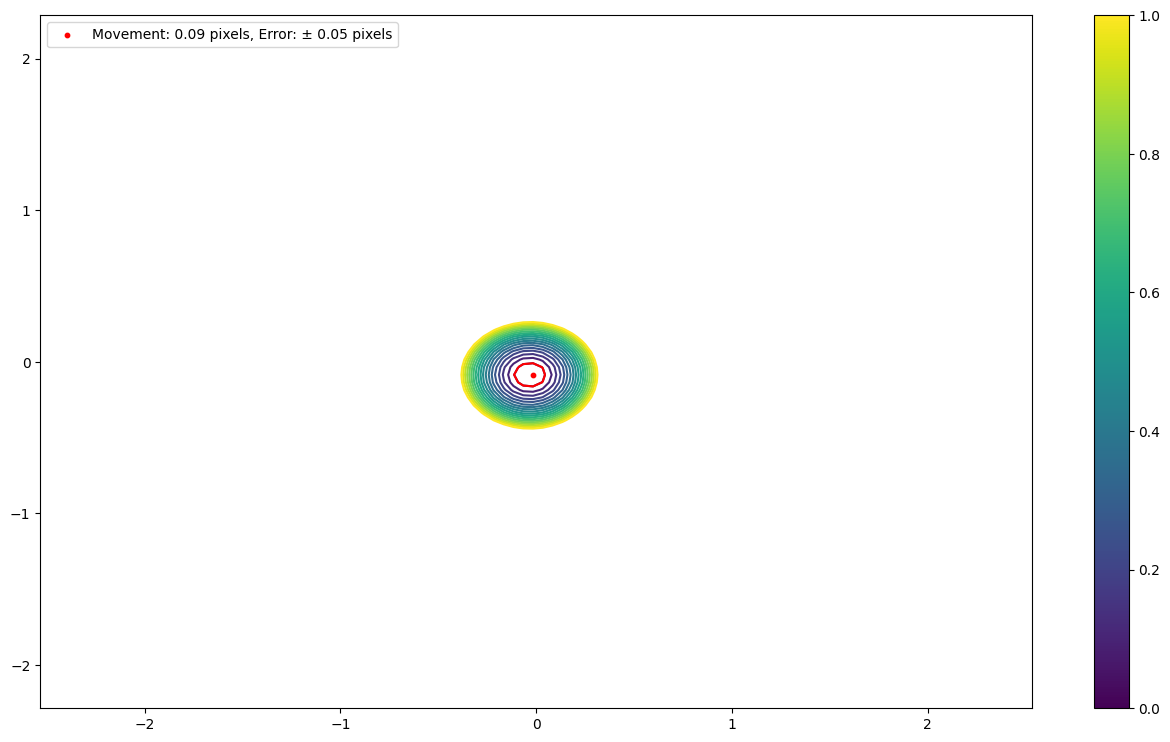

In [58]:
#11
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [471, round(471 - x_offset)-2]
cy_chi = [404, round(404 - y_offset)+3]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

In [59]:
# #12
# plt.rcParams['figure.max_open_warning'] = 200
# #define the x, y position of the knot
# cx_chi = [2001, round(2001 - x_offset)]
# cy_chi = [481, round(481 - y_offset)]
# #define the size of the image
# size_chi = [2, 2]
# #how much bigger the median subtraction is from the image size
# median_factor = 2
# #sets how much each chi is offset by. should be kept small to increase how accurate it is 
# shift_amount = .05
# #sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
# width = 40
# height = 40
# direction = 1
# chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  2.1051753 , X shift =  -0.015943021689986403 , Y shift =  0.013264975966163217
Error ± 0.01598975461791687
x error ± 0.0 y error ± 0.024999999999999994
angle = 50.238732609450295
angle error ± 53.09136896751467


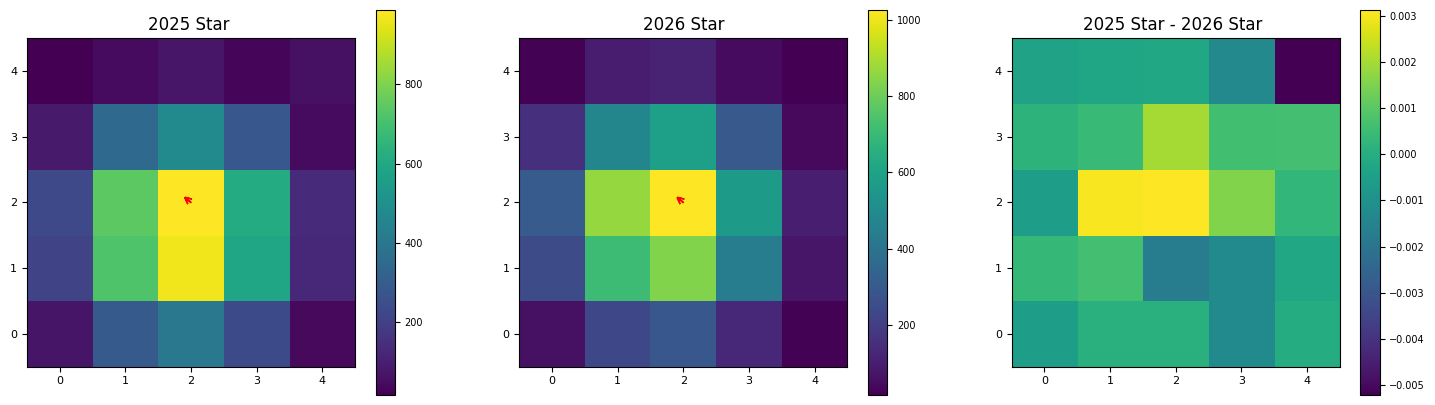

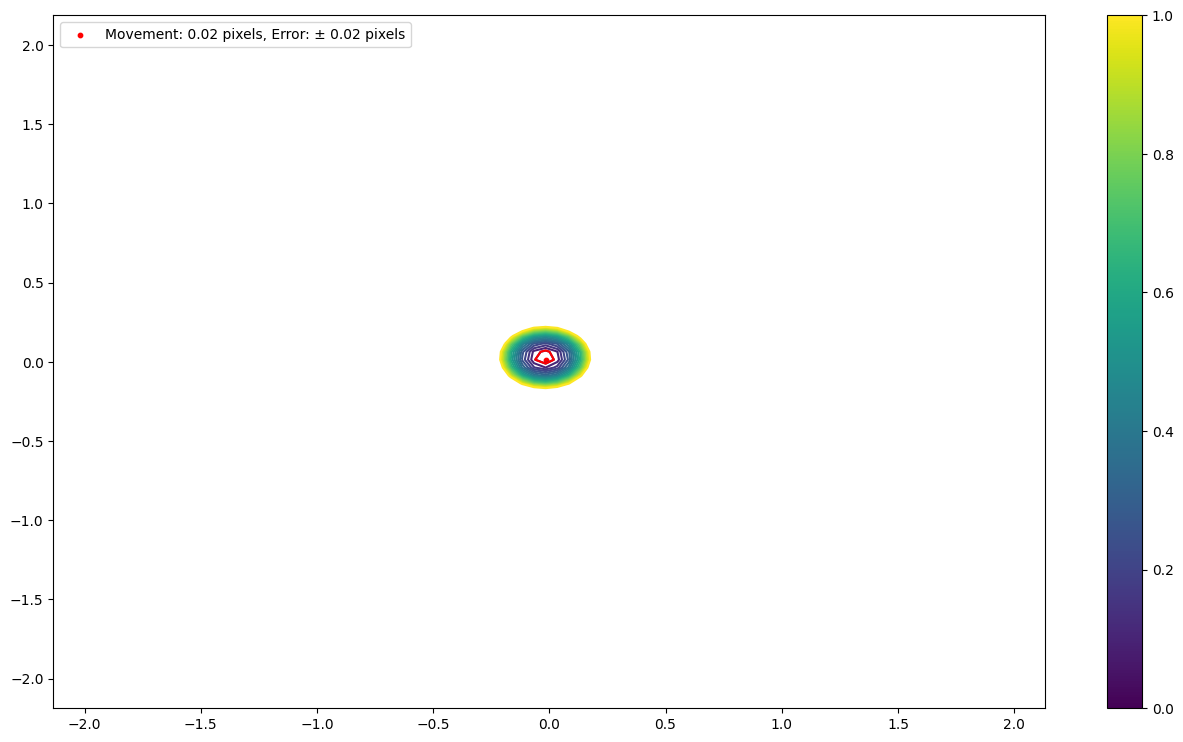

In [60]:
#13
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [433, round(433 - x_offset)-4]
cy_chi = [96, round(96 - y_offset)+4]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  2.3577938 , X shift =  0.0167571619518867 , Y shift =  0.011558176818380117
Error ± 0.025000000000000022
x error ± 0.025000000000000022 y error ± 0.025000000000000022
angle = -55.404204740812
angle error ± 70.36487969284039


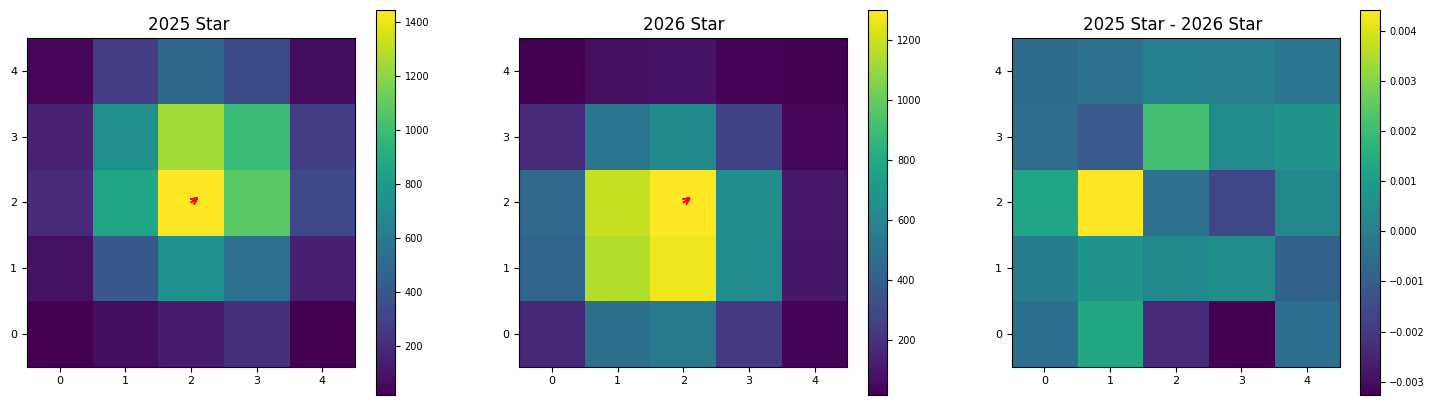

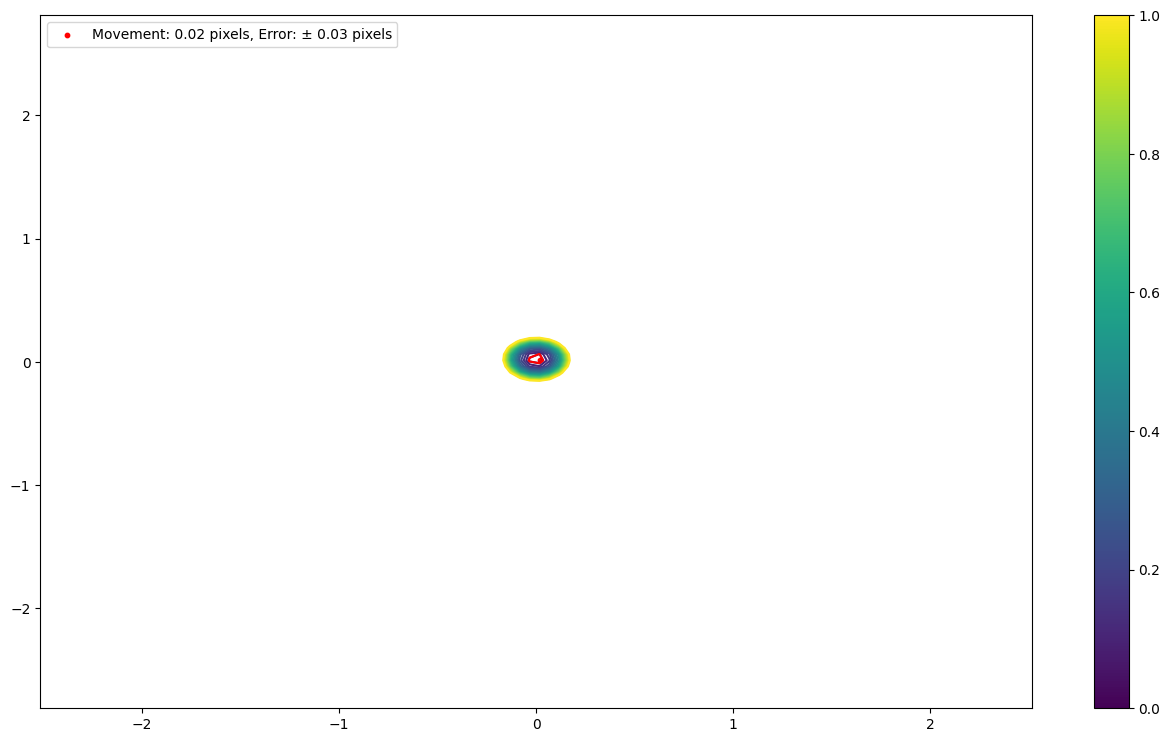

In [61]:
#14
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [784, round(784 - x_offset)-4]
cy_chi = [142, round(142 - y_offset)+4]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

In [62]:
velocity_storage_x_dither_1_3 = velocity_storage_x
velocity_storage_y_dither_1_3 = velocity_storage_y
x_error_dither_1_3 = x_error
y_error_dither_1_3 = y_error
error_bar_dither_1_3 = error_bar

# **Dither 1 25 to Dither 4 26**

In [63]:
hdu_1_A = fits.open((path_image_1 + 'nan_rm_jwst_2025_f444w_f470n_d1_frame_A.fits'))[1]
hdu_2_A = fits.open((path_image_2 + 'nan_rm_jwst_2026_f444w_f470n_d4_frame_A.fits'))[1]

In [64]:
x_offset = -783.4217949459229
y_offset  = -5.190433008656931

0.58599424 0.5653127 0.57556057


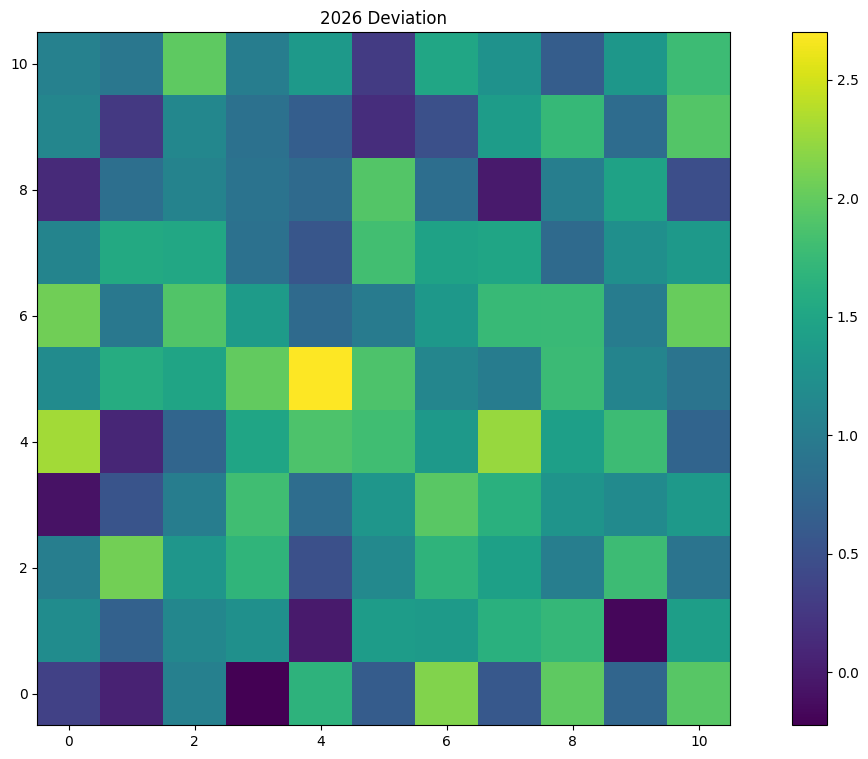

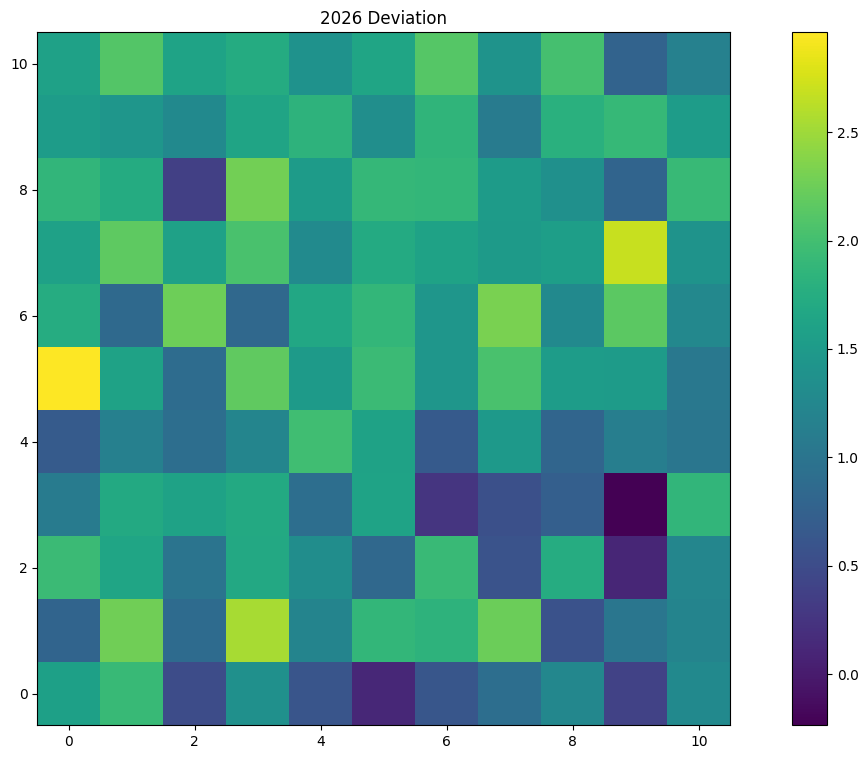

In [65]:
#define the x, y position of the knot
dev_x = [473, round(473 - x_offset)]
dev_y = [1240, round(1240 - y_offset)]
#define the size of the image
size_dev = [5, 5]
i=0
#creates the first image
std_04 = hdu_1_A.data[dev_y[i]-size_dev[i]:dev_y[i]+size_dev[i]+1, dev_x[i]-size_dev[i]:dev_x[i]+size_dev[i]+1]
#this normalizes the data to elimnate the changes in brightness and reduces error
fig, ax = plt.subplots(1, 1, figsize=(16, 9))
plt.imshow(std_04, vmin=np.min(std_04), vmax=np.max(std_04), origin="lower")
plt.colorbar()
title_1 = "2026 Deviation"
ax.set_title(title_1)
std_17 = hdu_2_A.data[dev_y[i+1]-size_dev[i+1]:dev_y[i+1]+size_dev[i+1]+1, dev_x[i+1]-size_dev[i+1]:dev_x[i+1]+size_dev[i+1]+1]
#this normalizes the data to elimnate the changes in brightness and reduces error
fig, ax = plt.subplots(1, 1, figsize=(16, 9))
plt.imshow(std_17, vmin=np.min(std_17), vmax=np.max(std_17), origin="lower")
plt.colorbar()
title_2 = "2026 Deviation"
ax.set_title(title_2)
dev_04 = np.std(std_04)
dev_17 = np.std(std_17)
deviation = np.sqrt(dev_04*dev_17)
print (dev_04, dev_17, deviation)

In [66]:
#this is where the data is stored for processing graphs at the end of calculating all of the knots
velocity_storage_x = []
velocity_storage_y = []
x_error = []
y_error = []
error_bar = []

minimum chi squared value =  5.076634 , X shift =  -1.9992275516711628 , Y shift =  -0.6125482347385178
Error ± 0.0073237575633067
x error ± 0.0 y error ± 0.024999999999999967
angle = 107.03466915857528
angle error ± 0.6549862540795911


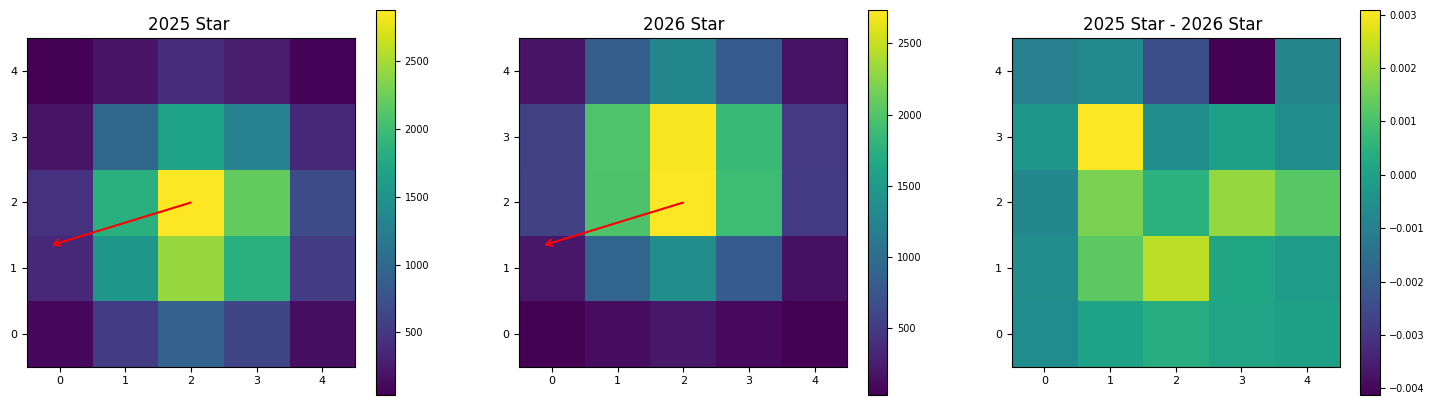

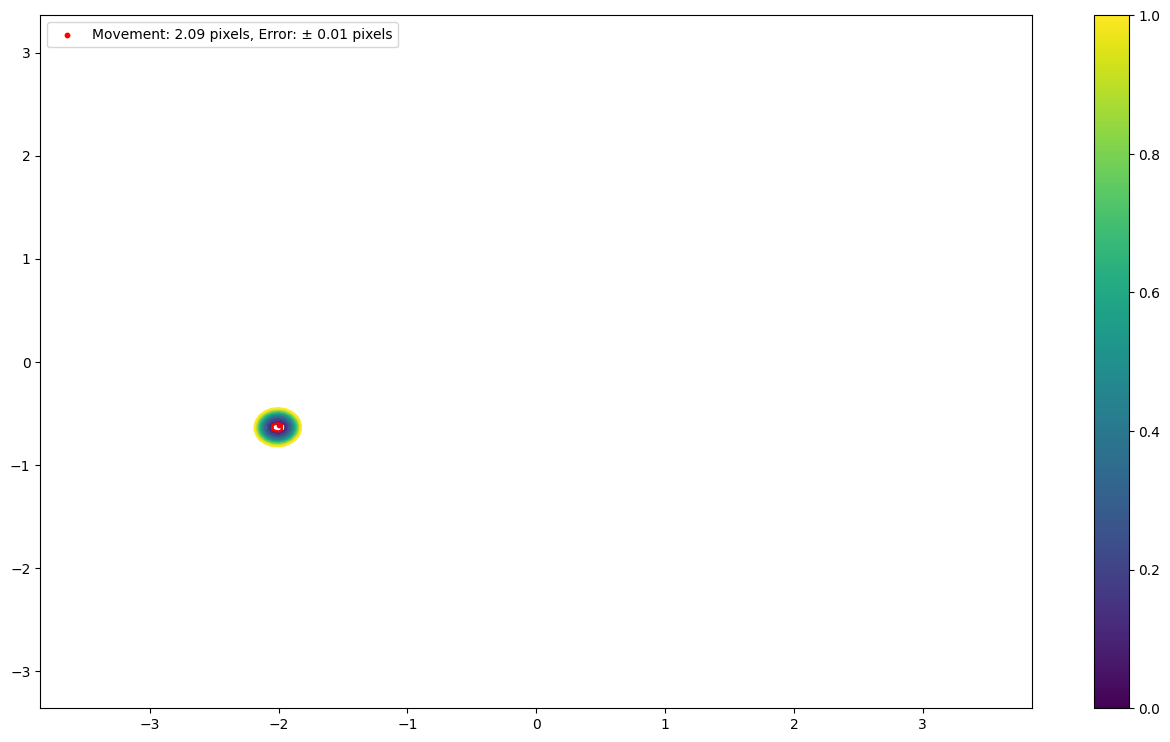

In [67]:
#1
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [177, round(177 - x_offset) +6]
cy_chi = [1910, round(1910 - y_offset)+1]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

In [68]:
# #2
# plt.rcParams['figure.max_open_warning'] = 200
# #define the x, y position of the knot
# cx_chi = [1311, round(1311 - x_offset) +1]
# cy_chi = [1752, round(1752 - y_offset)]
# #define the size of the image
# size_chi = [2, 2]
# #how much bigger the median subtraction is from the image size
# median_factor = 2
# #sets how much each chi is offset by. should be kept small to increase how accurate it is 
# shift_amount = .05
# #sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
# width = 40
# height = 40
# direction = 1
# chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

In [69]:
# #3
# plt.rcParams['figure.max_open_warning'] = 200
# #define the x, y position of the knot
# cx_chi = [1688, round(1688 - x_offset) ]
# cy_chi = [1090, round(1090 - y_offset) ]
# #define the size of the image
# size_chi = [2, 2]
# #how much bigger the median subtraction is from the image size
# median_factor = 2
# #sets how much each chi is offset by. should be kept small to increase how accurate it is 
# shift_amount = .05
# #sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
# width = 40
# height = 40
# direction = 1
# chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

In [70]:
# #4
# plt.rcParams['figure.max_open_warning'] = 200
# #define the x, y position of the knot
# cx_chi = [1965, round(1965 - x_offset) ]
# cy_chi = [1054, round(1054 - y_offset) ]
# #define the size of the image
# size_chi = [2, 2]
# #how much bigger the median subtraction is from the image size
# median_factor = 2
# #sets how much each chi is offset by. should be kept small to increase how accurate it is 
# shift_amount = .05
# #sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
# width = 40
# height = 40
# direction = 1
# chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

In [71]:
# #5
# plt.rcParams['figure.max_open_warning'] = 200
# #define the x, y position of the knot
# cx_chi = [1777, round(1777 - x_offset) ]
# cy_chi = [966, round(966 - y_offset)]
# #define the size of the image
# size_chi = [2, 2]
# #how much bigger the median subtraction is from the image size
# median_factor = 2
# #sets how much each chi is offset by. should be kept small to increase how accurate it is 
# shift_amount = .05
# #sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
# width = 40
# height = 40
# direction = 1
# chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  68.19787 , X shift =  -0.009877482810520644 , Y shift =  -0.02449578875108549
Error ± 0.1038589892218016
x error ± 0.125 y error ± 0.1
angle = 158.03913693985317
angle error ± 264.246368630831


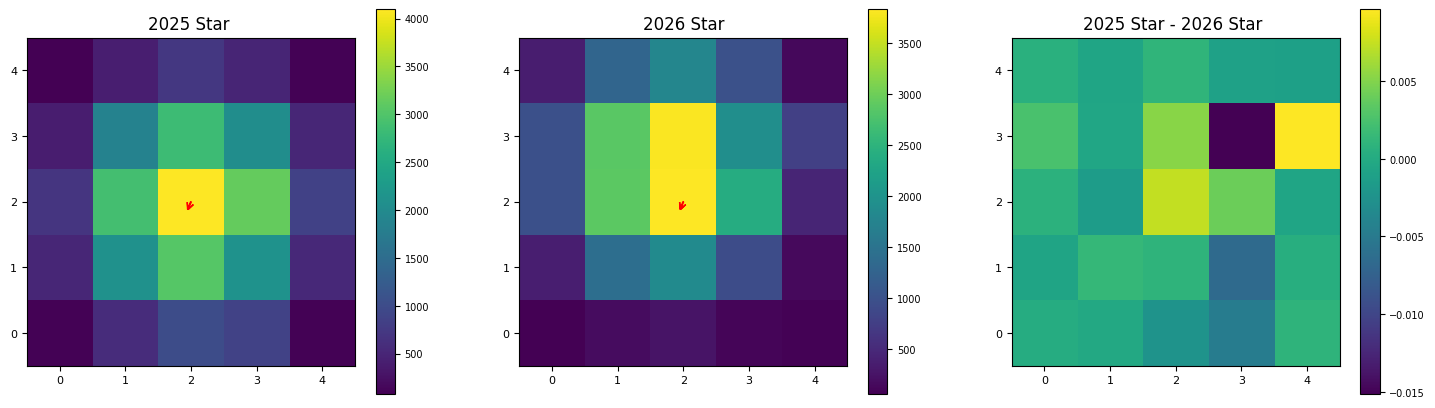

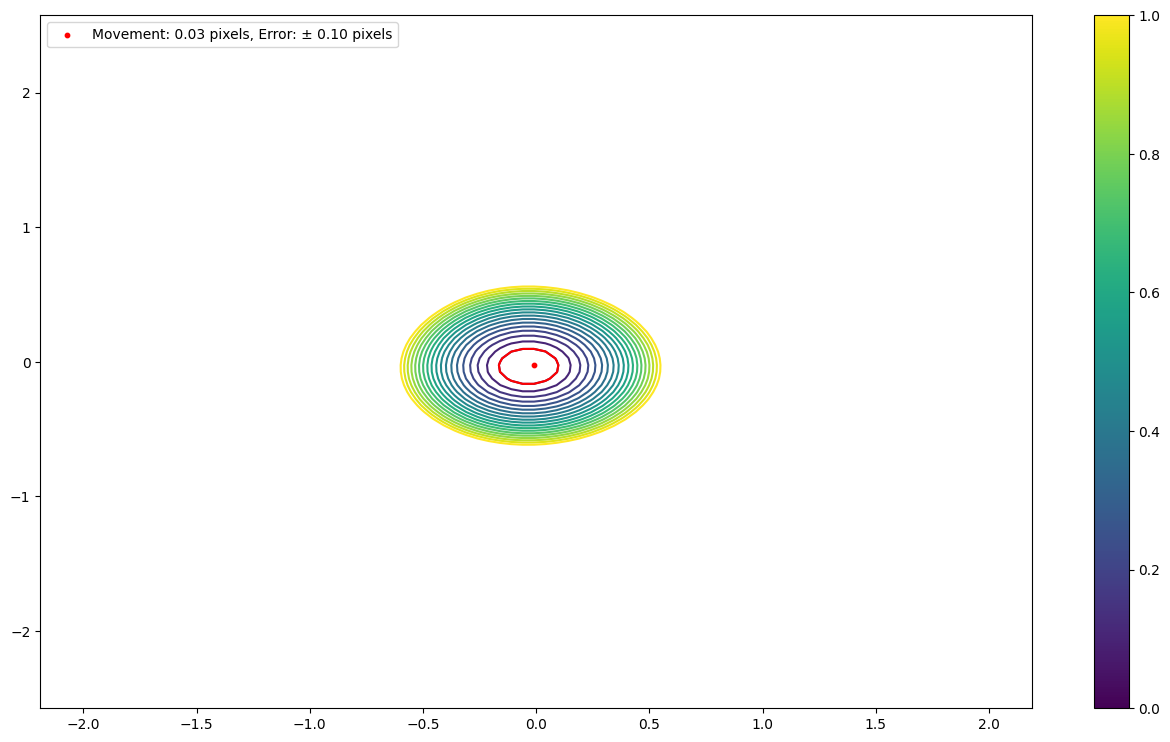

In [72]:
#6
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [673, round(673 - x_offset)-2]
cy_chi = [778, round(778 - y_offset)]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  1.3951302 , X shift =  0.006133264368941127 , Y shift =  -0.007167713193519498
Error ± 0.0
x error ± 0.0 y error ± 0.0
angle = -139.4470780529462
angle error ± 0.0


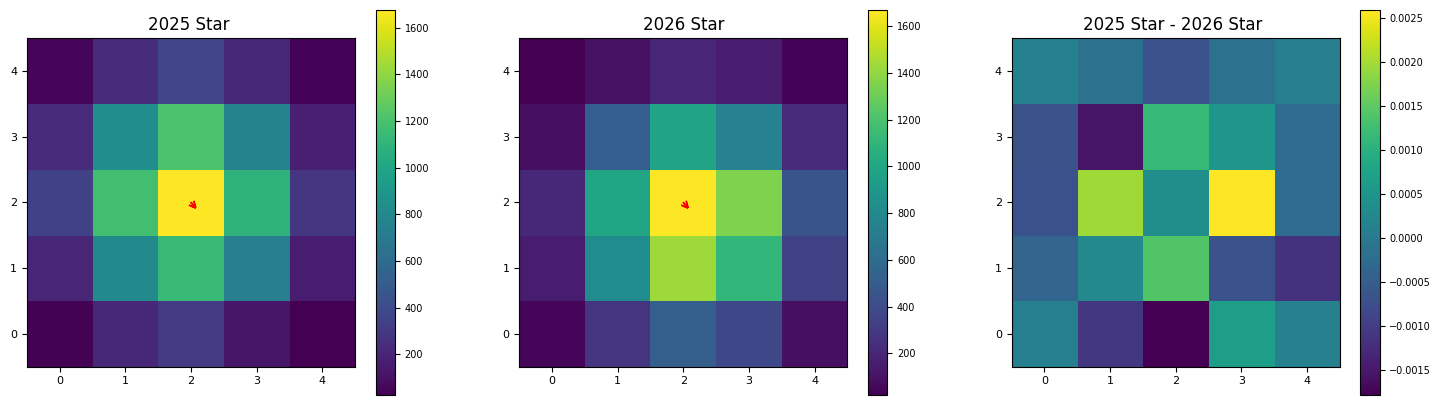

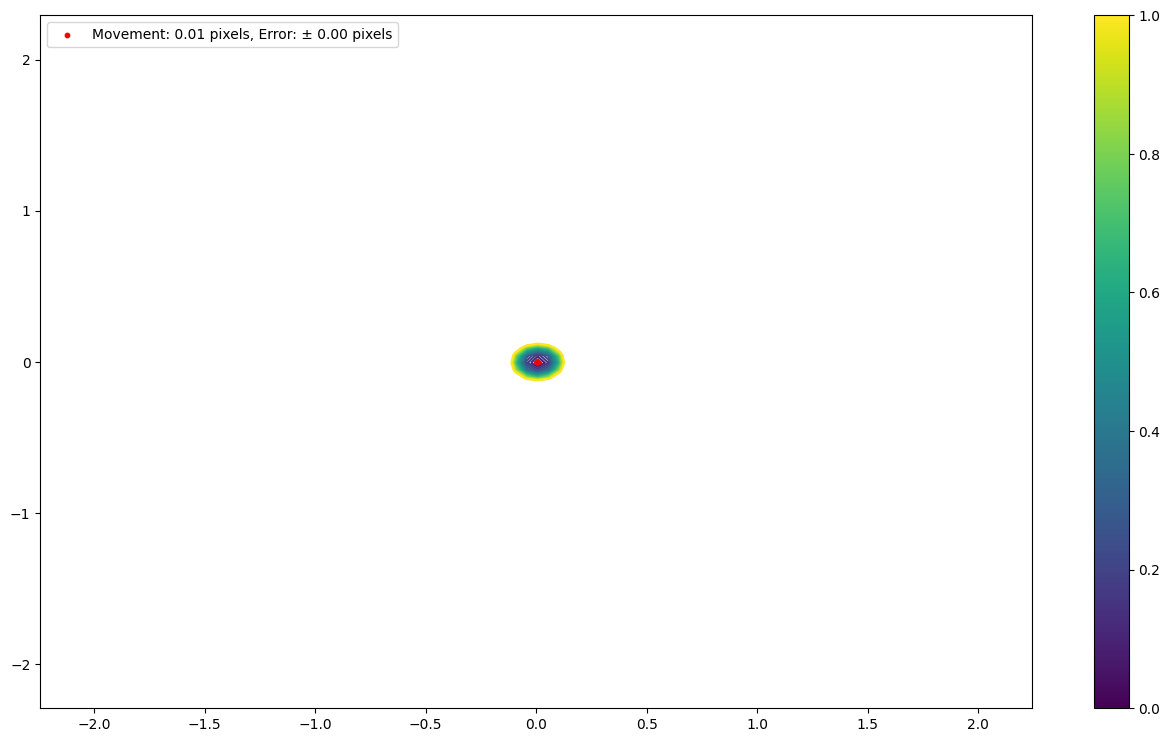

In [73]:
#7
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [1161, round(1161 - x_offset) -4]
cy_chi = [874, round(874 - y_offset)-3]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  3.3702722 , X shift =  -0.0059033606617759915 , Y shift =  -0.02352458795464879
Error ± 0.0
x error ± 0.0 y error ± 0.0
angle = 165.9128474286034
angle error ± 0.0


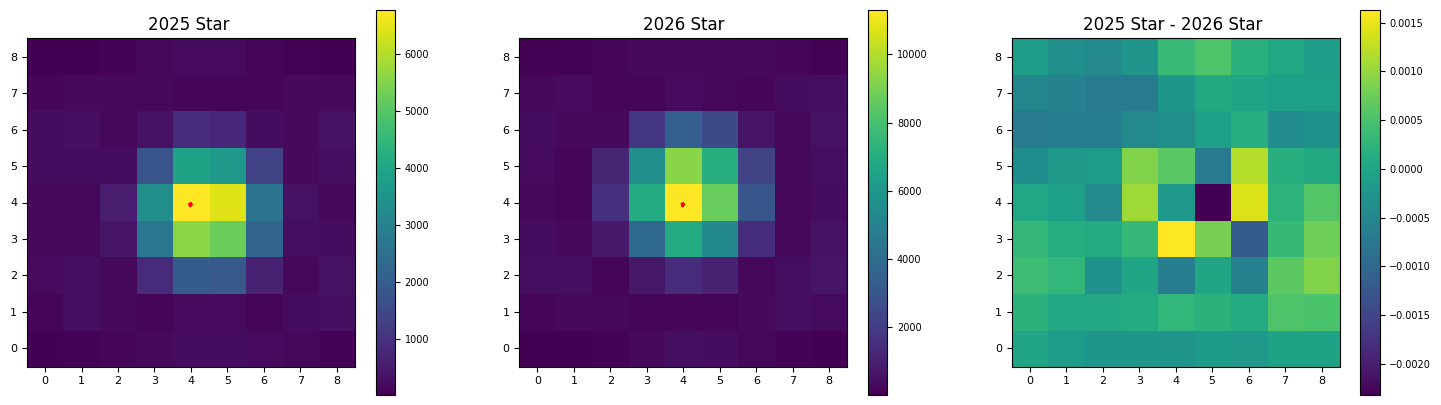

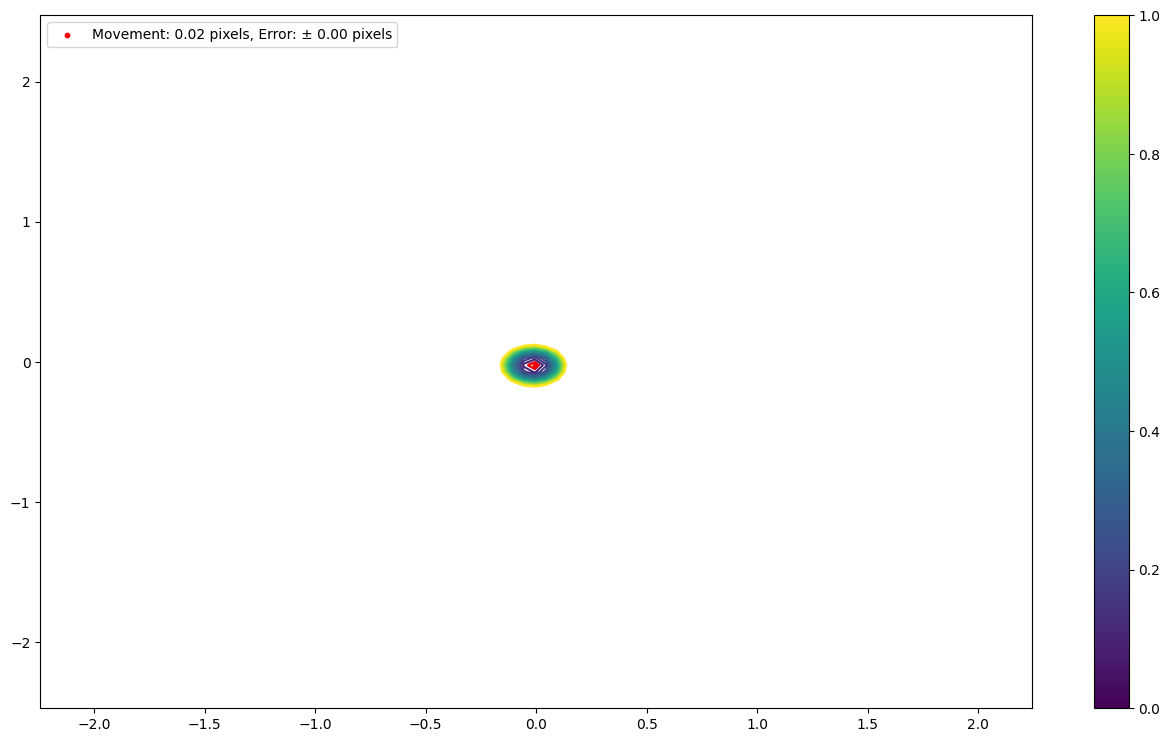

In [74]:
#8
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [41, round(41 - x_offset) -5]
cy_chi = [430, round(430 - y_offset)+5]
#define the size of the image
size_chi = [4, 4]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  6.190547 , X shift =  -0.023897751309962745 , Y shift =  0.005675374230895092
Error ± 0.005776481546845051
x error ± 0.0 y error ± 0.024999999999999994
angle = 76.6405570656667
angle error ± 56.73844561509547


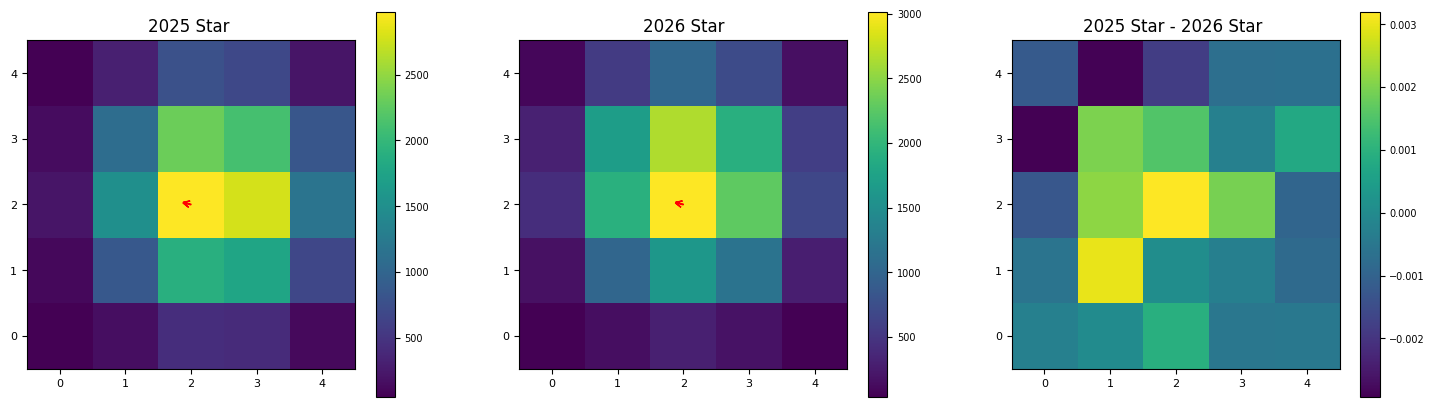

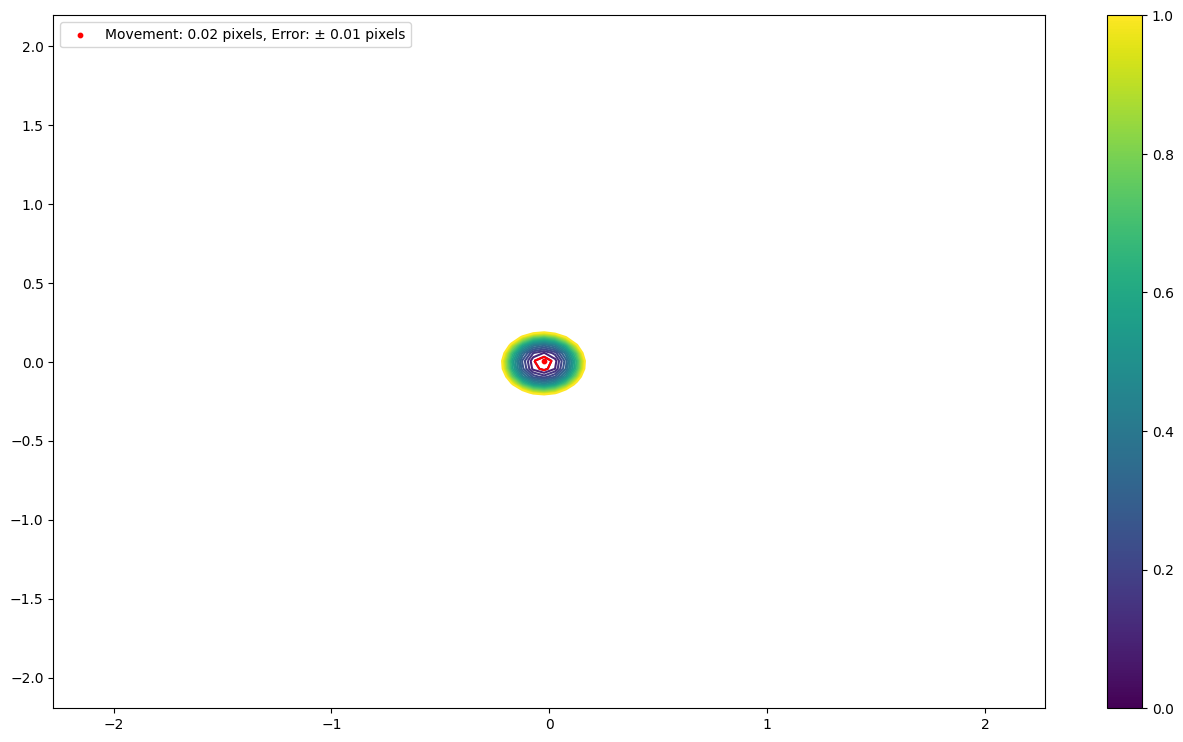

In [75]:
#9
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [88, round(88 - x_offset) -5]
cy_chi = [420, round(420 - y_offset)+5]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  0.86839867 , X shift =  -0.01302311177128107 , Y shift =  -0.029194166181287617
Error ± 0.07500000000000001
x error ± 0.07500000000000001 y error ± 0.07500000000000001
angle = 155.9590139467073
angle error ± 134.42484074789527


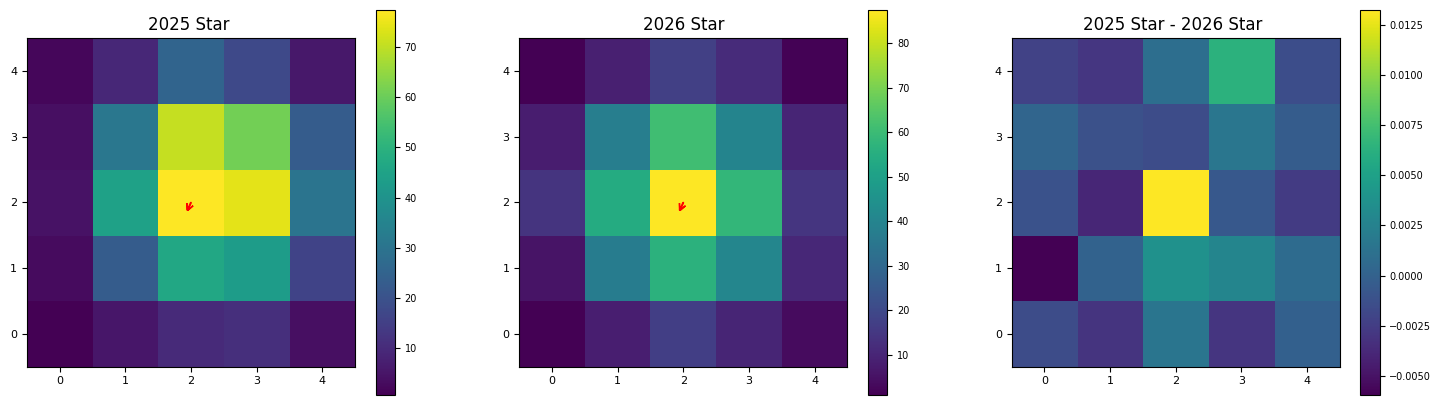

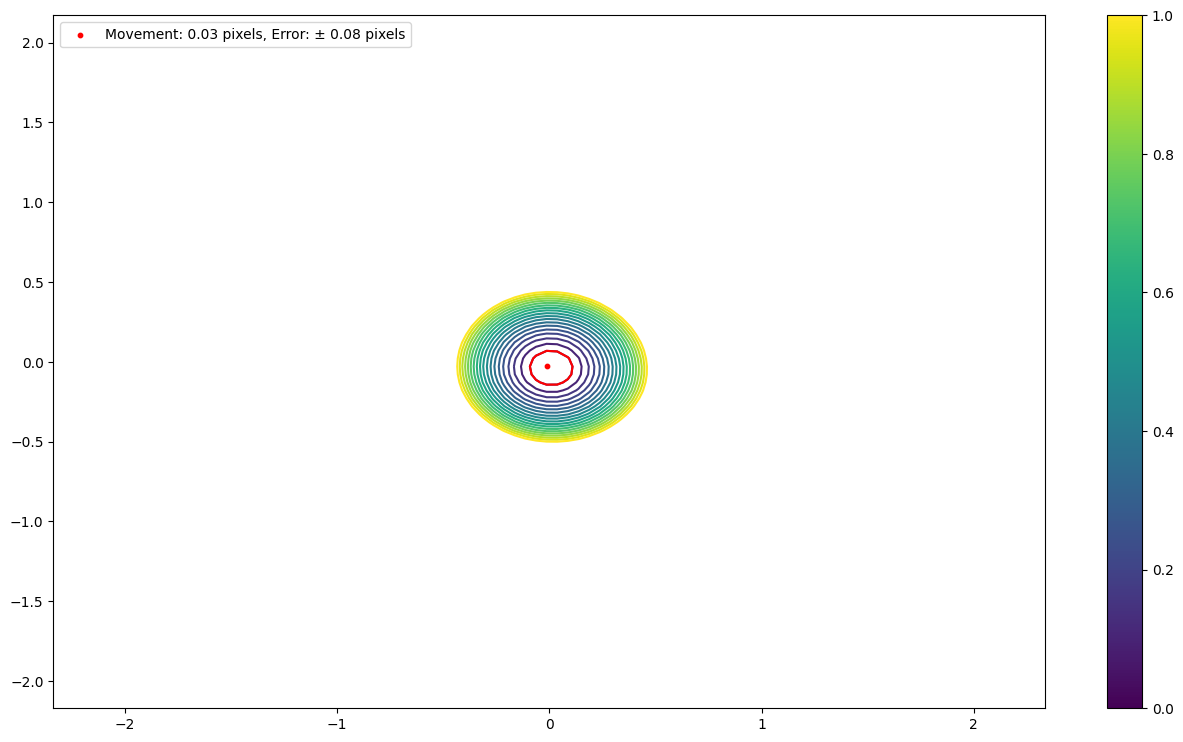

In [76]:
#10
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [314, round(314 - x_offset) -5]
cy_chi = [403, round(403 - y_offset)+4]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  0.4248323 , X shift =  -0.06488369183812215 , Y shift =  -0.11098546038974799
Error ± 0.044971144196893874
x error ± 0.025000000000000022 y error ± 0.05000000000000002
angle = 149.68883131733074
angle error ± 14.798752729621242


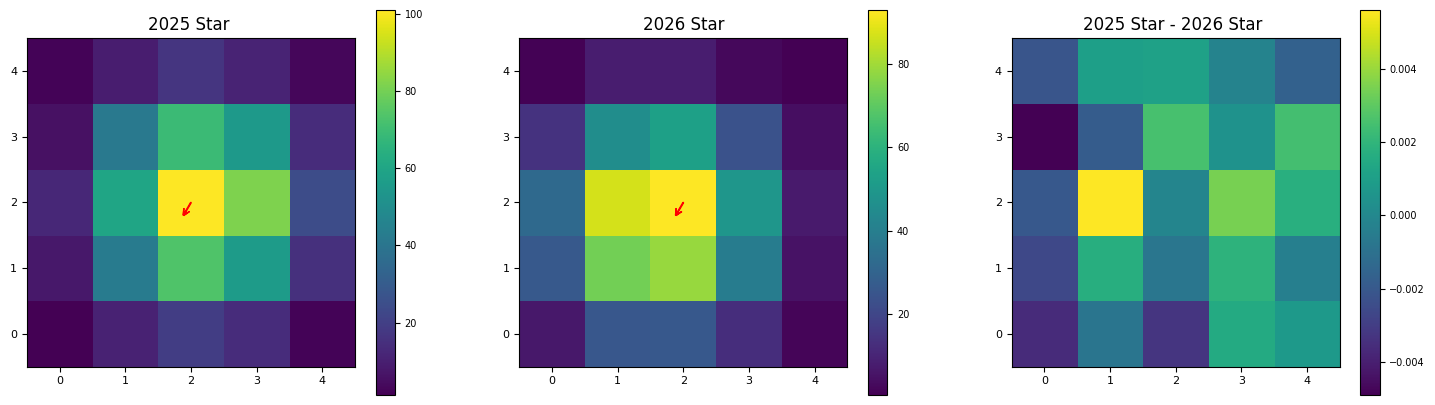

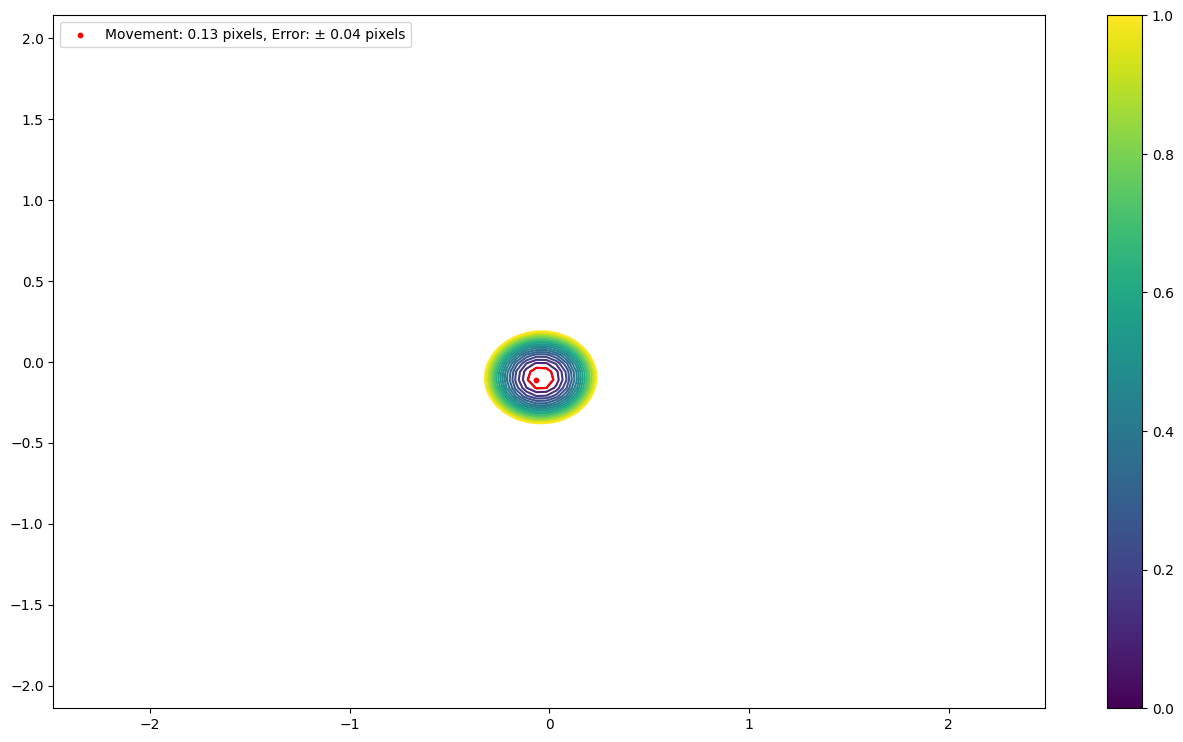

In [77]:
#11
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [471, round(471 - x_offset)-5]
cy_chi = [404, round(404 - y_offset)+3]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

In [78]:
# #12
# plt.rcParams['figure.max_open_warning'] = 200
# #define the x, y position of the knot
# cx_chi = [2001, round(2001 - x_offset)]
# cy_chi = [481, round(481 - y_offset)]
# #define the size of the image
# size_chi = [2, 2]
# #how much bigger the median subtraction is from the image size
# median_factor = 2
# #sets how much each chi is offset by. should be kept small to increase how accurate it is 
# shift_amount = .05
# #sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
# width = 40
# height = 40
# direction = 1
# chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  0.902835 , X shift =  -0.02895855034237227 , Y shift =  0.02085797355363983
Error ± 0.0
x error ± 0.0 y error ± 0.0
angle = 54.23592774160223
angle error ± 0.0


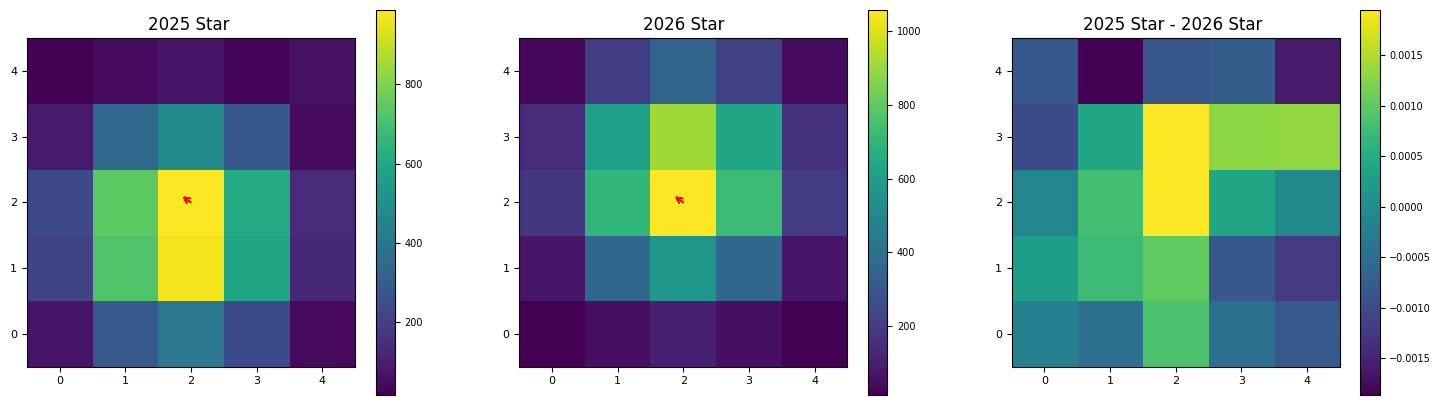

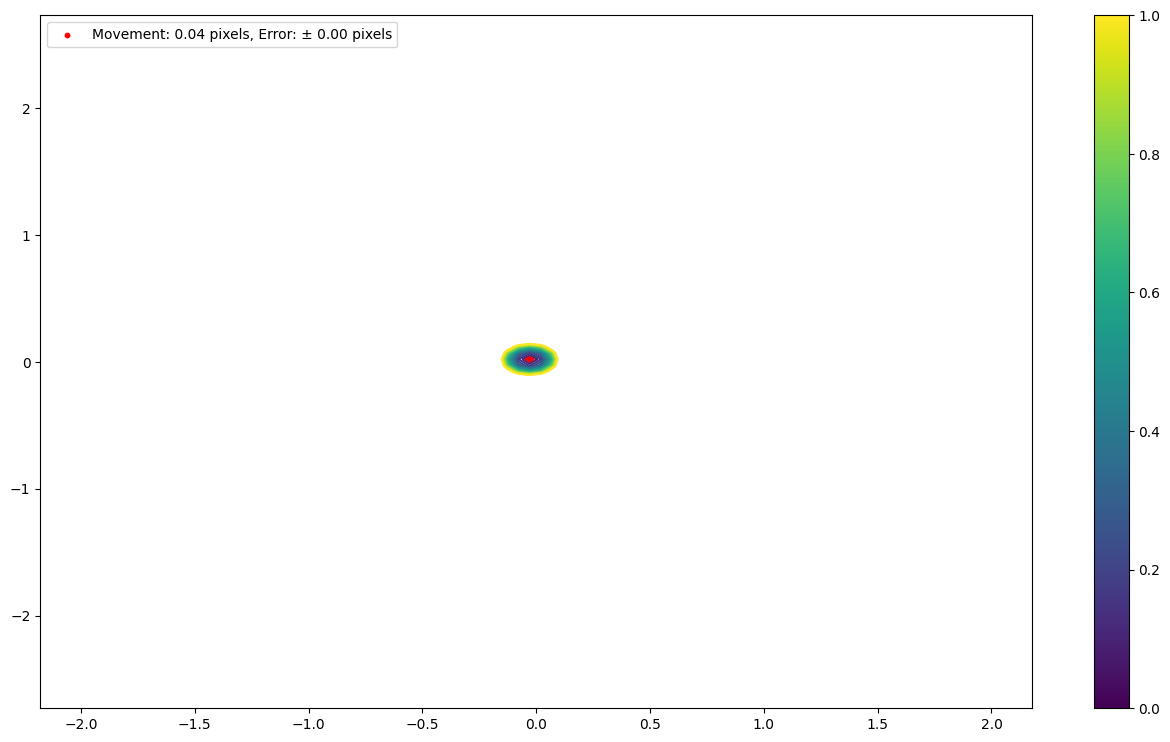

In [79]:
#13
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [433, round(433 - x_offset)-9]
cy_chi = [96, round(96 - y_offset)+3]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  9.118932 , X shift =  -0.0045301043904828475 , Y shift =  0.010851032332532817
Error ± 0.05000000000000002
x error ± 0.05000000000000002 y error ± 0.05000000000000002
angle = 22.659629773241587
angle error ± 243.63168101490908


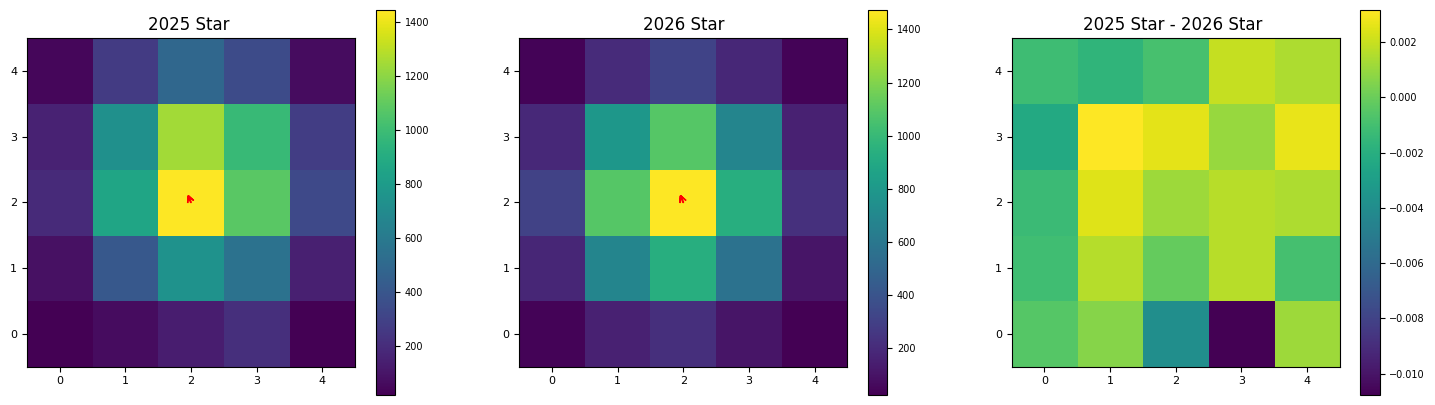

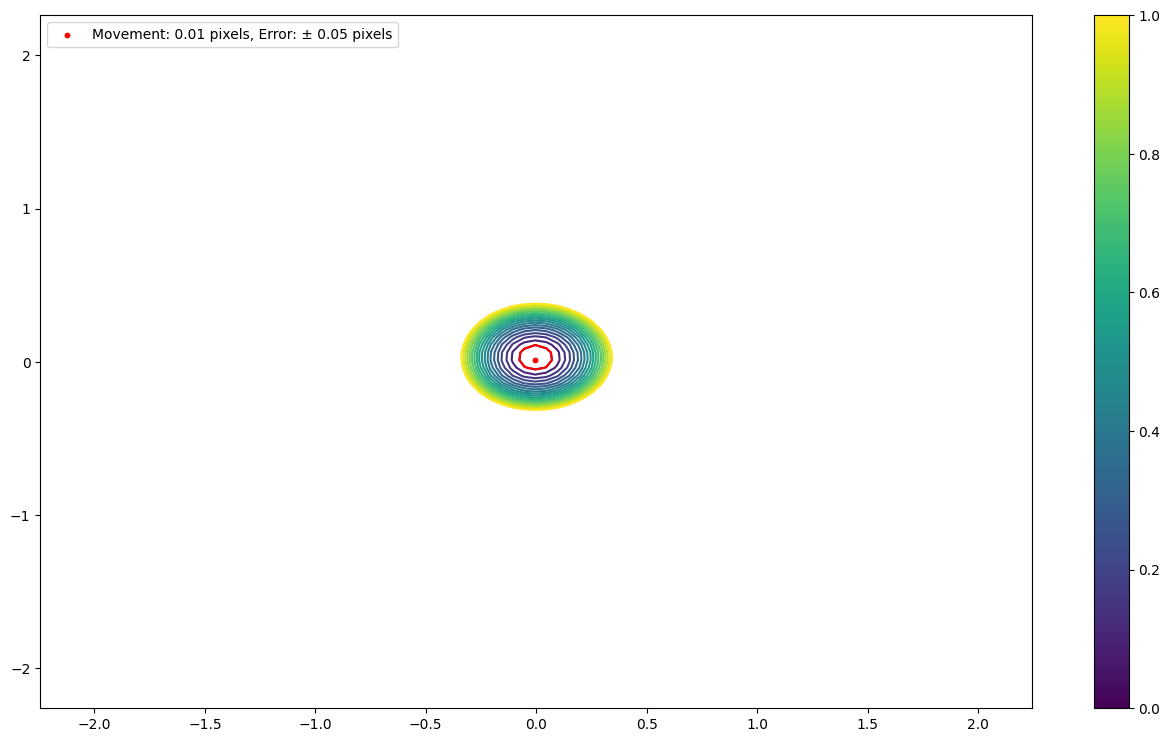

In [80]:
#14
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [784, round(784 - x_offset)-9]
cy_chi = [142, round(142 - y_offset)+2]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

In [81]:
velocity_storage_x_dither_1_4 = velocity_storage_x
velocity_storage_y_dither_1_4 = velocity_storage_y
x_error_dither_1_4 = x_error
y_error_dither_1_4 = y_error
error_bar_dither_1_4 = error_bar

# **Dither 1 25 to Dither 5 26**

In [82]:
hdu_1_A = fits.open((path_image_1 + 'nan_rm_jwst_2025_f444w_f470n_d1_frame_A.fits'))[1]
hdu_2_A = fits.open((path_image_2 + 'nan_rm_jwst_2026_f444w_f470n_d5_frame_A.fits'))[1]

In [83]:
x_offset = -786.5593240384469
y_offset  = 165.99591564857832

0.58599424 0.50575185 0.54439664


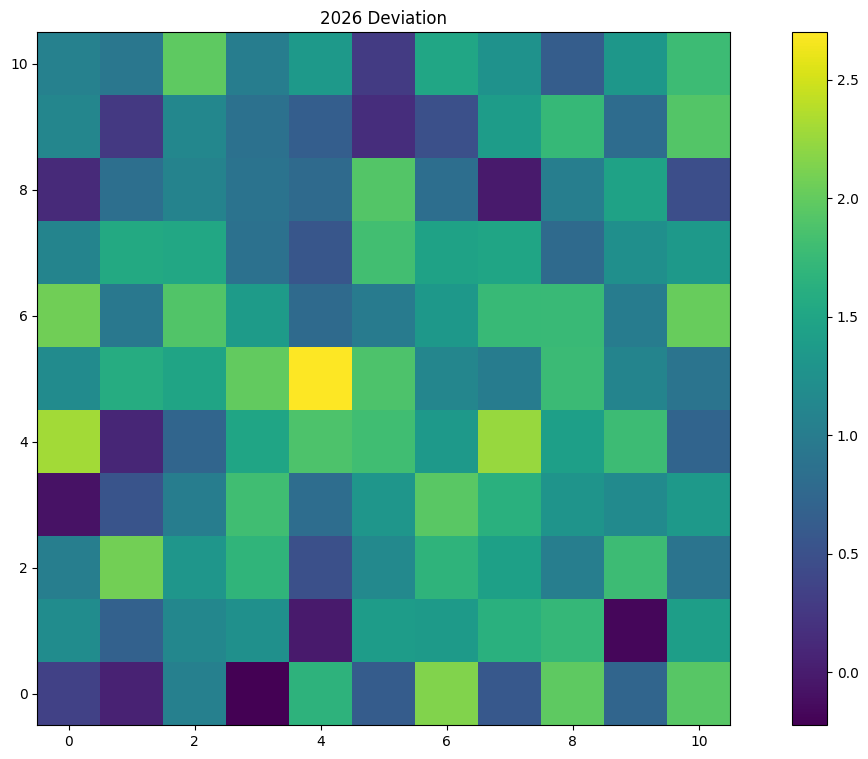

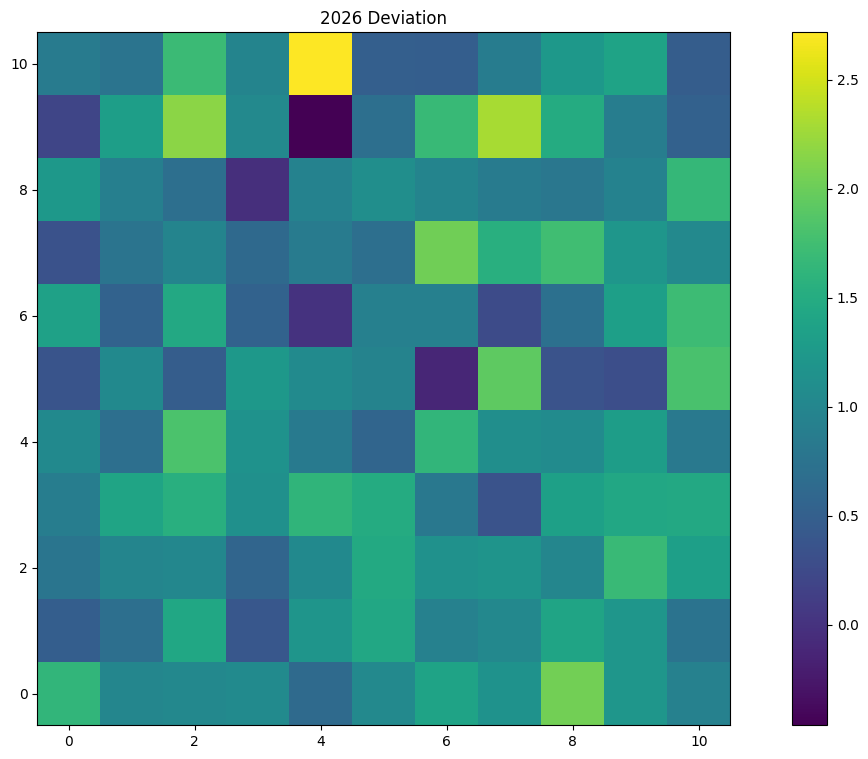

In [84]:
#define the x, y position of the knot
dev_x = [473, round(473 - x_offset)]
dev_y = [1240, round(1240 - y_offset)]
#define the size of the image
size_dev = [5, 5]
i=0
#creates the first image
std_04 = hdu_1_A.data[dev_y[i]-size_dev[i]:dev_y[i]+size_dev[i]+1, dev_x[i]-size_dev[i]:dev_x[i]+size_dev[i]+1]
#this normalizes the data to elimnate the changes in brightness and reduces error
fig, ax = plt.subplots(1, 1, figsize=(16, 9))
plt.imshow(std_04, vmin=np.min(std_04), vmax=np.max(std_04), origin="lower")
plt.colorbar()
title_1 = "2026 Deviation"
ax.set_title(title_1)
std_17 = hdu_2_A.data[dev_y[i+1]-size_dev[i+1]:dev_y[i+1]+size_dev[i+1]+1, dev_x[i+1]-size_dev[i+1]:dev_x[i+1]+size_dev[i+1]+1]
#this normalizes the data to elimnate the changes in brightness and reduces error
fig, ax = plt.subplots(1, 1, figsize=(16, 9))
plt.imshow(std_17, vmin=np.min(std_17), vmax=np.max(std_17), origin="lower")
plt.colorbar()
title_2 = "2026 Deviation"
ax.set_title(title_2)
dev_04 = np.std(std_04)
dev_17 = np.std(std_17)
deviation = np.sqrt(dev_04*dev_17)
print (dev_04, dev_17, deviation)

In [85]:
#this is where the data is stored for processing graphs at the end of calculating all of the knots
velocity_storage_x = []
velocity_storage_y = []
x_error = []
y_error = []
error_bar = []

minimum chi squared value =  3.372597 , X shift =  -2.0292354784567466 , Y shift =  -0.6497648120538656
Error ± 0.007623751014364055
x error ± 0.0 y error ± 0.024999999999999967
angle = 107.75515825410275
angle error ± 0.6402360166643829


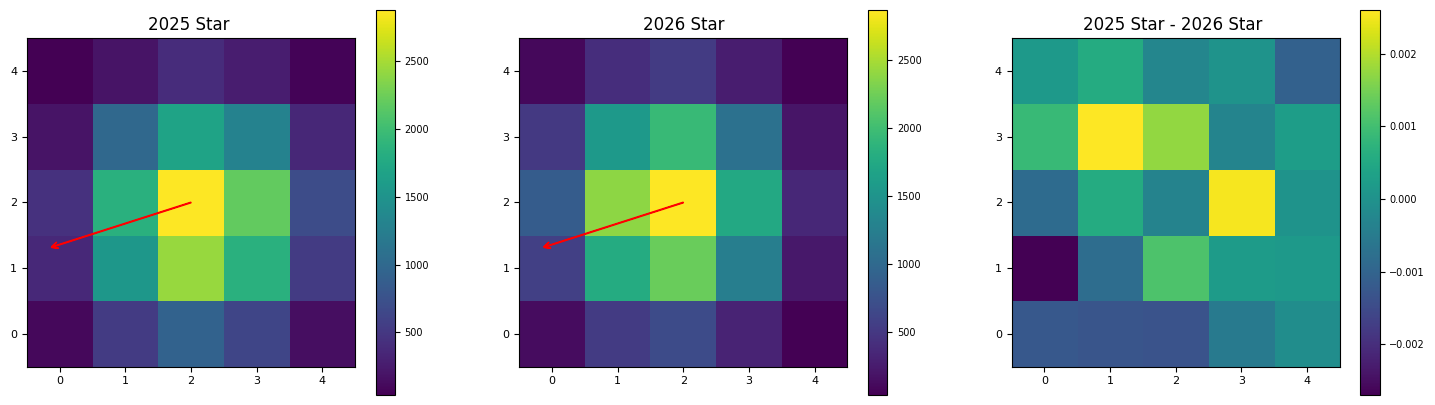

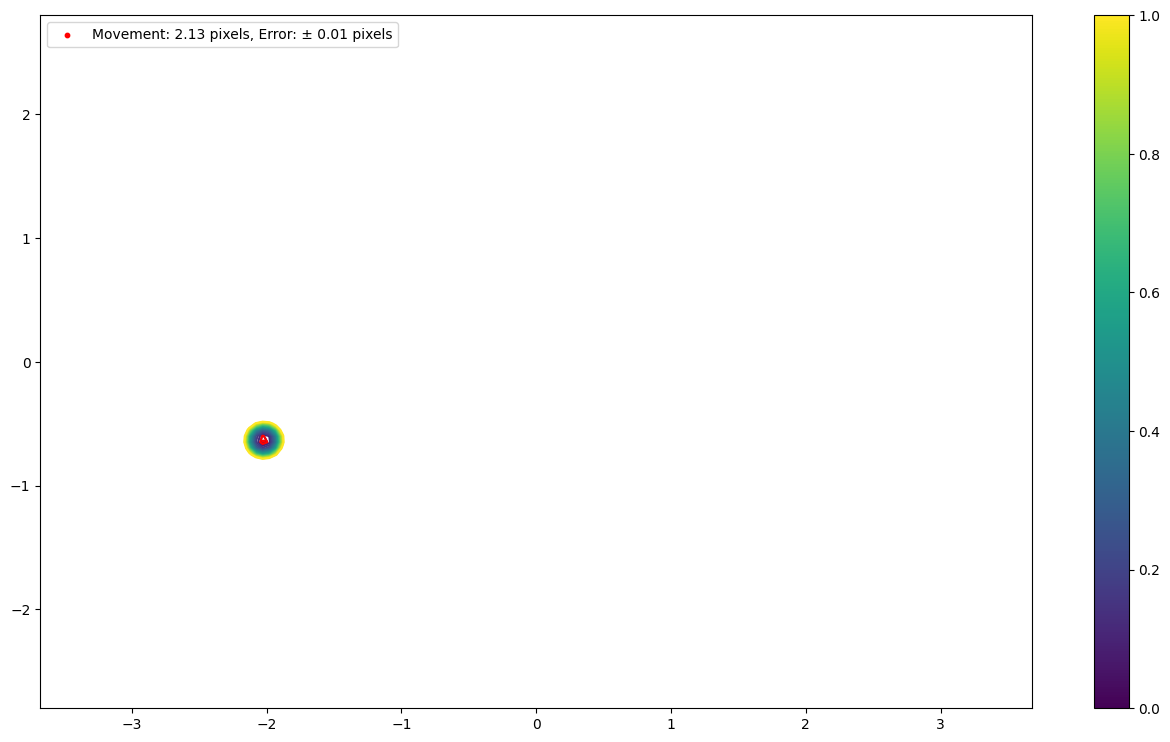

In [86]:
#1
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [177, round(177 - x_offset) +5]
cy_chi = [1910, round(1910 - y_offset)]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

In [87]:
# #2
# plt.rcParams['figure.max_open_warning'] = 200
# #define the x, y position of the knot
# cx_chi = [1311, round(1311 - x_offset) +1]
# cy_chi = [1752, round(1752 - y_offset)]
# #define the size of the image
# size_chi = [2, 2]
# #how much bigger the median subtraction is from the image size
# median_factor = 2
# #sets how much each chi is offset by. should be kept small to increase how accurate it is 
# shift_amount = .05
# #sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
# width = 40
# height = 40
# direction = 1
# chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

In [88]:
# #3
# plt.rcParams['figure.max_open_warning'] = 200
# #define the x, y position of the knot
# cx_chi = [1688, round(1688 - x_offset) ]
# cy_chi = [1090, round(1090 - y_offset) ]
# #define the size of the image
# size_chi = [2, 2]
# #how much bigger the median subtraction is from the image size
# median_factor = 2
# #sets how much each chi is offset by. should be kept small to increase how accurate it is 
# shift_amount = .05
# #sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
# width = 40
# height = 40
# direction = 1
# chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

In [89]:
# #4
# plt.rcParams['figure.max_open_warning'] = 200
# #define the x, y position of the knot
# cx_chi = [1965, round(1965 - x_offset) ]
# cy_chi = [1054, round(1054 - y_offset) ]
# #define the size of the image
# size_chi = [2, 2]
# #how much bigger the median subtraction is from the image size
# median_factor = 2
# #sets how much each chi is offset by. should be kept small to increase how accurate it is 
# shift_amount = .05
# #sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
# width = 40
# height = 40
# direction = 1
# chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

In [90]:
# #5
# plt.rcParams['figure.max_open_warning'] = 200
# #define the x, y position of the knot
# cx_chi = [1777, round(1777 - x_offset) ]
# cy_chi = [966, round(966 - y_offset)]
# #define the size of the image
# size_chi = [2, 2]
# #how much bigger the median subtraction is from the image size
# median_factor = 2
# #sets how much each chi is offset by. should be kept small to increase how accurate it is 
# shift_amount = .05
# #sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
# width = 40
# height = 40
# direction = 1
# chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  19.496634 , X shift =  -0.020120816768530836 , Y shift =  0.0158877837247815
Error ± 0.050000000000000024
x error ± 0.05 y error ± 0.050000000000000044
angle = 51.704700116274594
angle error ± 111.74319435603246


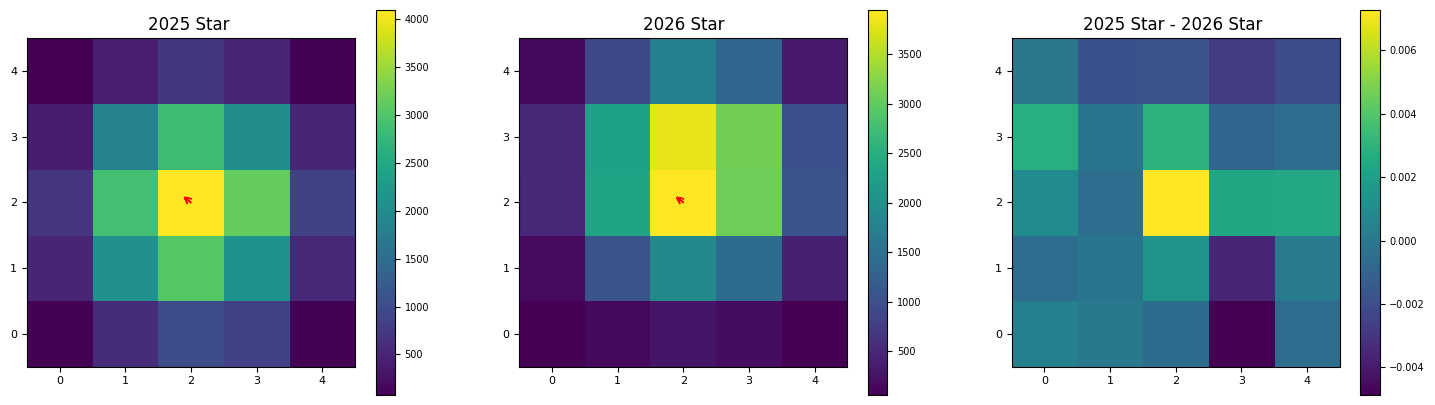

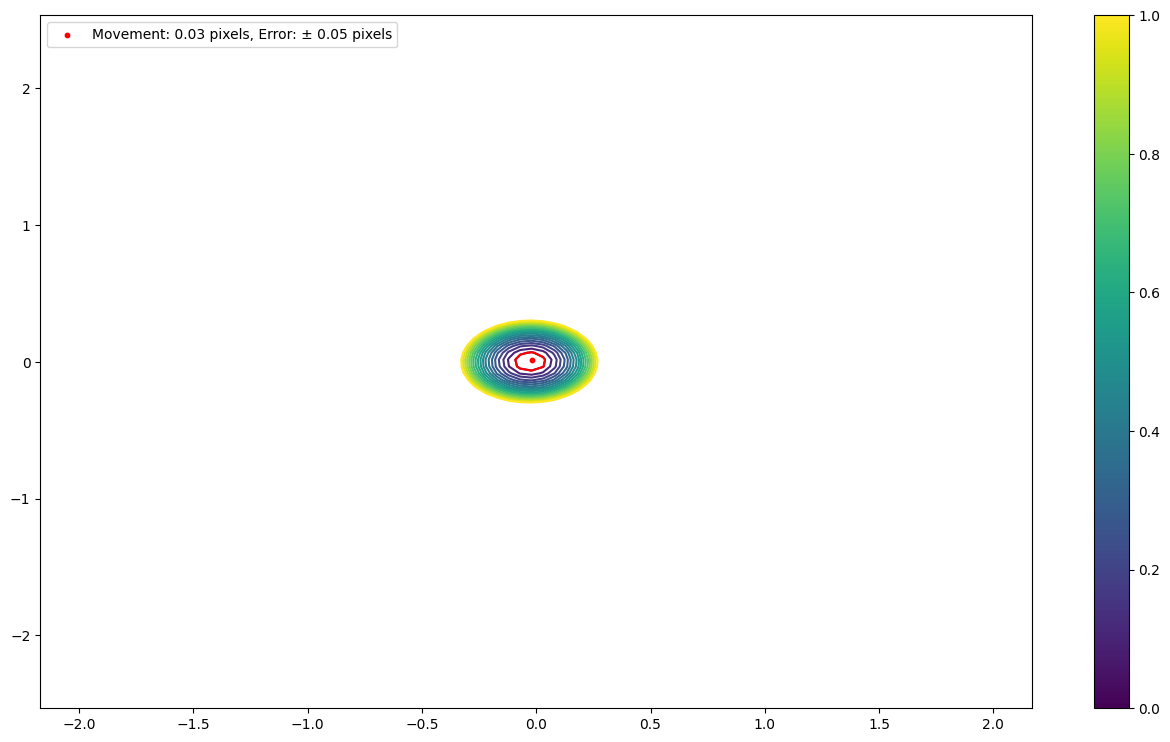

In [91]:
#6
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [673, round(673 - x_offset)-4]
cy_chi = [778, round(778 - y_offset)+1]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  3.2514317 , X shift =  0.009286775760347199 , Y shift =  0.013431092809207706
Error ± 0.014218165764826315
x error ± 0.025000000000000022 y error ± 0.0
angle = -34.661477484907955
angle error ± 72.15246984427895


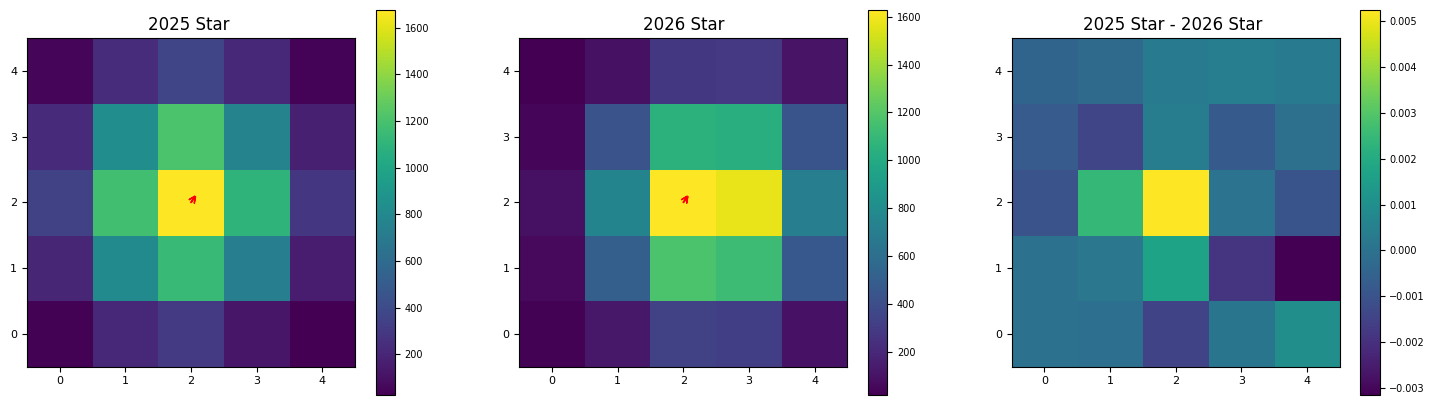

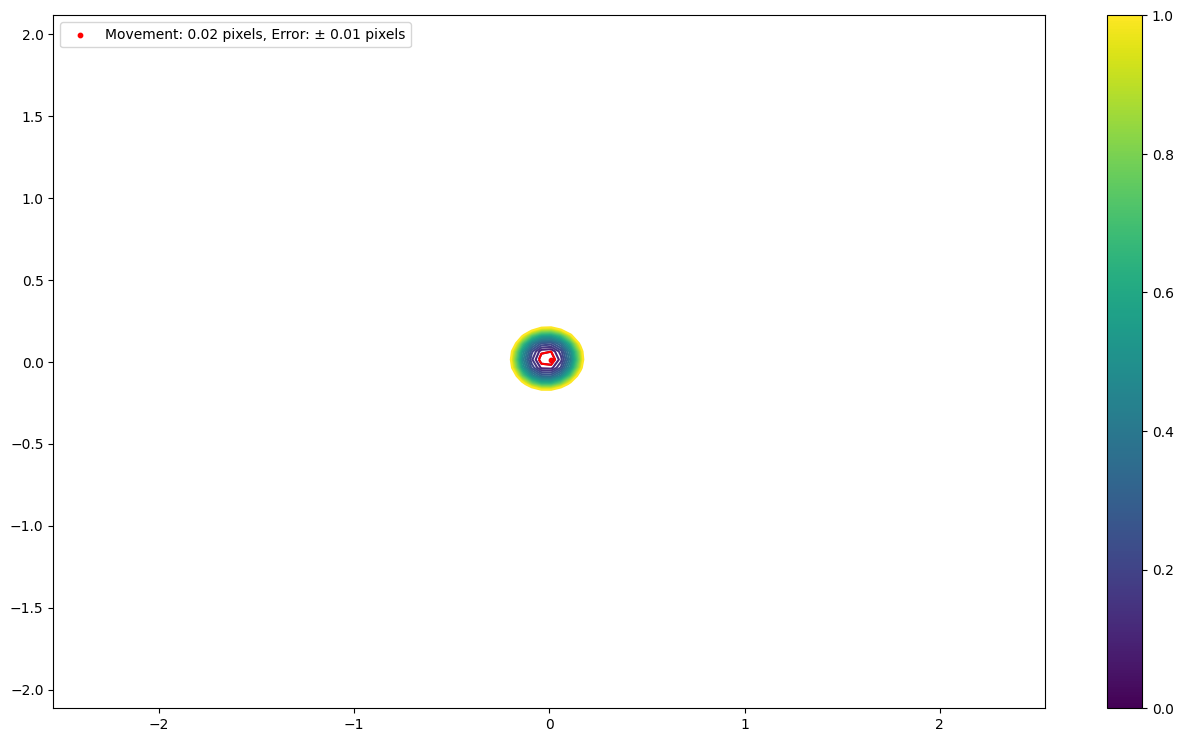

In [92]:
#7
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [1161, round(1161 - x_offset) -7]
cy_chi = [874, round(874 - y_offset)-2]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  22.232021 , X shift =  0.011129034820780204 , Y shift =  -0.04581932489521705
Error ± 0.025000000000000005
x error ± 0.024999999999999994 y error ± 0.025
angle = -166.34782795314896
angle error ± 30.378542449560186


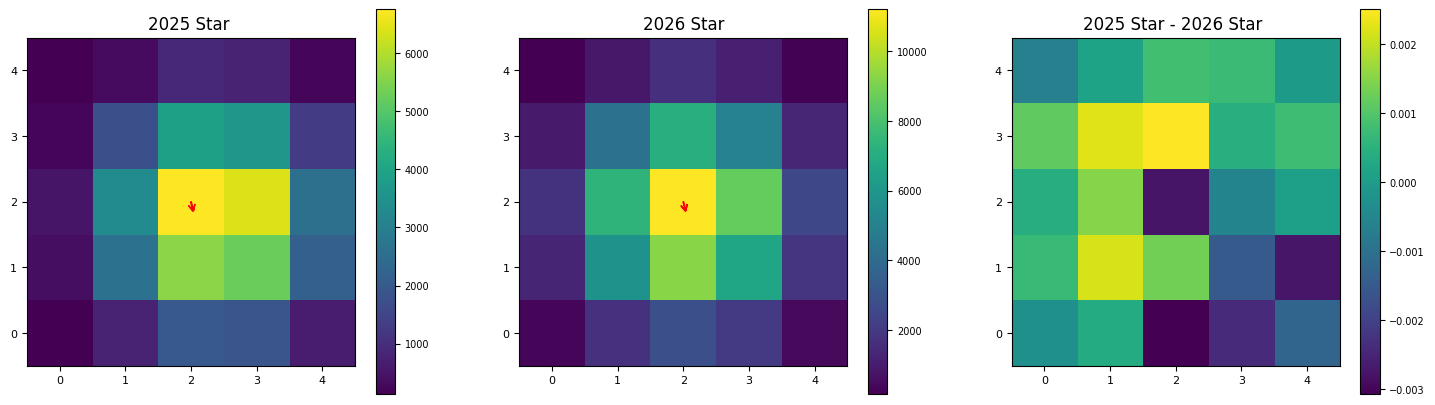

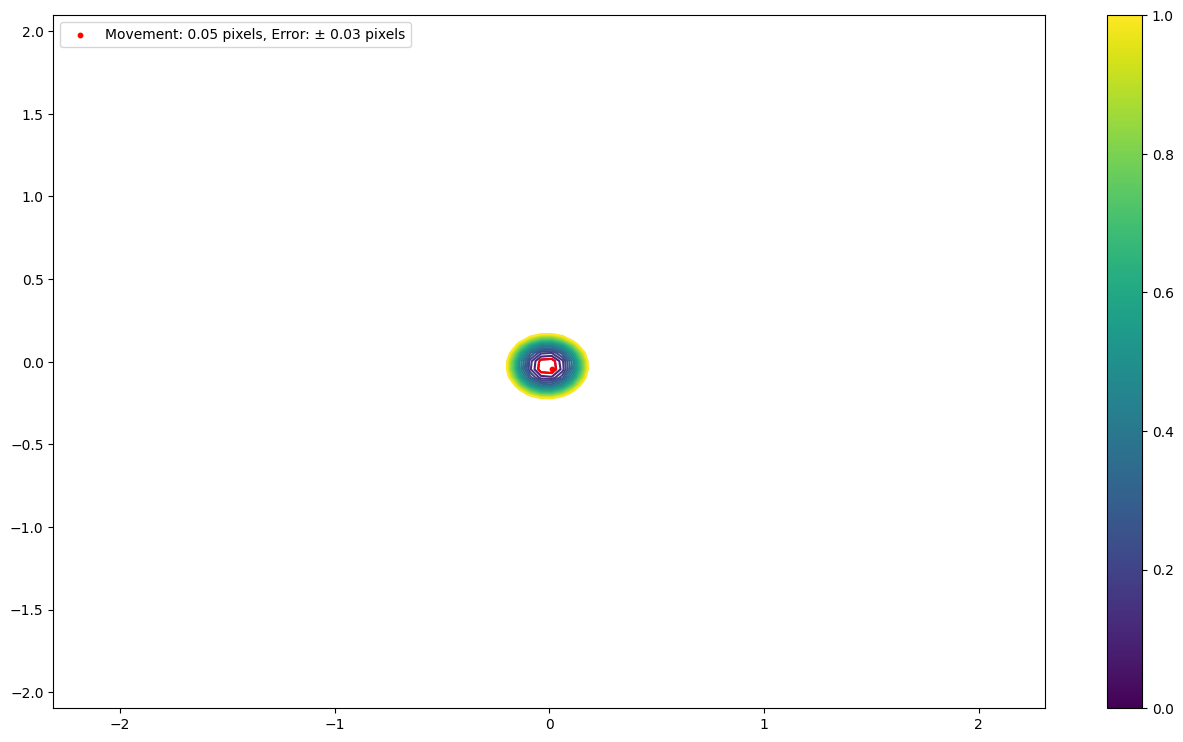

In [93]:
#8
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [41, round(41 - x_offset) -5]
cy_chi = [430, round(430 - y_offset)+7]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  13.59571 , X shift =  -0.051587083728080074 , Y shift =  -0.023817387859730865
Error ± 0.0465891628305459
x error ± 0.05000000000000002 y error ± 0.02500000000000001
angle = 114.78243267507969
angle error ± 31.152946674200944


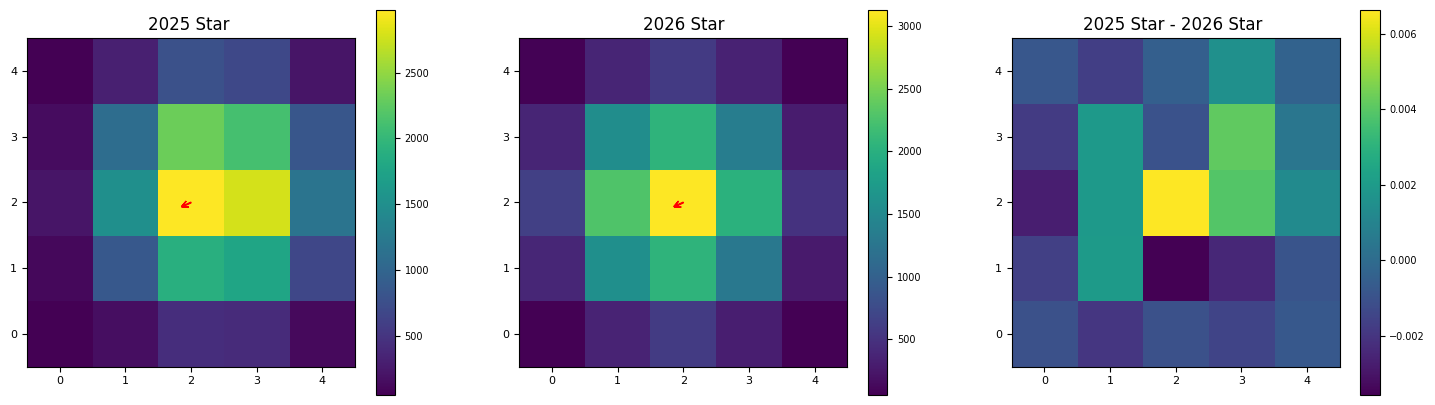

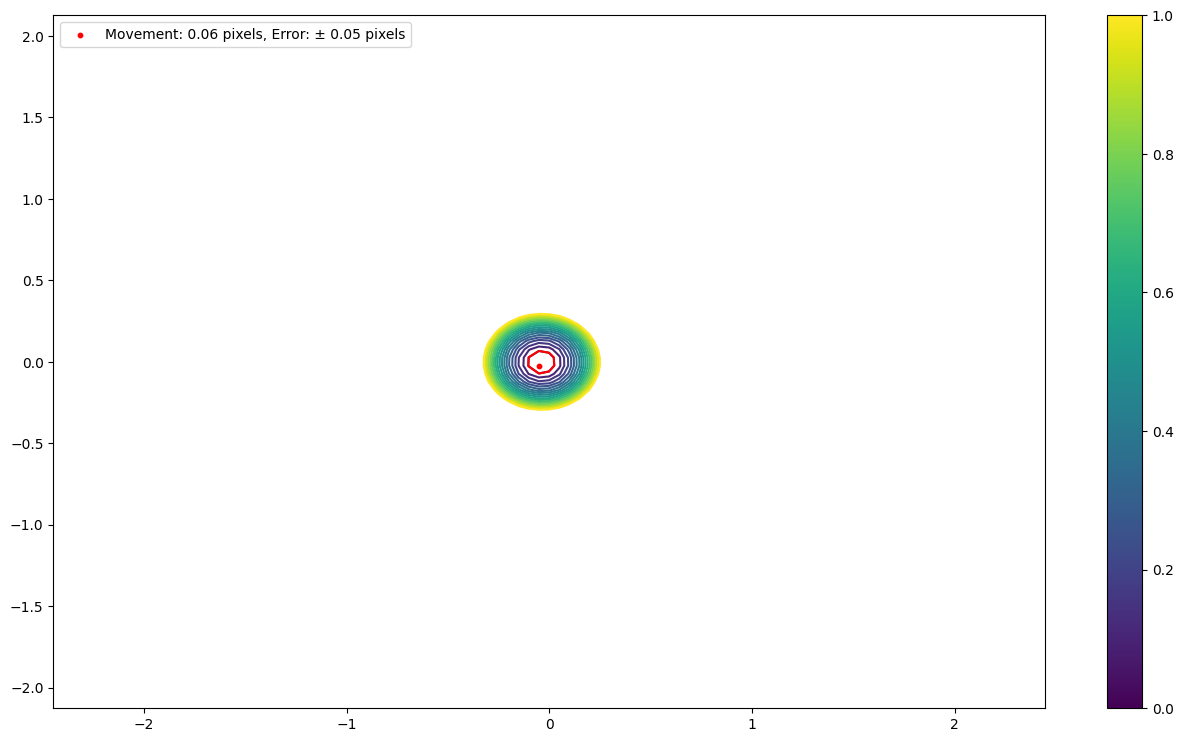

In [94]:
#9
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [88, round(88 - x_offset) -5]
cy_chi = [420, round(420 - y_offset)+7]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  0.62245566 , X shift =  0.027197263438097252 , Y shift =  -0.04554897271743247
Error ± 0.05763093073065926
x error ± 0.07500000000000001 y error ± 0.04999999999999999
angle = -149.15860074126817
angle error ± 74.85426714941644


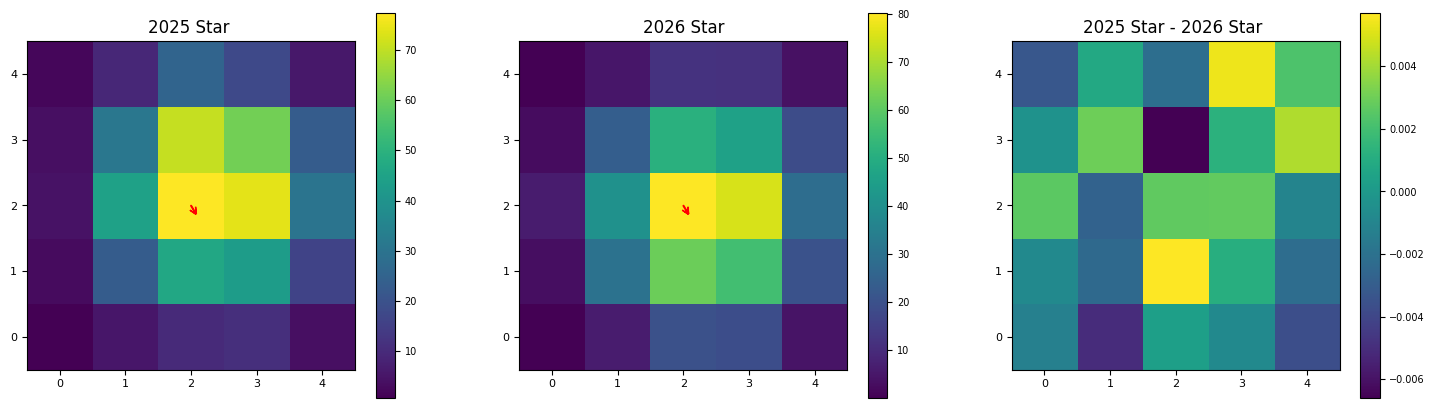

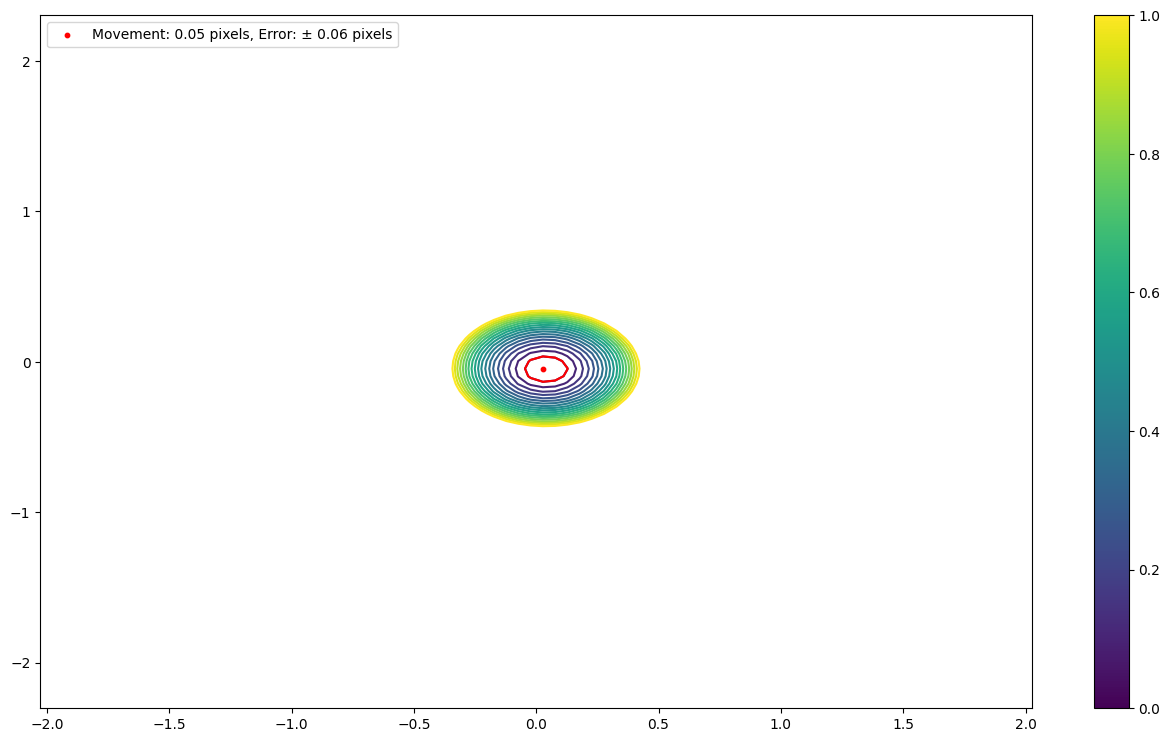

In [95]:
#10
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [314, round(314 - x_offset) -6]
cy_chi = [403, round(403 - y_offset)+6]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  0.38928264 , X shift =  -0.04930837784306741 , Y shift =  -0.13416804840592822
Error ± 0.025000000000000026
x error ± 0.025000000000000022 y error ± 0.025000000000000022
angle = 159.82101041117826
angle error ± 10.020817397883627


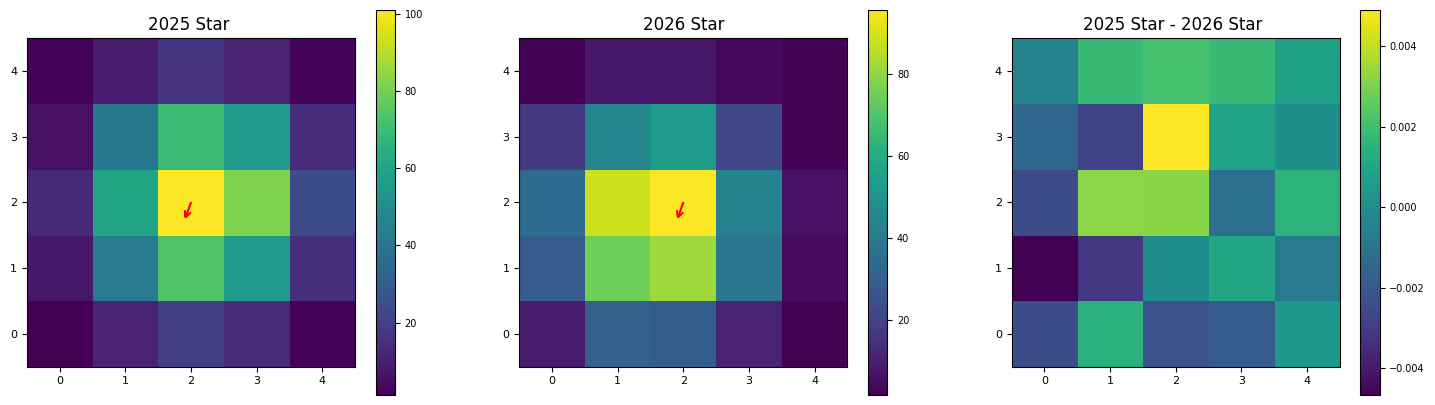

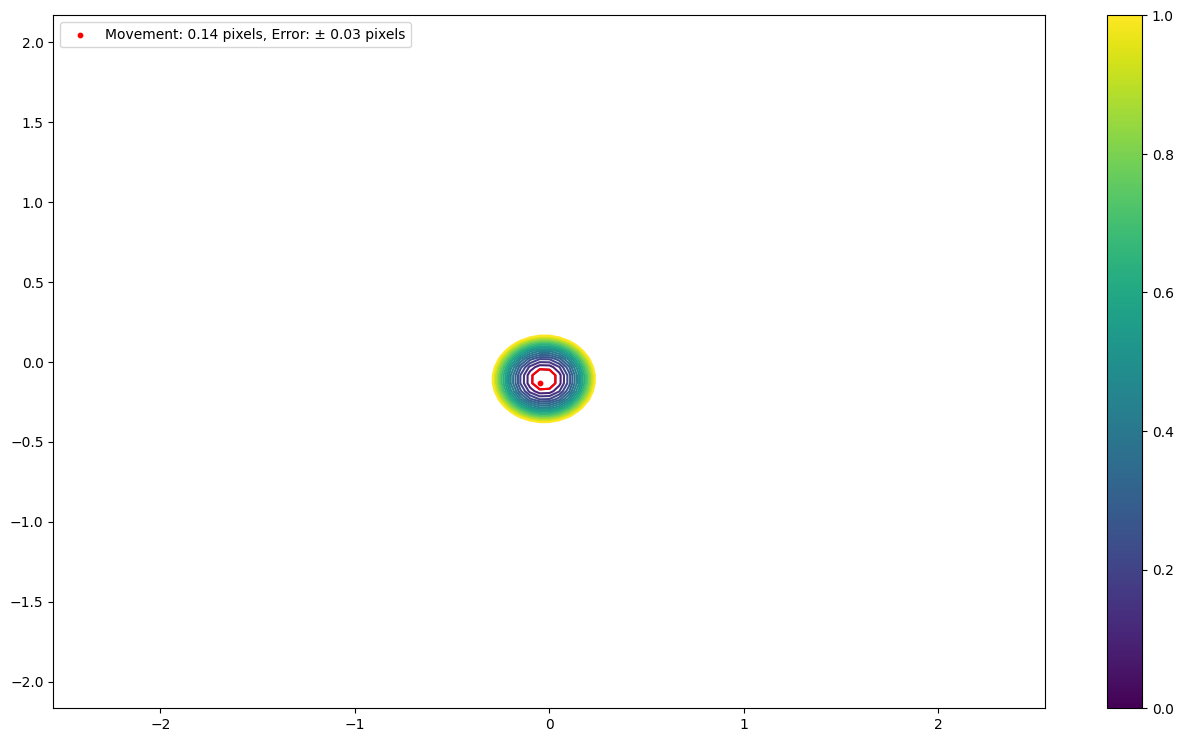

In [96]:
#11
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [471, round(471 - x_offset)-6]
cy_chi = [404, round(404 - y_offset)+5]
#define the size of the image
size_chi = [2,2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

In [97]:
# #12
# plt.rcParams['figure.max_open_warning'] = 200
# #define the x, y position of the knot
# cx_chi = [2001, round(2001 - x_offset)]
# cy_chi = [481, round(481 - y_offset)]
# #define the size of the image
# size_chi = [2, 2]
# #how much bigger the median subtraction is from the image size
# median_factor = 2
# #sets how much each chi is offset by. should be kept small to increase how accurate it is 
# shift_amount = .05
# #sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
# width = 40
# height = 40
# direction = 1
# chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

In [98]:
# #13
# plt.rcParams['figure.max_open_warning'] = 200
# #define the x, y position of the knot
# cx_chi = [433, round(433 - x_offset)]
# cy_chi = [96, round(96 - y_offset)]
# #define the size of the image
# size_chi = [2, 2]
# #how much bigger the median subtraction is from the image size
# median_factor = 2
# #sets how much each chi is offset by. should be kept small to increase how accurate it is 
# shift_amount = .05
# #sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
# width = 40
# height = 40
# direction = 1
# chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

In [99]:
# #14
# plt.rcParams['figure.max_open_warning'] = 200
# #define the x, y position of the knot
# cx_chi = [784, round(784 - x_offset)]
# cy_chi = [142, round(142 - y_offset)]
# #define the size of the image
# size_chi = [2, 2]
# #how much bigger the median subtraction is from the image size
# median_factor = 2
# #sets how much each chi is offset by. should be kept small to increase how accurate it is 
# shift_amount = .05
# #sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
# width = 40
# height = 40
# direction = 1
# chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

In [100]:
velocity_storage_x_dither_1_5 = velocity_storage_x
velocity_storage_y_dither_1_5 = velocity_storage_y
x_error_dither_1_5 = x_error
y_error_dither_1_5 = y_error
error_bar_dither_1_5 = error_bar

# **Data**

<ErrorbarContainer object of 3 artists>

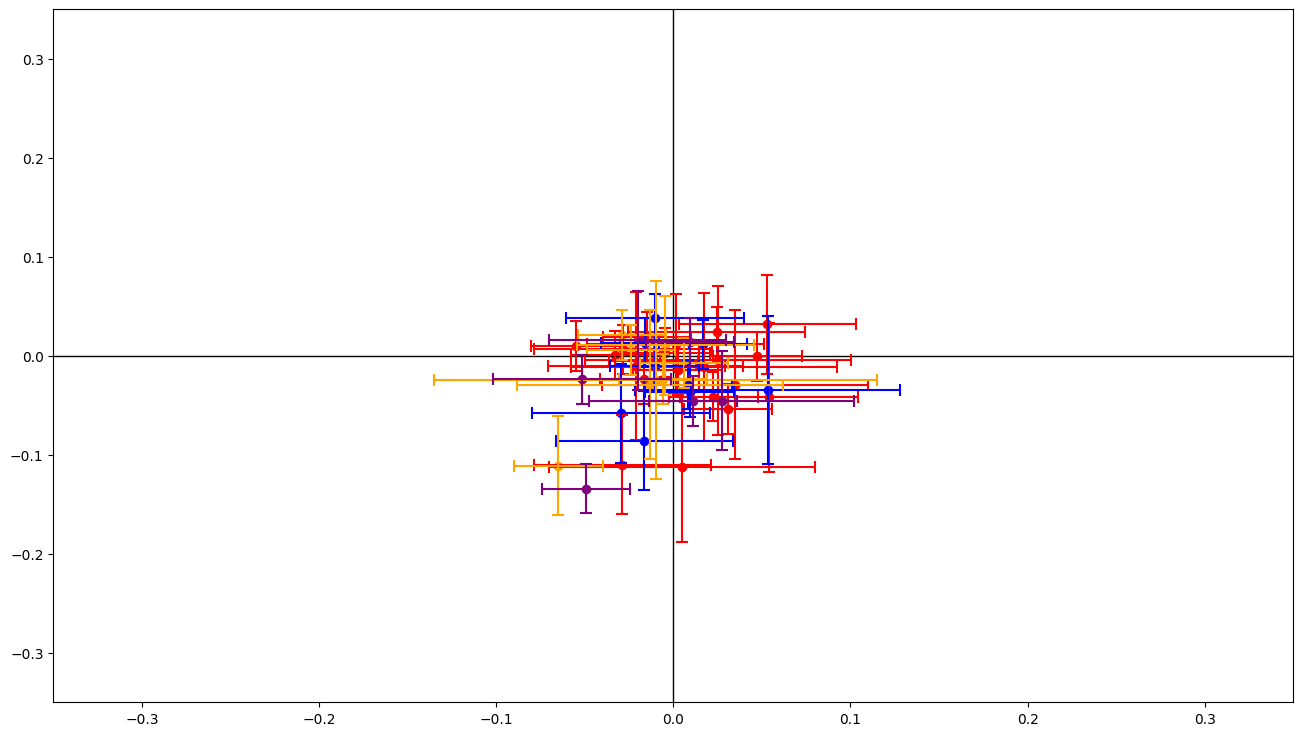

In [109]:
fig, ax = plt.subplots(1, 1, figsize=(16, 9))

ax.axhline(0, color='black', linewidth=1)
ax.axvline(0, color='black', linewidth=1)

ax.set_xlim([-.35, .35])
ax.set_ylim([-.35, .35])

ax.scatter(velocity_storage_x_dither_1_1, velocity_storage_y_dither_1_1, color='red',s=35)
ax.errorbar(velocity_storage_x_dither_1_1, velocity_storage_y_dither_1_1, xerr=x_error_dither_1_1, yerr=y_error_dither_1_1, fmt='none', ecolor='red', elinewidth=1.5, capsize=4, capthick=1.5)

ax.scatter(velocity_storage_x_dither_1_2, velocity_storage_y_dither_1_2, color='red',s=35)
ax.errorbar(velocity_storage_x_dither_1_2, velocity_storage_y_dither_1_2, xerr=x_error_dither_1_2, yerr=y_error_dither_1_2, fmt='none', ecolor='red', elinewidth=1.5, capsize=4, capthick=1.5)

ax.scatter(velocity_storage_x_dither_1_3, velocity_storage_y_dither_1_3, color='blue',s=35)
ax.errorbar(velocity_storage_x_dither_1_3, velocity_storage_y_dither_1_3, xerr=x_error_dither_1_3, yerr=y_error_dither_1_3, fmt='none', ecolor='blue', elinewidth=1.5, capsize=4, capthick=1.5)

ax.scatter(velocity_storage_x_dither_1_4, velocity_storage_y_dither_1_4, color='orange',s=35)
ax.errorbar(velocity_storage_x_dither_1_4, velocity_storage_y_dither_1_4, xerr=x_error_dither_1_4, yerr=y_error_dither_1_4, fmt='none', ecolor='orange', elinewidth=1.5, capsize=4, capthick=1.5)

ax.scatter(velocity_storage_x_dither_1_5, velocity_storage_y_dither_1_5, color='purple',s=35)
ax.errorbar(velocity_storage_x_dither_1_5, velocity_storage_y_dither_1_5, xerr=x_error_dither_1_5, yerr=y_error_dither_1_5, fmt='none', ecolor='purple', elinewidth=1.5, capsize=4, capthick=1.5)

In [102]:
def sigma_clip(x, *arrays, threshold=2):
    x = np.asarray(x, dtype=float)
    arrays = [np.asarray(arr) for arr in arrays]

    mask = np.ones(len(x), dtype=bool)

    while True:
        current = x[mask]
        z_scores = np.abs((current - np.mean(current)) / np.std(current))

        outliers = z_scores > threshold

        if not np.any(outliers):
            break

        mask[np.where(mask)[0][outliers]] = False

    return x[mask], *[arr[mask] for arr in arrays]

In [103]:
clip_velocity_storage_x_dither_1_1, clip_velocity_storage_y_dither_1_1, clip_x_error_dither_1_1, clip_y_error_dither_1_1 = sigma_clip(
   velocity_storage_x_dither_1_1,
   velocity_storage_y_dither_1_1,
   x_error_dither_1_1,
   y_error_dither_1_1
)
clip_velocity_storage_y_dither_1_1, clip_velocity_storage_x_dither_1_1, clip_y_error_dither_1_1, clip_x_error_dither_1_1 = sigma_clip(
   clip_velocity_storage_y_dither_1_1,
   clip_velocity_storage_x_dither_1_1,
   clip_y_error_dither_1_1,
   clip_x_error_dither_1_1
)


clip_velocity_storage_x_dither_1_2, clip_velocity_storage_y_dither_1_2, clip_x_error_dither_1_2, clip_y_error_dither_1_2 = sigma_clip(
   velocity_storage_x_dither_1_2,
   velocity_storage_y_dither_1_2,
   x_error_dither_1_2,
   y_error_dither_1_2
)
clip_velocity_storage_y_dither_1_2, clip_velocity_storage_x_dither_1_2, clip_y_error_dither_1_2, clip_x_error_dither_1_2 = sigma_clip(
   clip_velocity_storage_y_dither_1_2,
   clip_velocity_storage_x_dither_1_2,
   clip_y_error_dither_1_2,
   clip_x_error_dither_1_2
)


clip_velocity_storage_x_dither_1_3, clip_velocity_storage_y_dither_1_3, clip_x_error_dither_1_3, clip_y_error_dither_1_3 = sigma_clip(
    velocity_storage_x_dither_1_3,
    velocity_storage_y_dither_1_3,
    x_error_dither_1_3,
    y_error_dither_1_3
)
clip_velocity_storage_y_dither_1_3, clip_velocity_storage_x_dither_1_3, clip_y_error_dither_1_3, clip_x_error_dither_1_3 = sigma_clip(
    clip_velocity_storage_y_dither_1_3,
    clip_velocity_storage_x_dither_1_3,
    clip_y_error_dither_1_3,
    clip_x_error_dither_1_3
)

clip_velocity_storage_x_dither_1_4, clip_velocity_storage_y_dither_1_4, clip_x_error_dither_1_4, clip_y_error_dither_1_4 = sigma_clip(
    velocity_storage_x_dither_1_4,
    velocity_storage_y_dither_1_4,
    x_error_dither_1_4,
    y_error_dither_1_4
)
clip_velocity_storage_y_dither_1_4, clip_velocity_storage_x_dither_1_4, clip_y_error_dither_1_4, clip_x_error_dither_1_4 = sigma_clip(
    clip_velocity_storage_y_dither_1_4,
    clip_velocity_storage_x_dither_1_4,
    clip_y_error_dither_1_4,
    clip_x_error_dither_1_4
)

clip_velocity_storage_x_dither_1_5, clip_velocity_storage_y_dither_1_5, clip_x_error_dither_1_5, clip_y_error_dither_1_5 = sigma_clip(
    velocity_storage_x_dither_1_5,
    velocity_storage_y_dither_1_5,
    x_error_dither_1_5,
    y_error_dither_1_5
)
clip_velocity_storage_y_dither_1_5, clip_velocity_storage_x_dither_1_5, clip_y_error_dither_1_5, clip_x_error_dither_1_5 = sigma_clip(
    clip_velocity_storage_y_dither_1_5,
    clip_velocity_storage_x_dither_1_5,
    clip_y_error_dither_1_5,
    clip_x_error_dither_1_5
)

<ErrorbarContainer object of 3 artists>

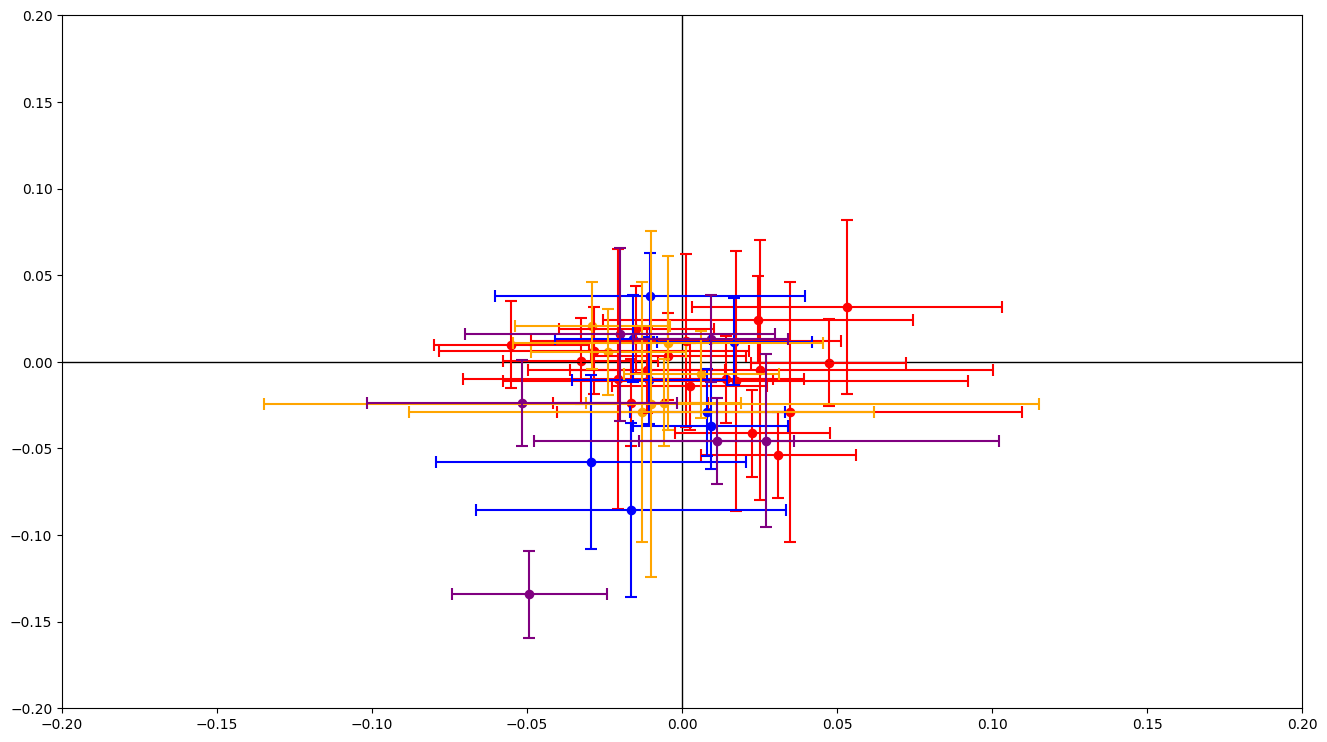

In [108]:
fig, ax = plt.subplots(1, 1, figsize=(16, 9))


ax.axhline(0, color='black', linewidth=1)
ax.axvline(0, color='black', linewidth=1)


ax.set_xlim([-.2, .2])
ax.set_ylim([-.2, .2])

ax.scatter(clip_velocity_storage_x_dither_1_1, clip_velocity_storage_y_dither_1_1, color='red',s=35)
ax.errorbar(clip_velocity_storage_x_dither_1_1, clip_velocity_storage_y_dither_1_1, xerr=clip_x_error_dither_1_1, yerr=clip_y_error_dither_1_1, fmt='none', ecolor='red', elinewidth=1.5, capsize=4, capthick=1.5)


ax.scatter(clip_velocity_storage_x_dither_1_2, clip_velocity_storage_y_dither_1_2, color='red',s=35)
ax.errorbar(clip_velocity_storage_x_dither_1_2, clip_velocity_storage_y_dither_1_2, xerr=clip_x_error_dither_1_2, yerr=clip_y_error_dither_1_2, fmt='none', ecolor='red', elinewidth=1.5, capsize=4, capthick=1.5)


ax.scatter(clip_velocity_storage_x_dither_1_3, clip_velocity_storage_y_dither_1_3, color='blue',s=35)
ax.errorbar(clip_velocity_storage_x_dither_1_3, clip_velocity_storage_y_dither_1_3, xerr=clip_x_error_dither_1_3, yerr=clip_y_error_dither_1_3, fmt='none', ecolor='blue', elinewidth=1.5, capsize=4, capthick=1.5)


ax.scatter(clip_velocity_storage_x_dither_1_4, clip_velocity_storage_y_dither_1_4, color='orange',s=35)
ax.errorbar(clip_velocity_storage_x_dither_1_4, clip_velocity_storage_y_dither_1_4, xerr=clip_x_error_dither_1_4, yerr=clip_y_error_dither_1_4, fmt='none', ecolor='orange', elinewidth=1.5, capsize=4, capthick=1.5)


ax.scatter(clip_velocity_storage_x_dither_1_5, clip_velocity_storage_y_dither_1_5, color='purple',s=35)
ax.errorbar(clip_velocity_storage_x_dither_1_5, clip_velocity_storage_y_dither_1_5, xerr=clip_x_error_dither_1_5, yerr=clip_y_error_dither_1_5, fmt='none', ecolor='purple', elinewidth=1.5, capsize=4, capthick=1.5)

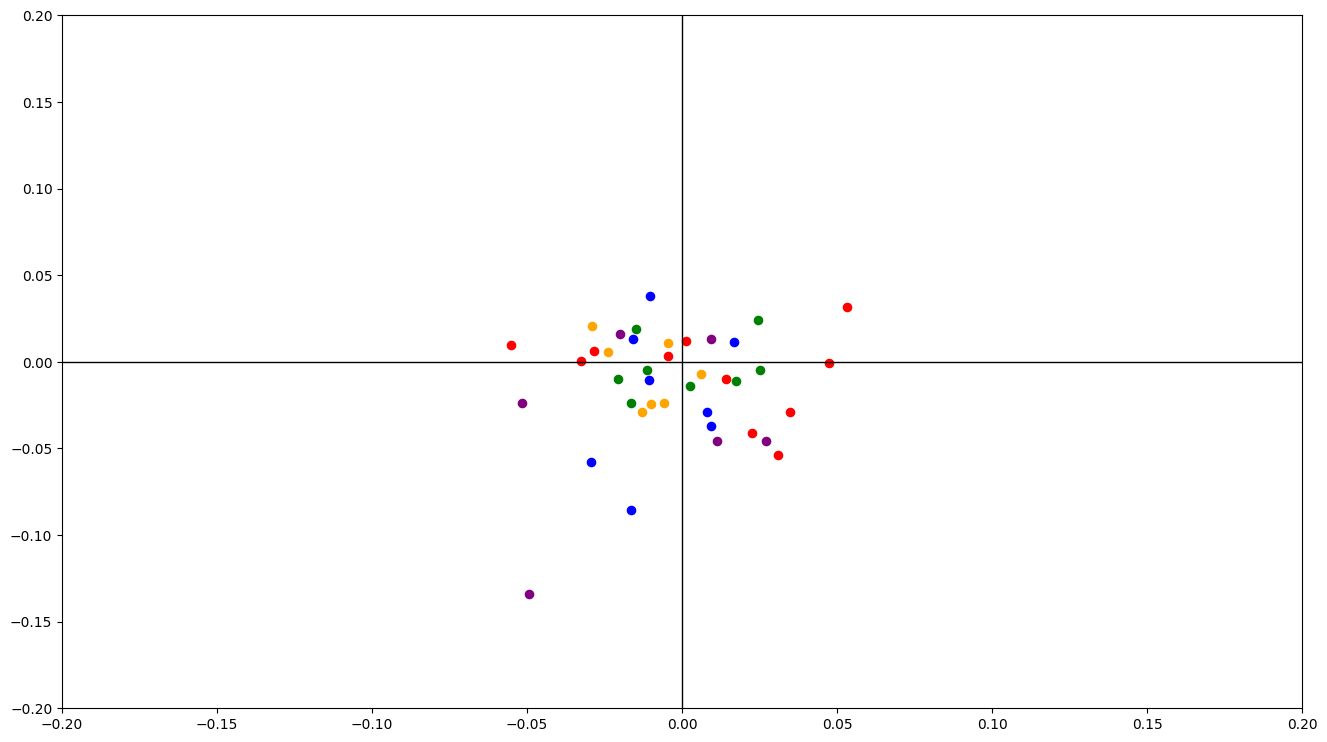

In [110]:
fig, ax = plt.subplots(1, 1, figsize=(16, 9))

ax.axhline(0, color='black', linewidth=1)
ax.axvline(0, color='black', linewidth=1)

ax.set_xlim([-.2, .2])
ax.set_ylim([-.2, .2])

ax.scatter(clip_velocity_storage_x_dither_1_1, clip_velocity_storage_y_dither_1_1, color='red',s=35)

ax.scatter(clip_velocity_storage_x_dither_1_2, clip_velocity_storage_y_dither_1_2, color='green',s=35)

ax.scatter(clip_velocity_storage_x_dither_1_3, clip_velocity_storage_y_dither_1_3, color='blue',s=35)

ax.scatter(clip_velocity_storage_x_dither_1_4, clip_velocity_storage_y_dither_1_4, color='orange',s=35)

ax.scatter(clip_velocity_storage_x_dither_1_5, clip_velocity_storage_y_dither_1_5, color='purple',s=35)

In [106]:
all_x = np.concatenate((clip_velocity_storage_x_dither_1_1, clip_velocity_storage_x_dither_1_2, clip_velocity_storage_x_dither_1_3, clip_velocity_storage_x_dither_1_4, clip_velocity_storage_x_dither_1_5)) 
all_y = np.concatenate((clip_velocity_storage_y_dither_1_1, clip_velocity_storage_y_dither_1_2, clip_velocity_storage_y_dither_1_3, clip_velocity_storage_y_dither_1_4, clip_velocity_storage_y_dither_1_5))

In [107]:
std_x = np.std(all_x)
std_y = np.std(all_y)

mean_x = np.mean(all_x)
mean_y = np.mean(all_y)

std_of_mean_x = np.std(all_x)/ np.sqrt(len(all_x))
std_of_mean_y = np.std(all_y)/ np.sqrt(len(all_y))



print (f"Standard Deviation = ({std_x:.4f},{std_y:.4f}) (pixels)")
print ()
print (f"Standard Deviation of the Mean = ({std_of_mean_x:.4f},{std_of_mean_y:.4f}) (pixels)")
print ()
print (f"Mean = ({mean_x:.4f},{mean_y:.4f}) (pixels)")


Standard Deviation = (0.0252,0.0326) (pixels)

Standard Deviation of the Mean = (0.0040,0.0052) (pixels)

Mean = (-0.0028,-0.0130) (pixels)
